### Functions & define

In [4]:
import numpy as np
from matplotlib import pyplot as plt

def load_session_data(subject, date):
    """Load all data for a given subject and date"""
    import sys
    sys.path.append(r'D:\Neural-Pipeline\source')
    from analysis_utils.NeuralDataLoader import NeuralDataLoader, Dots3DMPConfig
    
    # Load session
    loader = NeuralDataLoader()
    loader.load_session(subject, date)
    config = Dots3DMPConfig(subject)

    # spike data (unit, trial, time)
    stimOn_spikes = loader.get_spike_data(alignment='stimOn', good_units_only=True, good_trials_only=True)
    saccOnset_spikes = loader.get_spike_data(alignment='saccOnset', good_units_only=True, good_trials_only=True)
    postTargHold_spikes = loader.get_spike_data(alignment='postTargHold', good_units_only=True, good_trials_only=True)
    tuning_spikes = loader.get_tuning_data(good_units_only=True, good_trials_only=True)

    # behavioral data
    behavior_dots3DMP = loader.get_behavioral_data(task='dots3DMP', good_trials_only=True)
    behavior_tuning = loader.get_behavioral_data(task='tuning', good_trials_only=True)
    behavior_converted = config.convert_behavioral_data(behavior_dots3DMP, task='dots3DMP')
    behavior_tuning_converted = config.convert_behavioral_data(behavior_tuning, task='tuning')

    # Unit Info
    unit_info = loader.get_unit_info(good_units_only=True)
    MST_units = loader.get_units_by_area(unit_info, area_name='MST')
    VPS_units = loader.get_units_by_area(unit_info, area_name='VPS')
    dual_units = loader.get_units_by_area(unit_info, area_name='dual')

    # Time Info
    time_info = config.get_time_Info('dots3DMP')
    time_info_tuning = config.get_time_Info('tuning')
    time_axes_dots3DMP = config.get_time_axes('dots3DMP')

    # Prepare data
    spikes_data = {
        'stimOn': stimOn_spikes,
        'saccOnset': saccOnset_spikes,
        'postTargHold': postTargHold_spikes
    }
    
    units_data = {
        'MST': MST_units,
        'VPS': VPS_units,
        'dual': dual_units
    }
    
    return {
        'loader': loader,
        'config': config,
        'spikes_data': spikes_data,
        'behavior_converted': behavior_converted,
        'behavior_tuning_converted': behavior_tuning_converted,
        'unit_info': unit_info,
        'units_data': units_data,
        'time_axes_dots3DMP': time_axes_dots3DMP,
        'time_info': time_info,
        'time_info_tuning': time_info_tuning
    }

def calculate_decision_variable(y_test, y_proba, epsilon=1e-10):
    """
    Calculate decision variable from classifier probabilities
    Handles both single values and arrays
    """
    # Convert to arrays if single values
    if np.isscalar(y_test):
        y_test = np.array([y_test])
        y_proba = np.array([y_proba])
        single_value = True
    else:
        single_value = False
    
    dvs = []
    for idx, val in enumerate(y_proba):
        if val < 0 or val > 1:
            raise ValueError(f"y_proba contains invalid probability value at index {idx}: {val}. Must be in [0, 1].")
        y_test_ = int(y_test[idx])
        y_proba_ = float(y_proba[idx])
        # Ensure y_proba is in valid range [epsilon, 1-epsilon]
        y_proba_clipped = np.clip(y_proba_, epsilon, 1 - epsilon)
        
        # Calculate log-odds (decision variable)
        dv = np.log(y_proba_clipped / (1 - y_proba_clipped))
        
        # If true class is 0, flip the sign
        if y_test_ == 0:
            dv = -dv
        dvs.append(dv)
    
    if single_value:
        return dvs[0]  # Return single value
    else:
        return np.mean(dvs)  # Return mean for arrays

# Function to create file path based on modality/coherence condition
def get_filepath(date, area, alignment, target, mod, coh, regression='decoders'):
    subject = 'zarya'
    if target == 'stimulus':
        trial_condition = 'correct_non_zero'
    elif target == 'choice':    
        trial_condition = 'non_zero'
    elif target == 'PDW':
        trial_condition = 'small_heading_single_target'

    decoder_folder = f"D:\\Neural-Pipeline\\results\\analysis_population\\{regression}"

    return f"{decoder_folder}\\{subject}_{date}_{area}_{target}_{alignment}_train_mod{mod}_coh{coh}_test_mod{mod}_coh{coh}_{trial_condition}_cv_results.npy"

def calculate_baseline_correction(time_points, dv_mean, accuracy_mean, baseline_window):

    start_time, end_time = baseline_window
    baseline_indices = [idx for idx, t in enumerate(time_points) if start_time <= t < end_time]
    
    baseline_dv = 0
    baseline_accuracy = 0
    
    if baseline_indices:
        baseline_dv_values = [dv_mean[idx] for idx in baseline_indices if not np.isnan(dv_mean[idx])]
        baseline_acc_values = [accuracy_mean[idx] for idx in baseline_indices if not np.isnan(accuracy_mean[idx])]
        
        if baseline_dv_values:
            baseline_dv = np.nanmean(baseline_dv_values)
        if baseline_acc_values:
            baseline_accuracy = np.nanmean(baseline_acc_values)
    
    return baseline_dv, baseline_accuracy

def classify_multisensory_units_matching_sci(tuning_df):
    """
    Use the EXACT same classification logic as the SCI analysis
    """
    # Add multisensory type classification to dataframe
    tuning_df['multisensory_type'] = 'None'
    
    multisensory_mask = []
    threshold = 0.05  # SAME threshold as SCI analysis
    
    for idx, row in tuning_df.iterrows():
        # Apply the EXACT same selectivity definitions as SCI code
        vis_selective = row['vis_pval'] < threshold and row['ves_pval'] > threshold
        ves_selective = row['ves_pval'] < threshold and row['vis_pval'] > threshold
        comb_selective = (row['vis_pval'] < threshold and row['ves_pval'] < threshold) or row['comb_pval'] < threshold
        
        # Determine unit type based on selectivity patterns - EXACT same logic
        if vis_selective and not ves_selective and not comb_selective:
            tuning_df.loc[idx, 'multisensory_type'] = 'Visual_only'
            multisensory_mask.append(False)
        elif ves_selective and not vis_selective and not comb_selective:
            tuning_df.loc[idx, 'multisensory_type'] = 'Vestibular_only'
            multisensory_mask.append(False)
        elif comb_selective:
            tuning_df.loc[idx, 'multisensory_type'] = 'Multisensory'
            multisensory_mask.append(True)
    
    return np.array(multisensory_mask)


In [5]:
subject = "zarya"
date = "20250602"
data_dict = load_session_data(subject, date)
time_axes_dots3DMP = data_dict['time_axes_dots3DMP']
zero_time = np.where(time_axes_dots3DMP['stimOn']<0)


# Define brain areas, alignments, and targets
areas = ['dual', 'MST', 'VPS']
alignments = ['stimOn', 'saccOnset', 'postTargHold']
targets = ['stimulus', 'choice', 'PDW']
area_colors = {'dual': 'blue', 'MST': 'red', 'VPS': 'black'}

# Alignment display names
alignment_names = {
    'stimOn': 'Stimulus On',
    'saccOnset': 'Choice', 
    'postTargHold': 'Confidence'
}
# Define modality/coherence conditions with their file parameters
modality_conditions = {
    'Vestibular Only': {'mod': 1, 'coh': 1},        # Row 0: mod1_coh1
    'Visual Low Coh': {'mod': 2, 'coh': 1},         # Row 1: mod2_coh1
    'Visual High Coh': {'mod': 2, 'coh': 2},        # Row 2: mod2_coh2
    'Combined Low Coh': {'mod': 3, 'coh': 1},       # Row 3: mod3_coh1
    'Combined High Coh': {'mod': 3, 'coh': 2}       # Row 4: mod3_coh2       
}

# Velocity profile markers for stimOn alignment
vel_markers = {
    'max_velocity': 0.66,
    'max_acceleration': 0.4,
}
# Define heading groups with colors (indices, color)
heading_groups = {
    '±10°': ([1, 7], "#7E0000"),
    '±3.9°': ([2, 6], "#B41D1D"),
    '±1.5°': ([3, 5], "#FF6767"),
    '0°': ([4], "#A2A2A2"),
    'All': ([1, 2, 3, 4, 5, 6, 7], '#000000')
}
# Define session dates to analyze
dates = ["20250602", "20250523","20250702", "20250710"]   




Loaded dots3DMP data: zarya20250602dots3DMP_processed.npz
Loaded dots3DMPtuning data: zarya20250602dots3DMPtuning_processed.npz
Loaded dots3DMP configuration for subject: zarya


### plot choices, by modality and coherence, different heading angle

In [ ]:
# Define heading groups with colors (indices, color)
heading_groups = {
    '±10°': ([1, 7], "#7E0000"),
    '±3.9°': ([2, 6], "#B41D1D"),
    '±1.5°': ([3, 5], "#FF6767"),
    '0°': ([4], "#A2A2A2"),
    'All': ([1, 2, 3, 4, 5, 6, 7], '#000000')
}

targets_to_plot = ['choice']
areas = ['VPS']

baseline_corrections = {}

for target in targets_to_plot:
    print(f"\n{'#'*60}")
    print(f"PROCESSING TARGET: {target.upper()} - BY HEADING GROUPS")
    print(f"{'#'*60}")
    
    fig, axes = plt.subplots(5, 6, figsize=(30, 25))
    
    for j, alignment in enumerate(alignments):
        print(f"\n{'='*20} {alignment.upper()} {'='*20}")
        time_axes_condition = time_axes_dots3DMP[alignment]
        
        for area in areas:
            print(f"\n{area}:")
            
            for i, (condition_name, condition_params) in enumerate(modality_conditions.items()):
                mod = condition_params['mod']
                coh = condition_params['coh']
                
                print(f"\n  {condition_name} (mod={mod}, coh={coh}):")
                
                # Collect all trials (keep them intact)
                all_trials = []
                successful_dates = 0
                
                for date in dates:
                    filepath = get_filepath(date, area, alignment, target, mod, coh)
                    
                    try:
                        results = np.load(filepath, allow_pickle=True).item()
                        trial_results = results['trial_results']
                        all_trials.extend(trial_results)
                        successful_dates += 1
                        print(f"    {date}: loaded {len(trial_results)} trials")
                    except FileNotFoundError:
                        print(f"    {date}: File not found")
                        continue
                    except Exception as e:
                        print(f"    {date}: Error - {str(e)}")
                        continue
                
                if successful_dates == 0:
                    print(f"    No data found for {condition_name}")
                    continue
                
                print(f"    Total trials: {len(all_trials)}")
                
                # Set target-specific labels
                if target == 'choice':
                    ylabel = 'DV (choice probability)'
                elif target == 'PDW':
                    ylabel = 'DV (confidence)'
                
                # Process each heading group
                heading_results = {}
                
                for group_name, (heading_indices, color) in heading_groups.items():
                    print(f"    Processing {group_name}...")
                    
                    # Initialize baseline corrections for this heading group
                    if group_name not in baseline_corrections:
                        baseline_corrections[group_name] = {
                            'dv': 0,
                            'accuracy': 0
                        }
                    
                    # Store DV and accuracy for each trial for this heading condition
                    trials_dv_by_time = {}  # time -> list of DV values across trials
                    trials_accuracy_by_time = {}  # time -> list of accuracy values across trials
                    
                    trials_processed = 0
                    for trial in all_trials:
                        if 'test_behavior' in trial and 'headingInd' in trial['test_behavior']:
                            test_heading_indices = trial['test_behavior']['headingInd']
                            
                            # Create mask for samples that match this heading group
                            if group_name == 'All':
                                heading_mask = np.ones(len(test_heading_indices), dtype=bool)
                            else:
                                heading_mask = np.isin(test_heading_indices, heading_indices)
                            
                            # Skip if no samples match this heading condition
                            if not np.any(heading_mask):
                                continue
                            
                            # Filter trial data to only relevant samples
                            y_test_filtered = np.array(trial['y_test'])[heading_mask]
                            y_proba_filtered = np.array(trial['y_proba'])[heading_mask]
                            y_pred_filtered = np.array(trial['y_pred'])[heading_mask]
                            
                            # Calculate DV and accuracy for this trial for this heading condition
                            trial_dvs = []
                            trial_correct = []
                            
                            for y_t, y_p, y_pred in zip(y_test_filtered, y_proba_filtered, y_pred_filtered):
                                dv = calculate_decision_variable(y_t, y_p)
                                trial_dvs.append(dv)
                                
                                # Calculate accuracy for this sample
                                trial_correct.append(1 if y_pred == y_t else 0)
                            
                            # Get mean DV and accuracy for this trial for this heading condition
                            if trial_dvs:  # Make sure we have data
                                trial_mean_dv = np.mean(trial_dvs)
                                trial_mean_accuracy = np.mean(trial_correct)
                                
                                # Store by time point
                                time_point = trial['time']
                                if time_point not in trials_dv_by_time:
                                    trials_dv_by_time[time_point] = []
                                    trials_accuracy_by_time[time_point] = []
                                
                                trials_dv_by_time[time_point].append(trial_mean_dv)
                                trials_accuracy_by_time[time_point].append(trial_mean_accuracy)
                                trials_processed += 1
                    
                    print(f"      Processed {trials_processed} trials for {group_name}")
                    
                    if not trials_dv_by_time:
                        print(f"      No valid data for {group_name}, skipping...")
                        continue
                    
                    # Calculate mean and std across trials for each time point
                    time_points = sorted(trials_dv_by_time.keys())
                    print(f"      Time points: {len(time_points)} from {min(time_points):.3f} to {max(time_points):.3f}")
                    
                    dv_mean = []
                    dv_std = []
                    accuracy_mean = []
                    accuracy_std = []
                    
                    for t in time_points:
                        if t in trials_dv_by_time and len(trials_dv_by_time[t]) > 0:
                            # DV statistics
                            dv_values = trials_dv_by_time[t]
                            dv_mean.append(np.mean(dv_values))
                            dv_std.append(np.std(dv_values) / np.sqrt(len(dv_values)))
                            
                            # Accuracy statistics
                            acc_values = trials_accuracy_by_time[t]
                            accuracy_mean.append(np.mean(acc_values))
                            accuracy_std.append(np.std(acc_values) / np.sqrt(len(acc_values)))
                        else:
                            dv_mean.append(np.nan)
                            dv_std.append(0)
                            accuracy_mean.append(0.5)
                            accuracy_std.append(0)
                    
                    # Calculate and store baseline corrections when processing stimOn alignment
                    if alignment == 'stimOn':
                        baseline_indices = range(0, zero_time[0][-1])  # Indices before time zero
                        
                        if baseline_indices:  # Make sure we have baseline data
                            baseline_dv_values = [dv_mean[idx] for idx in baseline_indices if not np.isnan(dv_mean[idx])]
                            baseline_acc_values = [accuracy_mean[idx] for idx in baseline_indices if not np.isnan(accuracy_mean[idx])]
                            
                            if baseline_dv_values:
                                baseline_corrections[group_name]['dv'] = np.nanmean(baseline_dv_values)
                            
                            if baseline_acc_values:
                                baseline_corrections[group_name]['accuracy'] = np.nanmean(baseline_acc_values)
                            print(f"      Baseline DV correction for {group_name}: {baseline_corrections[group_name]['dv']:.4f}")
                            print(f"      Baseline accuracy correction for {group_name}: {baseline_corrections  [group_name]['accuracy']:.4f}")
                    
                    # Apply corrections using stored values
                    correct_baseline_dv = baseline_corrections[group_name]['dv']
                    correct_baseline_accuracy = baseline_corrections[group_name]['accuracy']

                    
                    print(f"      Applying corrections for {group_name} - DV: {correct_baseline_dv:.4f}, Accuracy: {correct_baseline_accuracy:.4f}")
                    
                    # Apply baseline corrections
                    dv_mean_corrected = [val - correct_baseline_dv if not np.isnan(val) else np.nan for val in dv_mean]
                    accuracy_mean_corrected = [val - correct_baseline_accuracy + 0.5 if not np.isnan(val) else np.nan for val in accuracy_mean]
                    
                    # Store results for this heading group
                    heading_results[group_name] = {
                        'dv_mean': dv_mean_corrected,
                        'dv_std': dv_std,
                        'accuracy_mean': accuracy_mean_corrected,
                        'accuracy_std': accuracy_std,
                        'color': color,
                        'n_trials': trials_processed,
                        'time_points': time_points
                    }
                
                # Plot all heading groups for this condition
                for group_name, results in heading_results.items():
                    if len(results['dv_mean']) > 0 and not all(np.isnan(results['dv_mean'])):
                        # Plot DV
                        ax_dv = axes[i, j]
                        ax_dv.plot(time_axes_condition, results['dv_mean'], 
                                   color=results['color'], linestyle='-', 
                                   linewidth=3, label=group_name, alpha=0.8)
                        ax_dv.fill_between(time_axes_condition, 
                                           np.array(results['dv_mean']) - np.array(results['dv_std']),
                                           np.array(results['dv_mean']) + np.array(results['dv_std']),
                                           alpha=0.2, color=results['color'])
                        
                        # Plot Accuracy
                        ax_accuracy = axes[i, j + 3]
                        ax_accuracy.plot(time_axes_condition, results['accuracy_mean'], 
                                         color=results['color'], linestyle='-', 
                                         linewidth=3, label=group_name, alpha=0.8)
                        ax_accuracy.fill_between(time_axes_condition, 
                                                 np.array(results['accuracy_mean']) - np.array(results['accuracy_std']),
                                                 np.array(results['accuracy_mean']) + np.array(results['accuracy_std']),
                                                 alpha=0.2, color=results['color'])
        
        # Format subplots (same as before)
        for i, condition_name in enumerate(modality_conditions.keys()):
            # Format DV subplot
            ax_dv = axes[i, j]
            ax_dv.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            ax_dv.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
            
            if alignment == 'stimOn':
                ax_dv.axvline(x=vel_markers['max_acceleration'], color='orange', linestyle=':', alpha=0.7)
                ax_dv.axvline(x=vel_markers['max_velocity'], color='purple', linestyle=':', alpha=0.7)
                ax_dv.text(vel_markers['max_acceleration'], 0.95, 'Max Acc', 
                           rotation=90, verticalalignment='top', horizontalalignment='right',
                           color='orange', fontsize=12, transform=ax_dv.get_xaxis_transform())
                ax_dv.text(vel_markers['max_velocity'], 0.95, 'Max Vel', 
                           rotation=90, verticalalignment='top', horizontalalignment='right',
                           color='purple', fontsize=12, transform=ax_dv.get_xaxis_transform())
            
            ax_dv.text(0, 0.95, alignment_names[alignment], rotation=90, verticalalignment='top', 
                       horizontalalignment='right', color='black', fontsize=12,
                       transform=ax_dv.get_xaxis_transform())
            
            ax_dv.set_xlabel('Time (s)')
            ax_dv.set_ylabel(ylabel)
            
            if j == 0:
                ax_dv.set_title(f'{condition_name}', fontsize=12, loc='left')
            
            if i == len(modality_conditions) - 1 and j == len(alignments) - 1:
                ax_dv.legend(fontsize=8)

            ax_dv.set_ylim(-0.1, 1.5) 
            
            # Format Accuracy subplot
            ax_accuracy = axes[i, j + 3]
            ax_accuracy.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
            ax_accuracy.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
            
            if alignment == 'stimOn':
                ax_accuracy.axvline(x=vel_markers['max_acceleration'], color='orange', linestyle=':', alpha=0.7)
                ax_accuracy.axvline(x=vel_markers['max_velocity'], color='purple', linestyle=':', alpha=0.7)
                ax_accuracy.text(vel_markers['max_acceleration'], 0.95, 'Max Acc', 
                           rotation=90, verticalalignment='top', horizontalalignment='right',
                           color='orange', fontsize=12, transform=ax_accuracy.get_xaxis_transform())
                ax_accuracy.text(vel_markers['max_velocity'], 0.95, 'Max Vel', 
                           rotation=90, verticalalignment='top', horizontalalignment='right',
                           color='purple', fontsize=12, transform=ax_accuracy.get_xaxis_transform())
            
            ax_accuracy.text(0, 0.95, alignment_names[alignment], rotation=90, verticalalignment='top', 
                       horizontalalignment='right', color='black', fontsize=12,
                       transform=ax_accuracy.get_xaxis_transform())
            
            ax_accuracy.set_xlabel('Time (s)')
            ax_accuracy.set_ylabel('Accuracy')
            
            if i == len(modality_conditions) - 1 and j == len(alignments) - 1:
                ax_accuracy.legend(fontsize=8)
            
            ax_accuracy.set_ylim(0.3, 1.0)
    
    fig.suptitle(f'{target.upper()} Decoding by Heading Groups - Dual Area\nLeft: Decision Variable, Right: Accuracy', 
                 fontsize=16, y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, left=0.05)
    
    save_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\{target}_decoding_{area}_by_heading_zarya.png"
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    print(f"\nFigure saved as: {save_filename}")
    
    plt.show()

### plot stimulus, by modality and coherence, different heading angle

In [ ]:
# Define heading groups with colors (indices, color) - no zero heading
heading_groups = {
    '±10°': ([1, 7], "#00047E"),
    '±3.9°': ([2, 6], "#2A1DB4"),
    '±1.5°': ([3, 5], "#67A4FF"),
    'All': ([1, 2, 3, 4, 5, 6, 7], '#000000')
}

# Remove correctness groups since we're pooling all trials
# correctness_groups = {
#     'Correct': 1,    # Monkey got it right
#     'Error': 0       # Monkey got it wrong
# }

targets_to_plot = ['stimulus']
areas = ['dual']

baseline_corrections = {}

for target in targets_to_plot:
    print(f"\n{'#'*60}")
    print(f"PROCESSING TARGET: {target.upper()} - BY HEADING GROUPS (ALL TRIALS POOLED)")
    print(f"{'#'*60}")
    
    fig, axes = plt.subplots(5, 6, figsize=(30, 25))
    
    for j, alignment in enumerate(alignments):
        print(f"\n{'='*20} {alignment.upper()} {'='*20}")
        time_axes_condition = time_axes_dots3DMP[alignment]
        
        for area in areas:
            print(f"\n{area}:")
            
            for i, (condition_name, condition_params) in enumerate(modality_conditions.items()):
                mod = condition_params['mod']
                coh = condition_params['coh']
                
                print(f"\n  {condition_name} (mod={mod}, coh={coh}):")
                
                # Collect all trials
                all_trials = []
                successful_dates = 0
                
                for date in dates:
                    filepath = get_filepath(date, area, alignment, target, mod, coh)
                    
                    try:
                        results = np.load(filepath, allow_pickle=True).item()
                        trial_results = results['trial_results']
                        all_trials.extend(trial_results)
                        successful_dates += 1
                        print(f"    {date}: loaded {len(trial_results)} trials")
                    except FileNotFoundError:
                        print(f"    {date}: File not found")
                        continue
                    except Exception as e:
                        print(f"    {date}: Error - {str(e)}")
                        continue
                
                if successful_dates == 0:
                    print(f"    No data found for {condition_name}")
                    continue
                
                print(f"    Total trials: {len(all_trials)}")
                
                # Set target-specific labels
                ylabel = 'DV (stimulus decoding)'
                
                # Process each heading group (pooling all correctness levels)
                heading_results = {}
                
                for group_name, (heading_indices, color) in heading_groups.items():
                    
                    print(f"    Processing {group_name} (all trials pooled)...")
                    
                    # Initialize baseline corrections
                    if group_name not in baseline_corrections:
                        baseline_corrections[group_name] = {
                            'dv': 0,
                            'accuracy': 0
                        }
                    
                    # Store DV and accuracy for each trial
                    trials_dv_by_time = {}
                    trials_accuracy_by_time = {}
                    
                    trials_processed = 0
                    for trial in all_trials:
                        if ('test_behavior' in trial and 
                            'headingInd' in trial['test_behavior'] and 
                            'correct' in trial['test_behavior']):
                            
                            test_heading_indices = trial['test_behavior']['headingInd']
                            
                            # Create mask for samples that match this heading group
                            if group_name == 'All':
                                heading_mask = np.ones(len(test_heading_indices), dtype=bool)
                            else:
                                heading_mask = np.isin(test_heading_indices, heading_indices)
                            
                            # Skip if no samples match this condition
                            if not np.any(heading_mask):
                                continue
                            
                            # Filter trial data to only relevant samples (no correctness filtering)
                            y_test_filtered = np.array(trial['y_test'])[heading_mask]
                            y_proba_filtered = np.array(trial['y_proba'])[heading_mask]
                            y_pred_filtered = np.array(trial['y_pred'])[heading_mask]
                            
                            # Calculate DV and accuracy for this trial
                            trial_dvs = []
                            trial_correct = []
                            
                            for y_t, y_p, y_pred in zip(y_test_filtered, y_proba_filtered, y_pred_filtered):
                                dv = calculate_decision_variable(y_t, y_p)
                                trial_dvs.append(dv)
                                # Model accuracy (how well decoder predicts stimulus)
                                trial_correct.append(1 if y_pred == y_t else 0)
                            
                            # Get mean DV and accuracy for this trial
                            if trial_dvs:
                                trial_mean_dv = np.mean(trial_dvs)
                                trial_mean_accuracy = np.mean(trial_correct)
                                
                                # Store by time point
                                time_point = trial['time']
                                if time_point not in trials_dv_by_time:
                                    trials_dv_by_time[time_point] = []
                                    trials_accuracy_by_time[time_point] = []
                                
                                trials_dv_by_time[time_point].append(trial_mean_dv)
                                trials_accuracy_by_time[time_point].append(trial_mean_accuracy)
                                trials_processed += 1
                    
                    print(f"      Processed {trials_processed} trials for {group_name}")
                    
                    if not trials_dv_by_time:
                        print(f"      No valid data for {group_name}, skipping...")
                        continue
                    
                    # Calculate mean and std across trials for each time point
                    time_points = sorted(trials_dv_by_time.keys())
                    
                    dv_mean = []
                    dv_std = []
                    accuracy_mean = []
                    accuracy_std = []
                    
                    for t in time_points:
                        if t in trials_dv_by_time and len(trials_dv_by_time[t]) > 0:
                            # DV statistics
                            dv_values = trials_dv_by_time[t]
                            dv_mean.append(np.mean(dv_values))
                            dv_std.append(np.std(dv_values) / np.sqrt(len(dv_values)))
                            
                            # Accuracy statistics
                            acc_values = trials_accuracy_by_time[t]
                            accuracy_mean.append(np.mean(acc_values))
                            accuracy_std.append(np.std(acc_values) / np.sqrt(len(acc_values)))
                        else:
                            dv_mean.append(np.nan)
                            dv_std.append(0)
                            accuracy_mean.append(0.5)
                            accuracy_std.append(0)
                    
                    # Calculate baseline corrections for stimOn alignment
                    if alignment == 'stimOn':
                        baseline_indices = range(0, zero_time[0][-1])
                        
                        if baseline_indices:
                            baseline_dv_values = [dv_mean[idx] for idx in baseline_indices if not np.isnan(dv_mean[idx])]
                            baseline_acc_values = [accuracy_mean[idx] for idx in baseline_indices if not np.isnan(accuracy_mean[idx])]
                            
                            if baseline_dv_values:
                                baseline_corrections[group_name]['dv'] = np.nanmean(baseline_dv_values)
                            
                            if baseline_acc_values:
                                baseline_corrections[group_name]['accuracy'] = np.nanmean(baseline_acc_values)
                    
                    # Apply corrections
                    correct_baseline_dv = baseline_corrections[group_name]['dv']
                    correct_baseline_accuracy = baseline_corrections[group_name]['accuracy']
                    
                    # Apply baseline corrections
                    dv_mean_corrected = [val - correct_baseline_dv if not np.isnan(val) else np.nan for val in dv_mean]
                    accuracy_mean_corrected = [val - correct_baseline_accuracy + 0.5 if not np.isnan(val) else np.nan for val in accuracy_mean]
                    
                    # Store results (solid line for all pooled trials)
                    heading_results[group_name] = {
                        'dv_mean': dv_mean_corrected,
                        'dv_std': dv_std,
                        'accuracy_mean': accuracy_mean_corrected,
                        'accuracy_std': accuracy_std,
                        'color': color,
                        'linestyle': '-',  # Always solid line
                        'alpha': 0.9,     # Standard alpha
                        'n_trials': trials_processed,
                        'time_points': time_points,
                        'label': f"{group_name}"  # Simplified label
                    }
                
                # Plot all heading groups
                for group_name, results in heading_results.items():
                    if len(results['dv_mean']) > 0 and not all(np.isnan(results['dv_mean'])):
                        # Plot DV
                        ax_dv = axes[i, j]
                        ax_dv.plot(time_axes_condition, results['dv_mean'], 
                                   color=results['color'], 
                                   linestyle=results['linestyle'],
                                   linewidth=2, 
                                   label=results['label'], 
                                   alpha=results['alpha'])
                        ax_dv.fill_between(time_axes_condition, 
                                           np.array(results['dv_mean']) - np.array(results['dv_std']),
                                           np.array(results['dv_mean']) + np.array(results['dv_std']),
                                           alpha=0.1, color=results['color'])
                        
                        # Plot Accuracy
                        ax_accuracy = axes[i, j + 3]
                        ax_accuracy.plot(time_axes_condition, results['accuracy_mean'], 
                                         color=results['color'], 
                                         linestyle=results['linestyle'],
                                         linewidth=2, 
                                         label=results['label'], 
                                         alpha=results['alpha'])
                        ax_accuracy.fill_between(time_axes_condition, 
                                                 np.array(results['accuracy_mean']) - np.array(results['accuracy_std']),
                                                 np.array(results['accuracy_mean']) + np.array(results['accuracy_std']),
                                                 alpha=0.1, color=results['color'])
        
        # Format subplots
        for i, condition_name in enumerate(modality_conditions.keys()):
            # Format DV subplot
            ax_dv = axes[i, j]
            ax_dv.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            ax_dv.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
            
            if alignment == 'stimOn':
                ax_dv.axvline(x=vel_markers['max_acceleration'], color='orange', linestyle=':', alpha=0.7)
                ax_dv.axvline(x=vel_markers['max_velocity'], color='purple', linestyle=':', alpha=0.7)
            
            ax_dv.text(0, 0.95, alignment_names[alignment], rotation=90, verticalalignment='top', 
                       horizontalalignment='right', color='black', fontsize=12,
                       transform=ax_dv.get_xaxis_transform())
            
            ax_dv.set_xlabel('Time (s)')
            ax_dv.set_ylabel(ylabel)
            
            if j == 0:
                ax_dv.set_title(f'{condition_name}', fontsize=12, loc='left')
            
            if i == len(modality_conditions) - 1 and j == len(alignments) - 1:
                ax_dv.legend(fontsize=8)

            ax_dv.set_ylim(-0.5, 1.5) 
            
            # Format Accuracy subplot
            ax_accuracy = axes[i, j + 3]
            ax_accuracy.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
            ax_accuracy.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
            
            if alignment == 'stimOn':
                ax_accuracy.axvline(x=vel_markers['max_acceleration'], color='orange', linestyle=':', alpha=0.7)
                ax_accuracy.axvline(x=vel_markers['max_velocity'], color='purple', linestyle=':', alpha=0.7)
            
            ax_accuracy.text(0, 0.95, alignment_names[alignment], rotation=90, verticalalignment='top', 
                       horizontalalignment='right', color='black', fontsize=12,
                       transform=ax_accuracy.get_xaxis_transform())
            
            ax_accuracy.set_xlabel('Time (s)')
            ax_accuracy.set_ylabel('Decoder Accuracy')
            
            if i == len(modality_conditions) - 1 and j == len(alignments) - 1:
                ax_accuracy.legend(fontsize=8)
            
            ax_accuracy.set_ylim(0.3, 1.0)
    
    fig.suptitle(f'{target.upper()} Decoding by Heading Groups (All Trials Pooled)\nLeft: Decision Variable, Right: Decoder Accuracy', 
                 fontsize=16, y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, left=0.05)
    
    save_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\{target}_decoding_{area}_by_heading_pooled_zarya.png"
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    print(f"\nFigure saved as: {save_filename}")
    
    plt.show()

### plot decoder accuracy comparisons

In [ ]:
# Define heading groups - only zero heading now
heading_groups_comparison = {
    'Zero (0°)': [4]     
}

# Define decoder configurations - separate choice and stimulus
choice_decoder_configs = {
    'choice_noregress': {
        'target': 'choice',
        'regression': 'decoders_noregress',
        'color': "#FF6B6B",  # Bright coral
        'linestyle': '-',
        'linewidth': 3,
        'label': 'Choice (No Regression)'
    },
    'choice_regress': {
        'target': 'choice', 
        'regression': 'decoders_partialregression',
        'color': "#CC0000",  # Dark red
        'linestyle': '--',
        'linewidth': 3,
        'label': 'Choice (Partial Regression)'
    }
}

stimulus_decoder_configs = {
    'stimulus_noregress': {
        'target': 'stimulus',
        'regression': 'decoders_noregress',
        'color': "#4E8DCD",  # Bright teal
        'linestyle': '-', 
        'linewidth': 3,
        'label': 'Stimulus (No Regression)'
    },
    'stimulus_regress': {
        'target': 'stimulus',
        'regression': 'decoders_partialregression',
        'color': "#0066CC",  # Dark blue
        'linestyle': '--',
        'linewidth': 3,
        'label': 'Stimulus (Partial Regression)'
    }
}

areas = ['dual']

# Initialize baseline corrections
baseline_corrections = {}

print(f"\n{'#'*60}")
print(f"DECODER ACCURACY COMPARISON - ZERO HEADINGS ONLY")
print(f"LEFT: Choice Decoders | RIGHT: Stimulus Decoders")
print(f"{'#'*60}")

# Figure: 5 rows (conditions) x 6 columns (3 alignments x 2 decoder types)
fig, axes = plt.subplots(5, 6, figsize=(40, 32))

for j, alignment in enumerate(alignments):
    print(f"\n{'='*20} {alignment.upper()} {'='*20}")
    time_axes_condition = time_axes_dots3DMP[alignment]
    
    for area in areas:
        print(f"\n{area}:")
        
        for i, (condition_name, condition_params) in enumerate(modality_conditions.items()):
            mod = condition_params['mod']
            coh = condition_params['coh']
            
            print(f"\n  {condition_name} (mod={mod}, coh={coh}):")
            
            # Process CHOICE decoders (left columns)
            choice_results = {}
            
            for config_name, config in choice_decoder_configs.items():
                target = config['target']
                regression = config['regression']
                base_color = config['color']
                base_label = config['label']
                base_linestyle = config['linestyle']
                base_linewidth = config['linewidth']
                
                print(f"    Processing {config_name}...")
                
                # Collect all trials for this decoder configuration
                all_trials = []
                successful_dates = 0
                
                for date in dates:
                    filepath = get_filepath(date, area, alignment, target, mod, coh, regression)
                    
                    try:
                        results = np.load(filepath, allow_pickle=True).item()
                        trial_results = results['trial_results']
                        all_trials.extend(trial_results)
                        successful_dates += 1
                        print(f"      {date}: loaded {len(trial_results)} trials")
                    except FileNotFoundError:
                        print(f"      {date}: File not found")
                        continue
                    except Exception as e:
                        print(f"      {date}: Error - {str(e)}")
                        continue
                
                if successful_dates == 0:
                    print(f"      No data found for {config_name}")
                    continue
                
                print(f"      Total trials: {len(all_trials)}")
                
                # Process zero heading for this decoder
                heading_name = 'Zero (0°)'
                heading_indices = [4]
                
                print(f"        Processing {heading_name}...")
                
                # Initialize baseline corrections for this combination
                baseline_key = f"{config_name}_{heading_name}"
                if baseline_key not in baseline_corrections:
                    baseline_corrections[baseline_key] = {'accuracy': 0}
                
                # Store accuracy for each trial
                trials_accuracy_by_time = {}
                trials_processed = 0
                
                for trial in all_trials:
                    if ('test_behavior' in trial and 
                        'headingInd' in trial['test_behavior']):
                        
                        test_heading_indices = trial['test_behavior']['headingInd']
                        test_choices = trial['test_behavior'].get('choice', None)
                        
                        if test_choices is None:
                            continue
                            
                        test_choices = test_choices - 1
                        heading_mask = np.isin(test_heading_indices, heading_indices)
                        
                        if not np.any(heading_mask):
                            continue
                        
                        y_test_filtered = np.array(test_choices)[heading_mask]
                        y_pred_filtered = np.array(trial['y_pred'])[heading_mask]
                        
                        trial_correct = []
                        for y_choice, y_pred in zip(y_test_filtered, y_pred_filtered):
                            trial_correct.append(1 if y_pred == y_choice else 0)
                        
                        if trial_correct:
                            trial_mean_accuracy = np.mean(trial_correct)
                            time_point = trial['time']
                            
                            if time_point not in trials_accuracy_by_time:
                                trials_accuracy_by_time[time_point] = []
                            
                            trials_accuracy_by_time[time_point].append(trial_mean_accuracy)
                            trials_processed += 1
                
                print(f"          Processed {trials_processed} trials for {heading_name}")
                
                if not trials_accuracy_by_time:
                    print(f"          No valid data for {heading_name}, skipping...")
                    continue
                
                # Calculate mean and std across trials for each time point
                time_points = sorted(trials_accuracy_by_time.keys())
                accuracy_mean = []
                accuracy_std = []
                
                for t in time_points:
                    if t in trials_accuracy_by_time and len(trials_accuracy_by_time[t]) > 0:
                        acc_values = trials_accuracy_by_time[t]
                        accuracy_mean.append(np.mean(acc_values))
                        accuracy_std.append(np.std(acc_values) / np.sqrt(len(acc_values)))
                    else:
                        accuracy_mean.append(0.5)
                        accuracy_std.append(0)
                
                # Calculate baseline corrections for stimOn alignment
                if alignment == 'stimOn':
                    baseline_indices = range(0, zero_time[0][-1])
                    if baseline_indices:
                        baseline_acc_values = [accuracy_mean[idx] for idx in baseline_indices if not np.isnan(accuracy_mean[idx])]
                        if baseline_acc_values:
                            baseline_corrections[baseline_key]['accuracy'] = np.nanmean(baseline_acc_values)
                
                # Apply baseline corrections
                correct_baseline_accuracy = baseline_corrections[baseline_key]['accuracy']
                accuracy_mean_corrected = [val - correct_baseline_accuracy + 0.5 if not np.isnan(val) else np.nan for val in accuracy_mean]
                
                # Store results
                choice_results[config_name] = {
                    'accuracy_mean': accuracy_mean_corrected,
                    'accuracy_std': accuracy_std,
                    'color': base_color,
                    'linestyle': base_linestyle,
                    'linewidth': base_linewidth,
                    'alpha': 0.9,
                    'n_trials': trials_processed,
                    'time_points': time_points,
                    'label': base_label
                }
            
            # Process STIMULUS decoders (right columns) - same logic but for stimulus decoders
            stimulus_results = {}
            
            for config_name, config in stimulus_decoder_configs.items():
                target = config['target']
                regression = config['regression']
                base_color = config['color']
                base_label = config['label']
                base_linestyle = config['linestyle']
                base_linewidth = config['linewidth']
                
                print(f"    Processing {config_name}...")
                
                all_trials = []
                successful_dates = 0
                
                for date in dates:
                    filepath = get_filepath(date, area, alignment, target, mod, coh, regression)
                    
                    try:
                        results = np.load(filepath, allow_pickle=True).item()
                        trial_results = results['trial_results']
                        all_trials.extend(trial_results)
                        successful_dates += 1
                        print(f"      {date}: loaded {len(trial_results)} trials")
                    except FileNotFoundError:
                        print(f"      {date}: File not found")
                        continue
                    except Exception as e:
                        print(f"      {date}: Error - {str(e)}")
                        continue
                
                if successful_dates == 0:
                    print(f"      No data found for {config_name}")
                    continue
                
                print(f"      Total trials: {len(all_trials)}")
                
                heading_name = 'Zero (0°)'
                heading_indices = [4]
                
                baseline_key = f"{config_name}_{heading_name}"
                if baseline_key not in baseline_corrections:
                    baseline_corrections[baseline_key] = {'accuracy': 0}
                
                trials_accuracy_by_time = {}
                trials_processed = 0
                
                for trial in all_trials:
                    if ('test_behavior' in trial and 
                        'headingInd' in trial['test_behavior']):
                        
                        test_heading_indices = trial['test_behavior']['headingInd']
                        test_choices = trial['test_behavior'].get('choice', None)
                        
                        if test_choices is None:
                            continue
                            
                        test_choices = test_choices - 1
                        heading_mask = np.isin(test_heading_indices, heading_indices)
                        
                        if not np.any(heading_mask):
                            continue
                        
                        y_test_filtered = np.array(test_choices)[heading_mask]
                        y_pred_filtered = np.array(trial['y_pred'])[heading_mask]
                        
                        trial_correct = []
                        for y_choice, y_pred in zip(y_test_filtered, y_pred_filtered):
                            trial_correct.append(1 if y_pred == y_choice else 0)
                        
                        if trial_correct:
                            trial_mean_accuracy = np.mean(trial_correct)
                            time_point = trial['time']
                            
                            if time_point not in trials_accuracy_by_time:
                                trials_accuracy_by_time[time_point] = []
                            
                            trials_accuracy_by_time[time_point].append(trial_mean_accuracy)
                            trials_processed += 1
                
                if not trials_accuracy_by_time:
                    continue
                
                time_points = sorted(trials_accuracy_by_time.keys())
                accuracy_mean = []
                accuracy_std = []
                
                for t in time_points:
                    if t in trials_accuracy_by_time and len(trials_accuracy_by_time[t]) > 0:
                        acc_values = trials_accuracy_by_time[t]
                        accuracy_mean.append(np.mean(acc_values))
                        accuracy_std.append(np.std(acc_values) / np.sqrt(len(acc_values)))
                    else:
                        accuracy_mean.append(0.5)
                        accuracy_std.append(0)
                
                if alignment == 'stimOn':
                    baseline_indices = range(0, zero_time[0][-1])
                    if baseline_indices:
                        baseline_acc_values = [accuracy_mean[idx] for idx in baseline_indices if not np.isnan(accuracy_mean[idx])]
                        if baseline_acc_values:
                            baseline_corrections[baseline_key]['accuracy'] = np.nanmean(baseline_acc_values)
                
                correct_baseline_accuracy = baseline_corrections[baseline_key]['accuracy']
                accuracy_mean_corrected = [val - correct_baseline_accuracy + 0.5 if not np.isnan(val) else np.nan for val in accuracy_mean]
                
                stimulus_results[config_name] = {
                    'accuracy_mean': accuracy_mean_corrected,
                    'accuracy_std': accuracy_std,
                    'color': base_color,
                    'linestyle': base_linestyle,
                    'linewidth': base_linewidth,
                    'alpha': 0.9,
                    'n_trials': trials_processed,
                    'time_points': time_points,
                    'label': base_label
                }
            
            # Plot CHOICE results (left columns: j = 0, 1, 2)
            ax_choice = axes[i, j]
            for config_name, results in choice_results.items():
                if len(results['accuracy_mean']) > 0:
                    ax_choice.plot(time_axes_condition, results['accuracy_mean'], 
                                 color=results['color'], 
                                 linestyle=results['linestyle'],
                                 linewidth=results['linewidth'],
                                 label=results['label'], 
                                 alpha=results['alpha'])
                    ax_choice.fill_between(time_axes_condition, 
                                         np.array(results['accuracy_mean']) - np.array(results['accuracy_std']),
                                         np.array(results['accuracy_mean']) + np.array(results['accuracy_std']),
                                         alpha=0.1, color=results['color'])
            
            # Plot STIMULUS results (right columns: j + 3 = 3, 4, 5)
            ax_stimulus = axes[i, j + 3]
            for config_name, results in stimulus_results.items():
                if len(results['accuracy_mean']) > 0:
                    ax_stimulus.plot(time_axes_condition, results['accuracy_mean'], 
                                   color=results['color'], 
                                   linestyle=results['linestyle'],
                                   linewidth=results['linewidth'],
                                   label=results['label'], 
                                   alpha=results['alpha'])
                    ax_stimulus.fill_between(time_axes_condition, 
                                           np.array(results['accuracy_mean']) - np.array(results['accuracy_std']),
                                           np.array(results['accuracy_mean']) + np.array(results['accuracy_std']),
                                           alpha=0.1, color=results['color'])

# Format subplots
for i, condition_name in enumerate(modality_conditions.keys()):
    for j, alignment in enumerate(alignments):
        
        # Format CHOICE subplots (left columns)
        ax_choice = axes[i, j]
        ax_choice.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
        ax_choice.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        
        if alignment == 'stimOn':
            ax_choice.axvline(x=vel_markers['max_acceleration'], color='orange', linestyle=':', alpha=0.7)
            ax_choice.axvline(x=vel_markers['max_velocity'], color='purple', linestyle=':', alpha=0.7)
        
        ax_choice.text(0, 0.95, alignment_names[alignment], rotation=90, verticalalignment='top', 
                     horizontalalignment='right', color='black', fontsize=16,
                     transform=ax_choice.get_xaxis_transform())
        
        ax_choice.set_xlabel('Time (s)', fontsize=14)
        ax_choice.set_ylabel('Choice Prediction Accuracy', fontsize=14)
        ax_choice.set_ylim(0.3, 1.0)
        ax_choice.tick_params(labelsize=12)
        
        if i == 0 and j == 1:  # Middle top for choice side
            ax_choice.set_title('CHOICE DECODERS', fontsize=18, fontweight='bold', pad=20, color='red')
        
        if j == 0:
            ax_choice.text(-0.15, 0.5, condition_name, rotation=90, verticalalignment='center', 
                         horizontalalignment='right', transform=ax_choice.transAxes, fontsize=14)
        
        if i == len(modality_conditions) - 1 and j == len(alignments) - 1:
            ax_choice.legend(fontsize=12, loc='upper left')
        
        # Format STIMULUS subplots (right columns)
        ax_stimulus = axes[i, j + 3]
        ax_stimulus.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
        ax_stimulus.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        
        if alignment == 'stimOn':
            ax_stimulus.axvline(x=vel_markers['max_acceleration'], color='orange', linestyle=':', alpha=0.7)
            ax_stimulus.axvline(x=vel_markers['max_velocity'], color='purple', linestyle=':', alpha=0.7)
        
        ax_stimulus.text(0, 0.95, alignment_names[alignment], rotation=90, verticalalignment='top', 
                       horizontalalignment='right', color='black', fontsize=16,
                       transform=ax_stimulus.get_xaxis_transform())
        
        ax_stimulus.set_xlabel('Time (s)', fontsize=14)
        ax_stimulus.set_ylabel('Choice Prediction Accuracy', fontsize=14)
        ax_stimulus.set_ylim(0.3, 1.0)
        ax_stimulus.tick_params(labelsize=12)
        
        if i == 0 and j == 1:  # Middle top for stimulus side
            ax_stimulus.set_title('STIMULUS DECODERS', fontsize=18, fontweight='bold', pad=20, color='blue')
        
        if i == len(modality_conditions) - 1 and j == len(alignments) - 1:
            ax_stimulus.legend(fontsize=12, loc='upper left')

fig.suptitle('Choice Prediction Accuracy - Zero Headings Only (Baseline Corrected)\nLeft: Choice Decoders | Right: Stimulus Decoders\nSolid=No Regression, Dashed=Partial Regression', 
             fontsize=20, y=0.98)

plt.tight_layout()
plt.subplots_adjust(top=0.95, left=0.06)

save_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\choice_prediction_accuracy_zero_headings_choice_vs_stimulus_zarya.png"
plt.savefig(save_filename, dpi=300, bbox_inches='tight')
print(f"\nFigure saved as: {save_filename}")

plt.show()

### Archive_plot stimulus, by modalit and coherence, different heading angle and correctness

In [ ]:
# Define heading groups with colors (indices, color) - no zero heading
heading_groups = {
    '±10°': ([1, 7], "#7E0000"),
    '±3.9°': ([2, 6], "#B41D1D"),
    '±1.5°': ([3, 5], "#FF6767"),
    'All': ([1, 2, 3, 4, 5, 6, 7], '#000000')
}

# Define correctness groups
correctness_groups = {
    'Correct': 1,    # Monkey got it right
    'Error': 0       # Monkey got it wrong
}

targets_to_plot = ['stimulus']
areas = ['dual']

baseline_corrections = {}

for target in targets_to_plot:
    print(f"\n{'#'*60}")
    print(f"PROCESSING TARGET: {target.upper()} - BY HEADING GROUPS AND BEHAVIORAL CORRECTNESS")
    print(f"{'#'*60}")
    
    fig, axes = plt.subplots(5, 6, figsize=(30, 25))
    
    for j, alignment in enumerate(alignments):
        print(f"\n{'='*20} {alignment.upper()} {'='*20}")
        time_axes_condition = time_axes_dots3DMP[alignment]
        
        for area in areas:
            print(f"\n{area}:")
            
            for i, (condition_name, condition_params) in enumerate(modality_conditions.items()):
                mod = condition_params['mod']
                coh = condition_params['coh']
                
                print(f"\n  {condition_name} (mod={mod}, coh={coh}):")
                
                # Collect all trials
                all_trials = []
                successful_dates = 0
                
                for date in dates:
                    filepath = get_filepath(date, area, alignment, target, mod, coh)
                    
                    try:
                        results = np.load(filepath, allow_pickle=True).item()
                        trial_results = results['trial_results']
                        all_trials.extend(trial_results)
                        successful_dates += 1
                        print(f"    {date}: loaded {len(trial_results)} trials")
                    except FileNotFoundError:
                        print(f"    {date}: File not found")
                        continue
                    except Exception as e:
                        print(f"    {date}: Error - {str(e)}")
                        continue
                
                if successful_dates == 0:
                    print(f"    No data found for {condition_name}")
                    continue
                
                print(f"    Total trials: {len(all_trials)}")
                
                # Set target-specific labels
                ylabel = 'DV (stimulus decoding)'
                
                # Process each heading group × correctness combination
                heading_results = {}
                
                for group_name, (heading_indices, base_color) in heading_groups.items():
                    for correctness_name, correct_value in correctness_groups.items():
                        
                        # Create combined group name and color
                        combined_name = f"{group_name}_{correctness_name}"
                        
                        # Modify color based on correctness (darker for correct, lighter for error)
                        if correctness_name == 'Correct':
                            color = base_color  # Original color
                            linestyle = '-'     # Solid line
                            alpha = 0.9
                        else:  # Error trials
                            # Convert hex to RGB, make lighter
                            hex_color = base_color.lstrip('#')
                            rgb = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
                            # Make lighter by averaging with white
                            lighter_rgb = tuple(int((c + 255) / 2) for c in rgb)
                            color = f"#{lighter_rgb[0]:02x}{lighter_rgb[1]:02x}{lighter_rgb[2]:02x}"
                            linestyle = '--'    # Dashed line
                            alpha = 0.7
                        
                        print(f"    Processing {combined_name}...")
                        
                        # Initialize baseline corrections
                        if combined_name not in baseline_corrections:
                            baseline_corrections[combined_name] = {
                                'dv': 0,
                                'accuracy': 0
                            }
                        
                        # Store DV and accuracy for each trial
                        trials_dv_by_time = {}
                        trials_accuracy_by_time = {}
                        
                        trials_processed = 0
                        for trial in all_trials:
                            if ('test_behavior' in trial and 
                                'headingInd' in trial['test_behavior'] and 
                                'correct' in trial['test_behavior']):
                                
                                test_heading_indices = trial['test_behavior']['headingInd']
                                test_correct_indices = trial['test_behavior']['correct']  # Behavioral correctness
                                
                                # Create mask for samples that match this heading group
                                if group_name == 'All':
                                    heading_mask = np.ones(len(test_heading_indices), dtype=bool)
                                else:
                                    heading_mask = np.isin(test_heading_indices, heading_indices)
                                
                                # Create mask for behavioral correctness
                                correctness_mask = (test_correct_indices == correct_value)
                                
                                # Combine masks
                                combined_mask = heading_mask & correctness_mask
                                
                                # Skip if no samples match this condition
                                if not np.any(combined_mask):
                                    continue
                                
                                # Filter trial data to only relevant samples
                                y_test_filtered = np.array(trial['y_test'])[combined_mask]
                                y_proba_filtered = np.array(trial['y_proba'])[combined_mask]
                                y_pred_filtered = np.array(trial['y_pred'])[combined_mask]
                                
                                # Calculate DV and accuracy for this trial
                                trial_dvs = []
                                trial_correct = []
                                
                                for y_t, y_p, y_pred in zip(y_test_filtered, y_proba_filtered, y_pred_filtered):
                                    dv = calculate_decision_variable(y_t, y_p)
                                    trial_dvs.append(dv)
                                    # Model accuracy (how well decoder predicts stimulus)
                                    trial_correct.append(1 if y_pred == y_t else 0)
                                
                                # Get mean DV and accuracy for this trial
                                if trial_dvs:
                                    trial_mean_dv = np.mean(trial_dvs)
                                    trial_mean_accuracy = np.mean(trial_correct)
                                    
                                    # Store by time point
                                    time_point = trial['time']
                                    if time_point not in trials_dv_by_time:
                                        trials_dv_by_time[time_point] = []
                                        trials_accuracy_by_time[time_point] = []
                                    
                                    trials_dv_by_time[time_point].append(trial_mean_dv)
                                    trials_accuracy_by_time[time_point].append(trial_mean_accuracy)
                                    trials_processed += 1
                        
                        print(f"      Processed {trials_processed} trials for {combined_name}")
                        
                        if not trials_dv_by_time:
                            print(f"      No valid data for {combined_name}, skipping...")
                            continue
                        
                        # Calculate mean and std across trials for each time point
                        time_points = sorted(trials_dv_by_time.keys())
                        
                        dv_mean = []
                        dv_std = []
                        accuracy_mean = []
                        accuracy_std = []
                        
                        for t in time_points:
                            if t in trials_dv_by_time and len(trials_dv_by_time[t]) > 0:
                                # DV statistics
                                dv_values = trials_dv_by_time[t]
                                dv_mean.append(np.mean(dv_values))
                                dv_std.append(np.std(dv_values) / np.sqrt(len(dv_values)))
                                
                                # Accuracy statistics
                                acc_values = trials_accuracy_by_time[t]
                                accuracy_mean.append(np.mean(acc_values))
                                accuracy_std.append(np.std(acc_values) / np.sqrt(len(acc_values)))
                            else:
                                dv_mean.append(np.nan)
                                dv_std.append(0)
                                accuracy_mean.append(0.5)
                                accuracy_std.append(0)
                        
                        # Calculate baseline corrections for stimOn alignment
                        if alignment == 'stimOn':
                            baseline_indices = range(0, zero_time[0][-1])
                            
                            if baseline_indices:
                                baseline_dv_values = [dv_mean[idx] for idx in baseline_indices if not np.isnan(dv_mean[idx])]
                                baseline_acc_values = [accuracy_mean[idx] for idx in baseline_indices if not np.isnan(accuracy_mean[idx])]
                                
                                if baseline_dv_values:
                                    baseline_corrections[combined_name]['dv'] = np.nanmean(baseline_dv_values)
                                
                                if baseline_acc_values:
                                    baseline_corrections[combined_name]['accuracy'] = np.nanmean(baseline_acc_values)
                        
                        # Apply corrections
                        correct_baseline_dv = baseline_corrections[combined_name]['dv']
                        correct_baseline_accuracy = baseline_corrections[combined_name]['accuracy']
                        
                        
                        # Apply baseline corrections
                        dv_mean_corrected = [val - correct_baseline_dv if not np.isnan(val) else np.nan for val in dv_mean]
                        accuracy_mean_corrected = [val - correct_baseline_accuracy + 0.5 if not np.isnan(val) else np.nan for val in accuracy_mean]
                        
                        # Store results
                        heading_results[combined_name] = {
                            'dv_mean': dv_mean_corrected,
                            'dv_std': dv_std,
                            'accuracy_mean': accuracy_mean_corrected,
                            'accuracy_std': accuracy_std,
                            'color': color,
                            'linestyle': linestyle,
                            'alpha': alpha,
                            'n_trials': trials_processed,
                            'time_points': time_points,
                            'label': f"{group_name} ({correctness_name})"
                        }
                
                # Plot all heading × correctness combinations
                for combined_name, results in heading_results.items():
                    if len(results['dv_mean']) > 0 and not all(np.isnan(results['dv_mean'])):
                        # Plot DV
                        ax_dv = axes[i, j]
                        ax_dv.plot(time_axes_condition, results['dv_mean'], 
                                   color=results['color'], 
                                   linestyle=results['linestyle'],
                                   linewidth=2, 
                                   label=results['label'], 
                                   alpha=results['alpha'])
                        ax_dv.fill_between(time_axes_condition, 
                                           np.array(results['dv_mean']) - np.array(results['dv_std']),
                                           np.array(results['dv_mean']) + np.array(results['dv_std']),
                                           alpha=0.1, color=results['color'])
                        
                        # Plot Accuracy
                        ax_accuracy = axes[i, j + 3]
                        ax_accuracy.plot(time_axes_condition, results['accuracy_mean'], 
                                         color=results['color'], 
                                         linestyle=results['linestyle'],
                                         linewidth=2, 
                                         label=results['label'], 
                                         alpha=results['alpha'])
                        ax_accuracy.fill_between(time_axes_condition, 
                                                 np.array(results['accuracy_mean']) - np.array(results['accuracy_std']),
                                                 np.array(results['accuracy_mean']) + np.array(results['accuracy_std']),
                                                 alpha=0.1, color=results['color'])
        
        # Format subplots
        for i, condition_name in enumerate(modality_conditions.keys()):
            # Format DV subplot
            ax_dv = axes[i, j]
            ax_dv.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            ax_dv.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
            
            if alignment == 'stimOn':
                ax_dv.axvline(x=vel_markers['max_acceleration'], color='orange', linestyle=':', alpha=0.7)
                ax_dv.axvline(x=vel_markers['max_velocity'], color='purple', linestyle=':', alpha=0.7)
            
            ax_dv.text(0, 0.95, alignment_names[alignment], rotation=90, verticalalignment='top', 
                       horizontalalignment='right', color='black', fontsize=12,
                       transform=ax_dv.get_xaxis_transform())
            
            ax_dv.set_xlabel('Time (s)')
            ax_dv.set_ylabel(ylabel)
            
            if j == 0:
                ax_dv.set_title(f'{condition_name}', fontsize=12, loc='left')
            
            if i == len(modality_conditions) - 1 and j == len(alignments) - 1:
                ax_dv.legend(fontsize=6, ncol=2)

            ax_dv.set_ylim(-0.5, 2) 
            
            # Format Accuracy subplot
            ax_accuracy = axes[i, j + 3]
            ax_accuracy.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
            ax_accuracy.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
            
            if alignment == 'stimOn':
                ax_accuracy.axvline(x=vel_markers['max_acceleration'], color='orange', linestyle=':', alpha=0.7)
                ax_accuracy.axvline(x=vel_markers['max_velocity'], color='purple', linestyle=':', alpha=0.7)
            
            ax_accuracy.text(0, 0.95, alignment_names[alignment], rotation=90, verticalalignment='top', 
                       horizontalalignment='right', color='black', fontsize=12,
                       transform=ax_accuracy.get_xaxis_transform())
            
            ax_accuracy.set_xlabel('Time (s)')
            ax_accuracy.set_ylabel('Decoder Accuracy')
            
            if i == len(modality_conditions) - 1 and j == len(alignments) - 1:
                ax_accuracy.legend(fontsize=6, ncol=2)
            
            ax_accuracy.set_ylim(0.3, 1.0)
    
    fig.suptitle(f'{target.upper()} Decoding by Heading Groups and Behavioral Correctness\nSolid=Monkey Correct, Dashed=Monkey Error | Left: Decision Variable, Right: Decoder Accuracy', 
                 fontsize=16, y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, left=0.05)
    
    save_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\{target}_decoding_{area}_by_heading_behavioral_correctness_zarya.png"
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    print(f"\nFigure saved as: {save_filename}")
    
    plt.show()

### Archive_plot results by modality and coherence, Prob and AUC

In [ ]:

# Process each target separately
for target in targets:
    print(f"\n{'#'*60}")
    print(f"PROCESSING TARGET: {target.upper()} - BY MODALITY/COHERENCE")
    print(f"{'#'*60}")
    
    # Create figure with subplots (5 rows x 6 columns: 5 conditions x (3 prob + 3 Accuracy))
    fig, axes = plt.subplots(5, 6, figsize=(30, 25))
    
    all_stats = {}
    
    for j, alignment in enumerate(alignments):
        print(f"\n{'='*20} {alignment.upper()} {'='*20}")
        time_axes_condition = time_axes_dots3DMP[alignment]
        alignment_stats = {}
        
        # Initialize time_axes
        time_axes = None
        
        for area in areas:
            color = area_colors[area]
            
            print(f"\n{area}:")
            
            # Process each modality/coherence condition (each row)
            for i, (condition_name, condition_params) in enumerate(modality_conditions.items()):
                mod = condition_params['mod']
                coh = condition_params['coh']
                
                print(f"\n  {condition_name} (mod={mod}, coh={coh}):")
                
                # Collect trials from all dates for this specific condition
                all_trials = []
                successful_dates = 0
                
                for date in dates:
                    # Get the correct filepath for this condition
                    filepath = get_filepath(date, area, alignment, target, mod, coh)
                    
                    try:
                        # Load results
                        results = np.load(filepath, allow_pickle=True).item()
                        trial_results = results['trial_results']
                        
                        # Add all trials to the pool
                        all_trials.extend(trial_results)
                        
                        successful_dates += 1
                        print(f"    {date}: loaded {len(trial_results)} trials")
                        
                    except FileNotFoundError:
                        print(f"    {date}: File not found - {filepath}")
                        continue
                    except Exception as e:
                        print(f"    {date}: Error - {str(e)}")
                        continue
                
                if successful_dates == 0:
                    print(f"    No data found for {area} {condition_name}")
                    continue
                
                print(f"    Total trials: {len(all_trials)} from {successful_dates} dates")
                
                # Set target-specific labels
                if target == 'choice':
                    class_0_label = f'{area}'
                    ylabel = 'DV (heading angle)'
                elif target == 'stimulus':
                    class_0_label = f'{area}'
                    ylabel = 'DV (choice)'
                elif target == 'PDW':
                    class_0_label = f'{area}'
                    ylabel = 'DV (confidence)'
                
                # Process trials for this condition
                if all_trials:
                    time_points = sorted(list(set([trial['time'] for trial in all_trials])))
                    
                    pooled_mean_accuracy = []
                    pooled_std_accuracy = []
                    dv_mean = []
                    dv_std = []
                    
                    for t in time_points:
                        time_trials = [trial for trial in all_trials if trial['time'] == t]
                        
                        if time_trials:
                            dvs = []
                            
                            for trial in time_trials:
                                # Handle both old and new formats
                                if isinstance(trial['y_test'], (list, np.ndarray)) and len(trial['y_test']) > 1:
                                    # Old format: multiple values per trial
                                    y_test = trial['y_test']
                                    y_proba = trial['y_proba']
                                    

                                else:
                                    # New format: single value per trial
                                    y_test = trial['y_test'][0] if isinstance(trial['y_test'], (list, np.ndarray)) else trial['y_test']
                                    y_proba = trial['y_proba'][0] if isinstance(trial['y_proba'], (list, np.ndarray)) else trial['y_proba']

                                # Calculate decision variable
                                dv = calculate_decision_variable(y_test, y_proba)
                                dvs.append(dv)
                            
                            dv_mean.append(np.mean(dvs))
                            dv_std.append(np.std(dvs) / np.sqrt(len(dvs)))
                            
                            # accuracy calculation
                            time_accuracies = [trial['accuracy'] for trial in time_trials]
                            pooled_mean_accuracy.append(np.mean(time_accuracies))
                            pooled_std_accuracy.append(np.std(time_accuracies) / np.sqrt(len(time_accuracies)))
                        else:
                            dv_mean.append(np.nan)
                            dv_std.append(0)
                            pooled_mean_accuracy.append(0.5)
                            pooled_std_accuracy.append(0)
                    
                    
                    # Plot Probability (left panel: columns 0, 1, 2)
                    ax_dv = axes[i, j]
                    
                    # Plot dv
                    ax_dv.plot(time_axes_condition, dv_mean, color=color, linestyle='-', 
                               linewidth=3, label=class_0_label, alpha=0.8)
                    ax_dv.fill_between(time_axes_condition, 
                                       np.array(dv_mean) - np.array(dv_std),
                                       np.array(dv_mean) + np.array(dv_std),
                                       alpha=0.2, color=color)
                    
                    
                    # Plot Accuracy (right panel: columns 3, 4, 5)
                    ax_accuracy = axes[i, j + 3]
                    ax_accuracy.plot(time_axes_condition, pooled_mean_accuracy, color=color, linestyle='-', 
                              linewidth=3, label=f'{area}', alpha=0.8)
                    ax_accuracy.fill_between(time_axes_condition, 
                                       np.array(pooled_mean_accuracy) - np.array(pooled_std_accuracy),
                                       np.array(pooled_mean_accuracy) + np.array(pooled_std_accuracy),
                                       alpha=0.2, color=color)
        
        # Format all subplots for this alignment (column j for prob, j+3 for Accuracy)
        for i, condition_name in enumerate(modality_conditions.keys()):
            # Format Probability subplot
            ax_dv = axes[i, j]
            ax_dv.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            ax_dv.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
            
            # Add velocity markers for stimOn alignment with text annotations
            if alignment == 'stimOn':
                ax_dv.axvline(x=vel_markers['max_acceleration'], color='orange', linestyle=':', alpha=0.7)
                ax_dv.axvline(x=vel_markers['max_velocity'], color='purple', linestyle=':', alpha=0.7)
                
                # Add text annotations at the top of the plot
                ax_dv.text(vel_markers['max_acceleration'], 0.95, 'Max Acc', 
                           rotation=90, verticalalignment='top', horizontalalignment='right',
                           color='orange', fontsize=12, transform=ax_dv.get_xaxis_transform())
                ax_dv.text(vel_markers['max_velocity'], 0.95, 'Max Vel', 
                           rotation=90, verticalalignment='top', horizontalalignment='right',
                           color='purple', fontsize=12, transform=ax_dv.get_xaxis_transform())
            
            # Add text annotation for alignment line with proper alignment name
            ax_dv.text(0, 0.95, alignment_names[alignment], rotation=90, verticalalignment='top', 
                       horizontalalignment='right', color='black', fontsize=12,
                       transform=ax_dv.get_xaxis_transform())
            
            ax_dv.set_xlabel('Time (s)')
            ax_dv.set_ylabel(ylabel)
            
            # Add titles
            if j == 0:  # First column only
                ax_dv.set_title(f'{condition_name}', fontsize=12, loc='left')
            
            # Only show legend on the last probability subplot (bottom right of prob panels)
            if i == len(modality_conditions) - 1 and j == len(alignments) - 1:
                ax_dv.legend(fontsize=8)
            
            ax_dv.set_ylim(-0.1, 1.5)
            
            # Format AUC subplot
            ax_accuracy = axes[i, j + 3]
            ax_accuracy.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
            ax_accuracy.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
            
            # Add velocity markers for stimOn alignment with text annotations
            if alignment == 'stimOn':
                ax_accuracy.axvline(x=vel_markers['max_acceleration'], color='orange', linestyle=':', alpha=0.7)
                ax_accuracy.axvline(x=vel_markers['max_velocity'], color='purple', linestyle=':', alpha=0.7)
                
                # Add text annotations at the top of the plot
                ax_accuracy.text(vel_markers['max_acceleration'], 0.95, 'Max Acc', 
                           rotation=90, verticalalignment='top', horizontalalignment='right',
                           color='orange', fontsize=12, transform=ax_accuracy.get_xaxis_transform())
                ax_accuracy.text(vel_markers['max_velocity'], 0.95, 'Max Vel', 
                           rotation=90, verticalalignment='top', horizontalalignment='right',
                           color='purple', fontsize=12, transform=ax_accuracy.get_xaxis_transform())
            
            # Add text annotation for alignment line with proper alignment name
            ax_accuracy.text(0, 0.95, alignment_names[alignment], rotation=90, verticalalignment='top', 
                       horizontalalignment='right', color='black', fontsize=12,
                       transform=ax_accuracy.get_xaxis_transform())
            
            ax_accuracy.set_xlabel('Time (s)')
            ax_accuracy.set_ylabel('Accuracy')
            
            
            # Only show legend on the last AUC subplot (bottom right of AUC panels)
            if i == len(modality_conditions) - 1 and j == len(alignments) - 1:
                ax_accuracy.legend(fontsize=8)
            
            ax_accuracy.set_ylim(0.4, 1.0)
    
    # Add overall title
    fig.suptitle(f'{target.upper()} Decoding by Modality/Coherence\nLeft: Decision variable, Right: Accuracy', 
                 fontsize=16, y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, left=0.05)
    
    # Save the figure
    save_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\dv_accuracy_{target}_zarya_by_modality_coherence.png"
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    print(f"\nFigure saved as: {save_filename}")
    
    plt.show()

### SFN plots, choice

In [ ]:
# Define heading groups with colors (indices, color) - removed 'All' condition
heading_groups = {
    '±10°': ([1, 7], "#7E0000"),
    '±3.9°': ([2, 6], "#B41D1D"),
    '±1.5°': ([3, 5], "#FF6767"),
    '0°': ([4], "#A2A2A2")
}

targets_to_plot = ['choice']
areas = ['VPS', 'MST']  # Both brain areas
regression_methods = ['decoders_partialregress', 'decoders_noregress']  # Both regression methods

# Updated to include all 5 conditions
selected_conditions = {
    'Vestibular Only': {'mod': 1, 'coh': 1},
    'Visual Low Coh': {'mod': 2, 'coh': 1},
    'Visual High Coh': {'mod': 2, 'coh': 2},
    'Combined Low Coh': {'mod': 3, 'coh': 1},
    'Combined High Coh': {'mod': 3, 'coh': 2}
}

# Only use stimOn and saccOnset alignments
selected_alignments = ['stimOn', 'saccOnset']

for target in targets_to_plot:
    print(f"\n{'#'*80}")
    print(f"PROCESSING TARGET: {target.upper()} - BY HEADING GROUPS")
    print(f"{'#'*80}")
    
    # Get time axes for both alignments
    stimon_time_axis = time_axes_dots3DMP['stimOn']
    saccade_time_axis = time_axes_dots3DMP['saccOnset']
    
    # For saccOnset, only use from -400ms to end
    saccade_start_idx = np.where(saccade_time_axis >= -0.4)[0][0]
    saccade_time_axis_trimmed = saccade_time_axis[saccade_start_idx:]
    
    # Create combined x-axis positions (indices) and labels
    stimon_indices = np.arange(len(stimon_time_axis))
    gap_size = 5  # Gap between alignments (in index units)
    saccade_indices = np.arange(len(saccade_time_axis_trimmed)) + len(stimon_time_axis) + gap_size
    
    # Create combined time labels and tick positions
    combined_indices = np.concatenate([stimon_indices, saccade_indices])
    combined_time_labels = np.concatenate([stimon_time_axis, saccade_time_axis_trimmed])
    
    # Loop through each brain area and regression method combination
    for area in areas:
        for regression_method in regression_methods:
            print(f"\n{'='*60}")
            print(f"PROCESSING AREA: {area} - REGRESSION: {regression_method}")
            print(f"{'='*60}")
            
            baseline_corrections = {}
            
            # Create figure: 5 conditions x 2 measures
            fig, axes = plt.subplots(5, 2, figsize=(20, 25))
            
            # Process each condition
            for i, (condition_name, condition_params) in enumerate(selected_conditions.items()):
                mod = condition_params['mod']
                coh = condition_params['coh']
                
                print(f"\n  {condition_name} (mod={mod}, coh={coh}):")
                
                # Set target-specific labels
                if target == 'choice':
                    ylabel = 'DV (choice probability)'
                elif target == 'PDW':
                    ylabel = 'DV (confidence)'
                
                # Process each heading group for this condition
                for group_name, (heading_indices, color) in heading_groups.items():
                    print(f"    Processing {group_name}...")
                    
                    # Initialize baseline corrections for this heading group and condition
                    condition_key = f"{group_name}_{condition_name}"
                    if condition_key not in baseline_corrections:
                        baseline_corrections[condition_key] = {
                            'dv': 0,
                            'accuracy': 0
                        }
                    
                    # Store data for both alignments SEPARATELY
                    stimon_plot_indices = []
                    stimon_dv_values = []
                    stimon_accuracy_values = []
                    
                    saccade_plot_indices = []
                    saccade_dv_values = []
                    saccade_accuracy_values = []
                    
                    for alignment in selected_alignments:
                        print(f"      Processing {alignment}...")
                        
                        # Get the correct time axis and plot indices for this alignment
                        if alignment == 'stimOn':
                            time_axis = stimon_time_axis
                            plot_indices = stimon_indices
                            current_plot_indices = stimon_plot_indices
                            current_dv_values = stimon_dv_values
                            current_accuracy_values = stimon_accuracy_values
                        elif alignment == 'saccOnset':
                            time_axis = saccade_time_axis_trimmed
                            plot_indices = saccade_indices
                            current_plot_indices = saccade_plot_indices
                            current_dv_values = saccade_dv_values
                            current_accuracy_values = saccade_accuracy_values
                        
                        # Collect all trials for this alignment
                        all_trials = []
                        successful_dates = 0
                        
                        for date in dates:
                            filepath = get_filepath(date, area, alignment, target, mod, coh, regression=regression_method)
                            
                            try:
                                results = np.load(filepath, allow_pickle=True).item()
                                trial_results = results['trial_results']
                                all_trials.extend(trial_results)
                                successful_dates += 1
                            except Exception as e:
                                print(f"        Warning: Could not load {filepath}: {e}")
                                continue
                        
                        if successful_dates == 0:
                            print(f"        No data found for {condition_name}, {alignment}")
                            continue
                        
                        # Store DV and accuracy for each time point
                        dv_by_time = {t: [] for t in range(len(time_axis))}
                        accuracy_by_time = {t: [] for t in range(len(time_axis))}
                        
                        for trial in all_trials:
                            if 'test_behavior' in trial and 'headingInd' in trial['test_behavior']:
                                test_heading_indices = trial['test_behavior']['headingInd']
                                
                                # Create mask for samples that match this heading group
                                heading_mask = np.isin(test_heading_indices, heading_indices)
                                
                                if not np.any(heading_mask):
                                    continue
                                
                                # Filter trial data
                                y_test_filtered = np.array(trial['y_test'])[heading_mask]
                                y_proba_filtered = np.array(trial['y_proba'])[heading_mask]
                                y_pred_filtered = np.array(trial['y_pred'])[heading_mask]
                                
                                # Calculate DV and accuracy for this trial
                                trial_dvs = []
                                trial_correct = []
                                
                                for y_t, y_p, y_pred in zip(y_test_filtered, y_proba_filtered, y_pred_filtered):
                                    dv = calculate_decision_variable(y_t, y_p)
                                    trial_dvs.append(dv)
                                    trial_correct.append(1 if y_pred == y_t else 0)
                                
                                if trial_dvs:
                                    trial_mean_dv = np.mean(trial_dvs)
                                    trial_mean_accuracy = np.mean(trial_correct)
                                    
                                    # Get time index from trial
                                    time_idx = trial['time']
                                    if alignment == 'saccOnset':
                                        # Adjust index for trimmed saccade data
                                        time_idx = time_idx - saccade_start_idx
                                    
                                    if 0 <= time_idx < len(time_axis):
                                        dv_by_time[time_idx].append(trial_mean_dv)
                                        accuracy_by_time[time_idx].append(trial_mean_accuracy)
                        
                        # Calculate means for each time point and store with plot indices
                        for time_idx in range(len(time_axis)):
                            if len(dv_by_time[time_idx]) > 0:
                                current_plot_indices.append(plot_indices[time_idx])
                                current_dv_values.append(np.mean(dv_by_time[time_idx]))
                                current_accuracy_values.append(np.mean(accuracy_by_time[time_idx]))
                    
                    # Calculate baseline correction from stimOn data only
                    if baseline_corrections[condition_key]['dv'] == 0:
                        if stimon_plot_indices:
                            # Only use pre-stimulus baseline (time < 0)
                            baseline_dv_values = []
                            baseline_acc_values = []
                            for idx, plot_idx in enumerate(stimon_plot_indices):
                                if stimon_time_axis[plot_idx] < 0:
                                    baseline_dv_values.append(stimon_dv_values[idx])
                                    baseline_acc_values.append(stimon_accuracy_values[idx])
                            
                            if baseline_dv_values:
                                baseline_corrections[condition_key]['dv'] = np.mean(baseline_dv_values)
                            if baseline_acc_values:
                                baseline_corrections[condition_key]['accuracy'] = np.mean(baseline_acc_values)
                    
                    # Apply baseline corrections
                    correct_baseline_dv = baseline_corrections[condition_key]['dv']
                    correct_baseline_accuracy = baseline_corrections[condition_key]['accuracy']
                    
                    # Plot StimOn data (FIRST SEGMENT)
                    if stimon_plot_indices:
                        stimon_dv_corrected = [val - correct_baseline_dv for val in stimon_dv_values]
                        stimon_accuracy_corrected = [val - correct_baseline_accuracy + 0.5 for val in stimon_accuracy_values]
                        
                        # Plot DV - StimOn segment
                        ax_dv = axes[i, 0]
                        ax_dv.plot(stimon_plot_indices, stimon_dv_corrected, 
                                   color=color, linestyle='-', linewidth=4, 
                                   label=group_name, alpha=0.9)
                        
                        # Plot Accuracy - StimOn segment
                        ax_accuracy = axes[i, 1]
                        ax_accuracy.plot(stimon_plot_indices, stimon_accuracy_corrected, 
                                         color=color, linestyle='-', linewidth=4, 
                                         label=group_name, alpha=0.9)
                    
                    # Plot Saccade data (SECOND SEGMENT - NO CONNECTION)
                    if saccade_plot_indices:
                        saccade_dv_corrected = [val - correct_baseline_dv for val in saccade_dv_values]
                        saccade_accuracy_corrected = [val - correct_baseline_accuracy + 0.5 for val in saccade_accuracy_values]
                        
                        # Plot DV - Saccade segment (separate line, no connection)
                        ax_dv = axes[i, 0]
                        ax_dv.plot(saccade_plot_indices, saccade_dv_corrected, 
                                   color=color, linestyle='-', linewidth=4, alpha=0.9)
                        
                        # Plot Accuracy - Saccade segment (separate line, no connection)
                        ax_accuracy = axes[i, 1]
                        ax_accuracy.plot(saccade_plot_indices, saccade_accuracy_corrected, 
                                         color=color, linestyle='-', linewidth=4, alpha=0.9)
                
                # Format subplots
                for col in range(2):
                    ax = axes[i, col]
                    
                    # Remove top and right spines
                    ax.spines['top'].set_visible(False)
                    ax.spines['right'].set_visible(False)
                    
                    # Add reference lines
                    ax.axhline(y=0.5 if col == 1 else 0, color='gray', linestyle='--', alpha=0.5, linewidth=2)
                    
                    # Add event alignment markers as dashed lines
                    stimon_zero_idx = np.where(stimon_time_axis >= 0)[0][0]  # Index where stimOn time = 0
                    saccade_zero_idx = saccade_indices[0] + np.where(saccade_time_axis_trimmed >= 0)[0][0]  # Index for saccade onset
                    
                    ax.axvline(x=stimon_zero_idx, color='black', linestyle='--', alpha=0.8, linewidth=3)
                    ax.axvline(x=saccade_zero_idx, color='red', linestyle='--', alpha=0.8, linewidth=3)
                    
                    # Set custom x-axis ticks and labels
                    # Select subset of ticks for readability
                    tick_step = max(1, len(combined_indices) // 8)  # Show ~8 ticks
                    tick_indices = combined_indices[::tick_step]
                    tick_labels = [f'{t:.1f}' for t in combined_time_labels[::tick_step]]
                    
                    ax.set_xticks(tick_indices)
                    ax.set_xticklabels(tick_labels)
                    

                    
                    ax.set_xlabel('Time (s)', fontsize=14, fontweight='bold')
                    
                    if col == 0:
                        ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
                        ax.set_title(f'{condition_name}', fontsize=16, fontweight='bold', loc='left')
                        ax.set_ylim(-0.2, 1.5)
                    else:
                        ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
                        ax.set_ylim(0.3, 1.0)
                    
                    # Add legend to bottom right subplot
                    if i == len(selected_conditions) - 1 and col == 1:
                        ax.legend(fontsize=12, prop={'weight': 'bold'})
                    
                    # Make remaining spines thicker
                    ax.spines['left'].set_linewidth(2)
                    ax.spines['bottom'].set_linewidth(2)
                    ax.tick_params(width=2, labelsize=12)
            
            # Create title that includes both area and regression method
            regression_title = regression_method.replace('decoders_', '').replace('_', ' ').title()
            fig.suptitle(f'{target.upper()} Decoding by Heading Groups - {area} Area - {regression_title}\nLeft: Decision Variable, Right: Accuracy', 
                         fontsize=18, fontweight='bold', y=0.98)
            
            plt.tight_layout()
            plt.subplots_adjust(top=0.95, left=0.08, right=0.95)
            
            # Create filename that includes both area and regression method
            save_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\{target}_decoding_{area}_{regression_method}_by_heading_combined_all5conditions_zarya.png"
            plt.savefig(save_filename, dpi=300, bbox_inches='tight')
            print(f"\nFigure saved as: {save_filename}")
            
            plt.show()

print("\n" + "="*80)
print("ALL FIGURES GENERATED!")
print("="*80)
print("Generated 4 figures:")
for area in areas:
    for regression_method in regression_methods:
        regression_title = regression_method.replace('decoders_', '').replace('_', ' ').title()
        print(f"- {target}_decoding_{area}_{regression_method}_by_heading_combined_all5conditions_zarya.png")
        print(f"  ({area} area with {regression_title} method)")

### SFN plots, stimulus

In [ ]:
# Define heading groups with colors (indices, color) - updated colors for stimulus decoder
heading_groups = {
    '±10°': ([1, 7], "#00047E"),
    '±3.9°': ([2, 6], "#2A1DB4"),
    '±1.5°': ([3, 5], "#67A4FF")
    # '0°': ([4], "#A2A2A2")  # Removed for stimulus decoder as it's not informative
}

targets_to_plot = ['stimulus']  # Changed to stimulus decoder
areas = ['VPS', 'MST']  # Both brain areas
regression_methods = ['decoders_partialregress', 'decoders_noregress']  # Both regression methods

# Updated to include all 5 conditions for stimulus decoder
selected_conditions = {
    'Vestibular Only': {'mod': 1, 'coh': 1},
    'Visual Low Coh': {'mod': 2, 'coh': 1},
    'Visual High Coh': {'mod': 2, 'coh': 2},
    'Combined Low Coh': {'mod': 3, 'coh': 1},
    'Combined High Coh': {'mod': 3, 'coh': 2}
}

# Only use stimOn and saccOnset alignments
selected_alignments = ['stimOn', 'saccOnset']

for target in targets_to_plot:
    print(f"\n{'#'*80}")
    print(f"PROCESSING TARGET: {target.upper()} - BY HEADING GROUPS")
    print(f"{'#'*80}")
    
    # Get time axes for both alignments
    stimon_time_axis = time_axes_dots3DMP['stimOn']
    saccade_time_axis = time_axes_dots3DMP['saccOnset']
    
    # For saccOnset, only use from -400ms to end
    saccade_start_idx = np.where(saccade_time_axis >= -0.4)[0][0]
    saccade_time_axis_trimmed = saccade_time_axis[saccade_start_idx:]
    
    # Create combined x-axis positions (indices) and labels
    stimon_indices = np.arange(len(stimon_time_axis))
    gap_size = 5  # Gap between alignments (in index units)
    saccade_indices = np.arange(len(saccade_time_axis_trimmed)) + len(stimon_time_axis) + gap_size
    
    # Create combined time labels and tick positions
    combined_indices = np.concatenate([stimon_indices, saccade_indices])
    combined_time_labels = np.concatenate([stimon_time_axis, saccade_time_axis_trimmed])
    
    # Loop through each brain area and regression method combination
    for area in areas:
        for regression_method in regression_methods:
            print(f"\n{'='*60}")
            print(f"PROCESSING AREA: {area} - REGRESSION: {regression_method}")
            print(f"{'='*60}")
            
            baseline_corrections = {}
            
            # Create figure: 5 conditions x 2 measures
            fig, axes = plt.subplots(5, 2, figsize=(20, 25))
            
            # Process each condition
            for i, (condition_name, condition_params) in enumerate(selected_conditions.items()):
                mod = condition_params['mod']
                coh = condition_params['coh']
                
                print(f"\n  {condition_name} (mod={mod}, coh={coh}):")
                
                # Set target-specific labels
                if target == 'stimulus':
                    ylabel = 'DV (stimulus probability)'
                elif target == 'choice':
                    ylabel = 'DV (choice probability)'
                elif target == 'PDW':
                    ylabel = 'DV (confidence)'
                
                # Process each heading group for this condition
                for group_name, (heading_indices, color) in heading_groups.items():
                    print(f"    Processing {group_name}...")
                    
                    # Initialize baseline corrections for this heading group and condition
                    condition_key = f"{group_name}_{condition_name}"
                    if condition_key not in baseline_corrections:
                        baseline_corrections[condition_key] = {
                            'dv': 0,
                            'accuracy': 0
                        }
                    
                    # Store data for both alignments SEPARATELY
                    stimon_plot_indices = []
                    stimon_dv_values = []
                    stimon_accuracy_values = []
                    
                    saccade_plot_indices = []
                    saccade_dv_values = []
                    saccade_accuracy_values = []
                    
                    for alignment in selected_alignments:
                        print(f"      Processing {alignment}...")
                        
                        # Get the correct time axis and plot indices for this alignment
                        if alignment == 'stimOn':
                            time_axis = stimon_time_axis
                            plot_indices = stimon_indices
                            current_plot_indices = stimon_plot_indices
                            current_dv_values = stimon_dv_values
                            current_accuracy_values = stimon_accuracy_values
                        elif alignment == 'saccOnset':
                            time_axis = saccade_time_axis_trimmed
                            plot_indices = saccade_indices
                            current_plot_indices = saccade_plot_indices
                            current_dv_values = saccade_dv_values
                            current_accuracy_values = saccade_accuracy_values
                        
                        # Collect all trials for this alignment
                        all_trials = []
                        successful_dates = 0
                        
                        for date in dates:
                            filepath = get_filepath(date, area, alignment, target, mod, coh, regression=regression_method)
                            
                            try:
                                results = np.load(filepath, allow_pickle=True).item()
                                trial_results = results['trial_results']
                                all_trials.extend(trial_results)
                                successful_dates += 1
                            except Exception as e:
                                print(f"        Warning: Could not load {filepath}: {e}")
                                continue
                        
                        if successful_dates == 0:
                            print(f"        No data found for {condition_name}, {alignment}")
                            continue
                        
                        # Store DV and accuracy for each time point
                        dv_by_time = {t: [] for t in range(len(time_axis))}
                        accuracy_by_time = {t: [] for t in range(len(time_axis))}
                        
                        for trial in all_trials:
                            if 'test_behavior' in trial and 'headingInd' in trial['test_behavior']:
                                test_heading_indices = trial['test_behavior']['headingInd']
                                
                                # Create mask for samples that match this heading group
                                heading_mask = np.isin(test_heading_indices, heading_indices)
                                
                                if not np.any(heading_mask):
                                    continue
                                
                                # Filter trial data
                                y_test_filtered = np.array(trial['y_test'])[heading_mask]
                                y_proba_filtered = np.array(trial['y_proba'])[heading_mask]
                                y_pred_filtered = np.array(trial['y_pred'])[heading_mask]
                                
                                # Calculate DV and accuracy for this trial
                                trial_dvs = []
                                trial_correct = []
                                
                                for y_t, y_p, y_pred in zip(y_test_filtered, y_proba_filtered, y_pred_filtered):
                                    dv = calculate_decision_variable(y_t, y_p)
                                    trial_dvs.append(dv)
                                    trial_correct.append(1 if y_pred == y_t else 0)
                                
                                if trial_dvs:
                                    trial_mean_dv = np.mean(trial_dvs)
                                    trial_mean_accuracy = np.mean(trial_correct)
                                    
                                    # Get time index from trial
                                    time_idx = trial['time']
                                    if alignment == 'saccOnset':
                                        # Adjust index for trimmed saccade data
                                        time_idx = time_idx - saccade_start_idx
                                    
                                    if 0 <= time_idx < len(time_axis):
                                        dv_by_time[time_idx].append(trial_mean_dv)
                                        accuracy_by_time[time_idx].append(trial_mean_accuracy)
                        
                        # Calculate means for each time point and store with plot indices
                        for time_idx in range(len(time_axis)):
                            if len(dv_by_time[time_idx]) > 0:
                                current_plot_indices.append(plot_indices[time_idx])
                                current_dv_values.append(np.mean(dv_by_time[time_idx]))
                                current_accuracy_values.append(np.mean(accuracy_by_time[time_idx]))
                    
                    # Calculate baseline correction from stimOn data only
                    if baseline_corrections[condition_key]['dv'] == 0:
                        if stimon_plot_indices:
                            # Only use pre-stimulus baseline (time < 0)
                            baseline_dv_values = []
                            baseline_acc_values = []
                            for idx, plot_idx in enumerate(stimon_plot_indices):
                                if stimon_time_axis[plot_idx] < 0:
                                    baseline_dv_values.append(stimon_dv_values[idx])
                                    baseline_acc_values.append(stimon_accuracy_values[idx])
                            
                            if baseline_dv_values:
                                baseline_corrections[condition_key]['dv'] = np.mean(baseline_dv_values)
                            if baseline_acc_values:
                                baseline_corrections[condition_key]['accuracy'] = np.mean(baseline_acc_values)
                    
                    # Apply baseline corrections
                    correct_baseline_dv = baseline_corrections[condition_key]['dv']
                    correct_baseline_accuracy = baseline_corrections[condition_key]['accuracy']
                    
                    # Plot StimOn data (FIRST SEGMENT)
                    if stimon_plot_indices:
                        stimon_dv_corrected = [val - correct_baseline_dv for val in stimon_dv_values]
                        stimon_accuracy_corrected = [val - correct_baseline_accuracy + 0.5 for val in stimon_accuracy_values]
                        
                        # Plot DV - StimOn segment
                        ax_dv = axes[i, 0]
                        ax_dv.plot(stimon_plot_indices, stimon_dv_corrected, 
                                   color=color, linestyle='-', linewidth=4, 
                                   label=group_name, alpha=0.9)
                        
                        # Plot Accuracy - StimOn segment
                        ax_accuracy = axes[i, 1]
                        ax_accuracy.plot(stimon_plot_indices, stimon_accuracy_corrected, 
                                         color=color, linestyle='-', linewidth=4, 
                                         label=group_name, alpha=0.9)
                    
                    # Plot Saccade data (SECOND SEGMENT - NO CONNECTION)
                    if saccade_plot_indices:
                        saccade_dv_corrected = [val - correct_baseline_dv for val in saccade_dv_values]
                        saccade_accuracy_corrected = [val - correct_baseline_accuracy + 0.5 for val in saccade_accuracy_values]
                        
                        # Plot DV - Saccade segment (separate line, no connection)
                        ax_dv = axes[i, 0]
                        ax_dv.plot(saccade_plot_indices, saccade_dv_corrected, 
                                   color=color, linestyle='-', linewidth=4, alpha=0.9)
                        
                        # Plot Accuracy - Saccade segment (separate line, no connection)
                        ax_accuracy = axes[i, 1]
                        ax_accuracy.plot(saccade_plot_indices, saccade_accuracy_corrected, 
                                         color=color, linestyle='-', linewidth=4, alpha=0.9)
                
                # Format subplots
                for col in range(2):
                    ax = axes[i, col]
                    
                    # Remove top and right spines
                    ax.spines['top'].set_visible(False)
                    ax.spines['right'].set_visible(False)
                    
                    # Add reference lines
                    ax.axhline(y=0.5 if col == 1 else 0, color='gray', linestyle='--', alpha=0.5, linewidth=2)
                    
                    # Add event alignment markers as dashed lines
                    stimon_zero_idx = np.where(stimon_time_axis >= 0)[0][0]  # Index where stimOn time = 0
                    saccade_zero_idx = saccade_indices[0] + np.where(saccade_time_axis_trimmed >= 0)[0][0]  # Index for saccade onset
                    
                    ax.axvline(x=stimon_zero_idx, color='black', linestyle='--', alpha=0.8, linewidth=3)
                    ax.axvline(x=saccade_zero_idx, color='red', linestyle='--', alpha=0.8, linewidth=3)
                    
                    # Set custom x-axis ticks and labels
                    # Select subset of ticks for readability
                    tick_step = max(1, len(combined_indices) // 8)  # Show ~8 ticks
                    tick_indices = combined_indices[::tick_step]
                    tick_labels = [f'{t:.1f}' for t in combined_time_labels[::tick_step]]
                    
                    ax.set_xticks(tick_indices)
                    ax.set_xticklabels(tick_labels)
                    
                    
                    ax.set_xlabel('Time (s)', fontsize=14, fontweight='bold')
                    
                    if col == 0:
                        ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
                        ax.set_title(f'{condition_name}', fontsize=16, fontweight='bold', loc='left')
                        ax.set_ylim(-0.2, 1.5)
                    else:
                        ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
                        ax.set_ylim(0.3, 1.0)
                    
                    # Add legend to bottom right subplot
                    if i == len(selected_conditions) - 1 and col == 1:
                        ax.legend(fontsize=12, prop={'weight': 'bold'})
                    
                    # Make remaining spines thicker
                    ax.spines['left'].set_linewidth(2)
                    ax.spines['bottom'].set_linewidth(2)
                    ax.tick_params(width=2, labelsize=12)
            
            # Create title that includes both area and regression method
            regression_title = regression_method.replace('decoders_', '').replace('_', ' ').title()
            fig.suptitle(f'{target.upper()} Decoding by Heading Groups - {area} Area - {regression_title}\nLeft: Decision Variable, Right: Accuracy', 
                         fontsize=18, fontweight='bold', y=0.98)
            
            plt.tight_layout()
            plt.subplots_adjust(top=0.95, left=0.08, right=0.95)
            
            # Create filename that includes both area and regression method
            save_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\{target}_decoding_{area}_{regression_method}_by_heading_combined_all5conditions_zarya.png"
            plt.savefig(save_filename, dpi=300, bbox_inches='tight')
            print(f"\nFigure saved as: {save_filename}")
            
            plt.show()

print("\n" + "="*80)
print("ALL STIMULUS DECODING FIGURES GENERATED!")
print("="*80)
print("Generated 4 figures:")
for area in areas:
    for regression_method in regression_methods:
        regression_title = regression_method.replace('decoders_', '').replace('_', ' ').title()
        print(f"- stimulus_decoding_{area}_{regression_method}_by_heading_combined_all5conditions_zarya.png")
        print(f"  ({area} area with {regression_title} method)")

### SFN choice comparison
TODO: for the real value, need correction

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

def calculate_slopes_multiple_windows(area):
    """
    Calculate slopes for both DV and accuracy across multiple time windows and regression methods
    """
    # Define time windows
    time_windows = {
        'Early Stimulus': (-0.5, -0.3),    # -500ms to -300ms
        'Late Stimulus': (-0.3, -0.1),     # -300ms to -100ms  
        'Saccade Prep': (-0.1, 0.1)        # -100ms to +100ms
    }
    
    # Define conditions
    heading_groups = {
        '±10°': ([1, 7], "#7E0000"),
        '±3.9°': ([2, 6], "#B41D1D"),
        '±1.5°': ([3, 5], "#FF6767"),
        '0°': ([4], "#A2A2A2")
    }
    
    selected_conditions = {
        'Vestibular Only': {'mod': 1, 'coh': 1},
        'Visual Low Coh': {'mod': 2, 'coh': 1},
        'Visual High Coh': {'mod': 2, 'coh': 2},
        'Combined Low Coh': {'mod': 3, 'coh': 1},
        'Combined High Coh': {'mod': 3, 'coh': 2}
    }
    
    # Regression methods
    regression_methods = ['decoders_partialregress', 'decoders_noregress']
    
    target = 'choice'
    alignment = 'saccOnset'
    
    # Get time axis
    saccade_time_axis = time_axes_dots3DMP['saccOnset']
    
    all_results = []
    
    # Process each regression method
    for regression_method in regression_methods:
        print(f"\n{'='*60}")
        print(f"Processing {area} - {regression_method}")
        print(f"{'='*60}")
        
        # Process each time window
        for window_name, (window_start, window_end) in time_windows.items():
            print(f"\nTime window: {window_name} ({window_start*1000:.0f}ms to {window_end*1000:.0f}ms)")
            
            # Find indices for this time window
            window_mask = (saccade_time_axis >= window_start) & (saccade_time_axis <= window_end)
            window_indices = np.where(window_mask)[0]
            window_times = saccade_time_axis[window_mask]
            
            print(f"  Number of time points: {len(window_indices)}")
            
            if len(window_indices) < 3:
                print(f"  Skipping {window_name} - not enough time points")
                continue
            
            # Collect data for this window and regression method
            condition_data_dv = {}
            condition_data_accuracy = {}
            
            # Process each condition
            for condition_name, condition_params in selected_conditions.items():
                mod = condition_params['mod']
                coh = condition_params['coh']
                
                # Process each heading group
                for group_name, (heading_indices, color) in heading_groups.items():
                    
                    for date in dates:
                        filepath = get_filepath(date, area, alignment, target, mod, coh, regression=regression_method)
                        
                        try:
                            results = np.load(filepath, allow_pickle=True).item()
                            trial_results = results['trial_results']
                            
                            key = (condition_name, group_name, date)
                            if key not in condition_data_dv:
                                condition_data_dv[key] = {}
                                condition_data_accuracy[key] = {}
                            
                            # Process each time point in this window
                            for trial in trial_results:
                                if 'test_behavior' not in trial or 'headingInd' not in trial['test_behavior']:
                                    continue
                                    
                                test_heading_indices = trial['test_behavior']['headingInd']
                                test_pdw = trial['test_behavior']['PDW'] #####check this! for what I want
                                heading_mask = np.isin(test_heading_indices, heading_indices)
                                
                                if not np.any(heading_mask):
                                    continue
                                
                                time_idx = trial['time']
                                if time_idx not in window_indices:
                                    continue
                                
                                # Calculate DVs and accuracy
                                y_test_filtered = np.array(trial['y_test'])[heading_mask]
                                y_proba_filtered = np.array(trial['y_proba'])[heading_mask]
                                
                                # For DV calculation
                                dvs_at_timepoint = []
                                # For accuracy calculation
                                correct_predictions = []
                                
                                for y_t, y_p in zip(y_test_filtered, y_proba_filtered):
                                    # Calculate DV
                                    dv = calculate_decision_variable(y_t, y_p)
                                    dvs_at_timepoint.append(dv)
                                    
                                    # Calculate accuracy (correct prediction)
                                    predicted_choice = 1 if y_p > 0.5 else 0
                                    correct = 1 if predicted_choice == y_t else 0
                                    correct_predictions.append(correct)
                                
                                # Store DV data
                                if time_idx not in condition_data_dv[key]:
                                    condition_data_dv[key][time_idx] = []
                                condition_data_dv[key][time_idx].extend(dvs_at_timepoint)
                                
                                # Store accuracy data
                                if time_idx not in condition_data_accuracy[key]:
                                    condition_data_accuracy[key][time_idx] = []
                                condition_data_accuracy[key][time_idx].extend(correct_predictions)
                                
                        except Exception as e:
                            continue
            
            # Calculate slopes for DV
            for (condition, heading, date), time_data in condition_data_dv.items():
                available_times = sorted(time_data.keys())
                if len(available_times) < 3:
                    continue
                
                # Calculate mean DV at each time point
                times = []
                mean_dvs = []
                
                for time_idx in available_times:
                    time_val = saccade_time_axis[time_idx]
                    mean_dv = np.mean(time_data[time_idx])
                    times.append(time_val)
                    mean_dvs.append(mean_dv)
                
                times = np.array(times)
                mean_dvs = np.array(mean_dvs)
                
                # Calculate DV slope
                slope, intercept, r_value, p_value, std_err = stats.linregress(times, mean_dvs)
                
                all_results.append({
                    'area': area,
                    'regression_method': regression_method,
                    'time_window': window_name,
                    'condition': condition,
                    'heading': heading,
                    'date': date,
                    'measure': 'DV',
                    'slope': slope,
                    'intercept': intercept,
                    'r_squared': r_value**2,
                    'p_value': p_value,
                    'n_time_points': len(times),
                    'mean_value': np.mean(mean_dvs)
                })
            
            # Calculate slopes for accuracy
            for (condition, heading, date), time_data in condition_data_accuracy.items():
                available_times = sorted(time_data.keys())
                if len(available_times) < 3:
                    continue
                
                # Calculate mean accuracy at each time point
                times = []
                mean_accuracies = []
                
                for time_idx in available_times:
                    time_val = saccade_time_axis[time_idx]
                    mean_accuracy = np.mean(time_data[time_idx])
                    times.append(time_val)
                    mean_accuracies.append(mean_accuracy)
                
                times = np.array(times)
                mean_accuracies = np.array(mean_accuracies)
                
                # Calculate accuracy slope
                slope, intercept, r_value, p_value, std_err = stats.linregress(times, mean_accuracies)
                
                all_results.append({
                    'area': area,
                    'regression_method': regression_method,
                    'time_window': window_name,
                    'condition': condition,
                    'heading': heading,
                    'date': date,
                    'measure': 'Accuracy',
                    'slope': slope,
                    'intercept': intercept,
                    'r_squared': r_value**2,
                    'p_value': p_value,
                    'n_time_points': len(times),
                    'mean_value': np.mean(mean_accuracies)
                })
    
    results_df = pd.DataFrame(all_results)
    print(f"\nTotal slopes calculated for {area}: {len(results_df)}")
    
    return results_df

def plot_slopes_comparison(results_df, area):
    """
    Plot comparison of slopes across time windows, conditions, and regression methods for both DV and Accuracy
    """
    if results_df.empty:
        print(f"No data to plot for {area}!")
        return
    
    # Define colors
    heading_colors = {
        '±10°': "#7E0000",
        '±3.9°': "#B41D1D", 
        '±1.5°': "#FF6767",
        '0°': "#A2A2A2"
    }
    
    # Create figure with subplots: 2 regression methods x 2 measures x 2 groupings
    fig, axes = plt.subplots(4, 2, figsize=(15, 20))
    
    regression_methods = results_df['regression_method'].unique()
    measures = ['DV', 'Accuracy']
    time_windows = ['Early Stimulus', 'Late Stimulus', 'Saccade Prep']
    
    # Add main title for the area
    fig.suptitle(f'{area} - DV and Accuracy Slopes Comparison', fontsize=16, fontweight='bold', y=0.98)
    
    row_idx = 0
    for reg_idx, regression_method in enumerate(regression_methods):
        reg_data = results_df[results_df['regression_method'] == regression_method]
        
        for measure_idx, measure in enumerate(measures):
            measure_data = reg_data[reg_data['measure'] == measure]
            
            # Plot 1: Slopes by condition across time windows
            ax1 = axes[row_idx, 0]
            
            # Calculate means by condition and time window
            condition_means = measure_data.groupby(['condition', 'time_window'])['slope'].agg(['mean', 'std', 'count']).reset_index()
            condition_means['sem'] = condition_means['std'] / np.sqrt(condition_means['count'])
            
            # Pivot for easier plotting
            condition_pivot = condition_means.pivot(index='condition', columns='time_window', values='mean')
            condition_sem_pivot = condition_means.pivot(index='condition', columns='time_window', values='sem')
            
            # Reorder columns
            condition_pivot = condition_pivot.reindex(columns=time_windows)
            condition_sem_pivot = condition_sem_pivot.reindex(columns=time_windows)
            
            x = np.arange(len(condition_pivot.index))
            width = 0.25
            
            for i, window in enumerate(time_windows):
                if window in condition_pivot.columns:
                    means = condition_pivot[window].values
                    sems = condition_sem_pivot[window].values
                    ax1.bar(x + i*width, means, width, yerr=sems, 
                           label=window, alpha=0.8, capsize=3)
            
            ax1.set_xlabel('Condition', fontweight='bold')
            ylabel = f'Mean {measure} Slope' + (' (DV/second)' if measure == 'DV' else ' (Accuracy/second)')
            ax1.set_ylabel(ylabel, fontweight='bold')
            ax1.set_title(f'{measure} Slopes by Condition - {regression_method}', fontweight='bold')
            ax1.set_xticks(x + width)
            ax1.set_xticklabels(condition_pivot.index, rotation=45, ha='right')
            ax1.legend()
            ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            ax1.grid(True, alpha=0.3)
            
            # Plot 2: Slopes by heading across time windows
            ax2 = axes[row_idx, 1]
            
            heading_means = measure_data.groupby(['heading', 'time_window'])['slope'].agg(['mean', 'std', 'count']).reset_index()
            heading_means['sem'] = heading_means['std'] / np.sqrt(heading_means['count'])
            
            heading_pivot = heading_means.pivot(index='heading', columns='time_window', values='mean')
            heading_sem_pivot = heading_means.pivot(index='heading', columns='time_window', values='sem')
            
            # Reorder headings
            heading_order = ['0°', '±1.5°', '±3.9°', '±10°']
            heading_pivot = heading_pivot.reindex(index=heading_order)
            heading_sem_pivot = heading_sem_pivot.reindex(index=heading_order)
            heading_pivot = heading_pivot.reindex(columns=time_windows)
            heading_sem_pivot = heading_sem_pivot.reindex(columns=time_windows)
            
            x = np.arange(len(heading_pivot.index))
            
            for i, window in enumerate(time_windows):
                if window in heading_pivot.columns:
                    means = heading_pivot[window].values
                    sems = heading_sem_pivot[window].values
                    ax2.bar(x + i*width, means, width, yerr=sems, 
                           label=window, alpha=0.8, capsize=3)
            
            ax2.set_xlabel('Heading', fontweight='bold')
            ax2.set_ylabel(ylabel, fontweight='bold')
            ax2.set_title(f'{measure} Slopes by Heading - {regression_method}', fontweight='bold')
            ax2.set_xticks(x + width)
            ax2.set_xticklabels(heading_pivot.index)
            ax2.legend()
            ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            ax2.grid(True, alpha=0.3)
            
            row_idx += 1
    
    plt.tight_layout()
    
    # Save figure with area-specific filename
    save_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\dv_accuracy_slopes_comparison_{area}_zarya.png"
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    print(f"Figure saved as: {save_filename}")
    
    plt.show()
    
    return fig

def print_time_window_stats(results_df, area):
    """
    Print statistical summary for time window comparison for both DV and Accuracy
    """
    print(f"\n" + "="*80)
    print(f"STATISTICAL SUMMARY - TIME WINDOW COMPARISON - {area}")
    print("="*80)
    
    for regression_method in results_df['regression_method'].unique():
        reg_data = results_df[results_df['regression_method'] == regression_method]
        
        print(f"\n{regression_method.upper()}:")
        print("-" * 50)
        
        for measure in ['DV', 'Accuracy']:
            measure_data = reg_data[reg_data['measure'] == measure]
            
            print(f"\n{measure} SLOPES:")
            print("-" * 30)
            
            # Overall statistics by time window
            window_stats = measure_data.groupby('time_window')['slope'].agg(['count', 'mean', 'std']).round(6)
            print("Overall statistics by time window:")
            print(window_stats)
            
            # ANOVA across time windows
            window_groups = [group['slope'].values for name, group in measure_data.groupby('time_window')]
            if len(window_groups) > 1:
                f_stat, p_val = stats.f_oneway(*window_groups)
                print(f"\nANOVA across time windows: F={f_stat:.3f}, p={p_val:.6f}")
            
            # Pairwise comparisons between time windows
            time_windows = measure_data['time_window'].unique()
            print("\nPairwise t-tests between time windows:")
            for i, w1 in enumerate(time_windows):
                for j, w2 in enumerate(time_windows):
                    if i < j:
                        data1 = measure_data[measure_data['time_window'] == w1]['slope']
                        data2 = measure_data[measure_data['time_window'] == w2]['slope']
                        if len(data1) > 0 and len(data2) > 0:
                            t_stat, p_val = stats.ttest_ind(data1, data2)
                            print(f"  {w1} vs {w2}: t={t_stat:.3f}, p={p_val:.6f}")

# Main analysis loop for both areas
areas = ['VPS', 'MST']
all_areas_results = []

print("Starting time window comparison analysis for DV and Accuracy slopes...")

for area in areas:
    print(f"\n{'#'*80}")
    print(f"PROCESSING AREA: {area}")
    print(f"{'#'*80}")
    
    # Calculate slopes for this area
    results_df = calculate_slopes_multiple_windows(area)
    
    if results_df is not None and len(results_df) > 0:
        print(f"\nAnalyzing {len(results_df)} slope measurements for {area}...")
        
        # Store results for combined analysis
        all_areas_results.append(results_df)
        
        # Plot comparison for this area
        fig = plot_slopes_comparison(results_df, area)
        
        # Print statistics for this area
        print_time_window_stats(results_df, area)
        
        # Save area-specific data
        area_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\dv_accuracy_slopes_time_windows_data_{area}_zarya.csv"
        results_df.to_csv(area_filename, index=False)
        print(f"\nData saved to: {area_filename}")
        
        # Print summary of slope values for this area
        print(f"\n" + "="*80)
        print(f"SUMMARY: SLOPE VALUES BY MEASURE - {area}")
        print("="*80)
        
        for regression_method in results_df['regression_method'].unique():
            reg_data = results_df[results_df['regression_method'] == regression_method]
            
            print(f"\n{regression_method.upper()}:")
            print("-" * 50)
            
            for measure in ['DV', 'Accuracy']:
                measure_data = reg_data[reg_data['measure'] == measure]
                
                print(f"\n{measure} Slopes:")
                
                # Summary by condition and time window
                condition_summary = measure_data.groupby(['condition', 'time_window'])['slope'].mean().unstack()
                print("\nBy Condition:")
                print(condition_summary.round(6))
                
                # Summary by heading and time window
                heading_summary = measure_data.groupby(['heading', 'time_window'])['slope'].mean().unstack()
                print("\nBy Heading:")
                print(heading_summary.round(6))
        
    else:
        print(f"No slope data was generated for {area}!")

# Combine all results and save
if all_areas_results:
    combined_results = pd.concat(all_areas_results, ignore_index=True)
    combined_filename = "D:\\Neural-Pipeline\\results\\analysis_population\\dv_accuracy_slopes_time_windows_data_combined_zarya.csv"
    combined_results.to_csv(combined_filename, index=False)
    print(f"\nCombined data saved to: {combined_filename}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("Generated files:")
for area in areas:
    print(f"1. dv_accuracy_slopes_comparison_{area}_zarya.png - Slope comparison plots for {area}")
    print(f"2. dv_accuracy_slopes_time_windows_data_{area}_zarya.csv - Slope analysis data for {area}")
print("3. dv_accuracy_slopes_time_windows_data_combined_zarya.csv - Combined data for both areas")

### SFN comparison PDW

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

def calculate_slopes_and_confidence_correlation(area):
    """
    Calculate accuracy slopes and correlation with confidence for small headings
    """
    # Define time windows with consistent colors
    time_windows = {
        'Early Stimulus': (-0.5, -0.3),
        'Late Stimulus': (-0.3, -0.1),
        'Saccade': (-0.1, 0.1),
        'Before PDW': (0.1, 0.4)
    }
    
    # Define colors for time windows (consistent across plots)
    time_window_colors = {
        'Early Stimulus': '#1f77b4',  # blue
        'Late Stimulus': '#ff7f0e',   # orange
        'Saccade': '#2ca02c',         # green
        'Before PDW': '#d62728'       # red
    }
    
    # Define conditions
    heading_groups = {
        '±10°': ([1, 7], "#7E0000"),
        '±3.9°': ([2, 6], "#B41D1D"),
        '±1.5°': ([3, 5], "#FF6767"),
        '0°': ([4], "#A2A2A2")
    }
    
    # Small headings for confidence correlation
    small_heading_indices = [1, 2, 3, 4, 5, 6, 7]  # ±1.5°, 0°, ±3.9°
    
    selected_conditions = {
        'Vestibular Only': {'mod': 1, 'coh': 1},
        'Visual Low Coh': {'mod': 2, 'coh': 1},
        'Visual High Coh': {'mod': 2, 'coh': 2},
        'Combined Low Coh': {'mod': 3, 'coh': 1},
        'Combined High Coh': {'mod': 3, 'coh': 2}
    }
    
    regression_method = 'decoders_noregress'  # Only using no regress
    target = 'choice'
    alignment = 'saccOnset'
    
    # Get time axis
    saccade_time_axis = time_axes_dots3DMP['saccOnset']
    
    all_results = []
    confidence_correlations = []
    
    print(f"\n{'='*60}")
    print(f"Processing {area} - {regression_method}")
    print(f"{'='*60}")
    
    # Process each time window
    for window_name, (window_start, window_end) in time_windows.items():
        print(f"\nTime window: {window_name} ({window_start*1000:.0f}ms to {window_end*1000:.0f}ms)")
        
        # Find indices for this time window
        window_mask = (saccade_time_axis >= window_start) & (saccade_time_axis <= window_end)
        window_indices = np.where(window_mask)[0]
        
        if len(window_indices) < 3:
            print(f"  Skipping {window_name} - not enough time points")
            continue
        
        # Collect data for this window
        condition_data_accuracy = {}
        
        # For confidence correlation during saccade and before PDW periods
        if window_name in ['Early Stimulus', 'Late Stimulus', 'Saccade', 'Before PDW']:
            trial_slopes = []
            trial_confidences = []
        
        # Process each condition
        for condition_name, condition_params in selected_conditions.items():
            mod = condition_params['mod']
            coh = condition_params['coh']
            
            # Process each heading group
            for group_name, (heading_indices, color) in heading_groups.items():
                
                for date in dates:
                    filepath = get_filepath(date, area, alignment, target, mod, coh, regression=regression_method)
                    
                    try:
                        results = np.load(filepath, allow_pickle=True).item()
                        trial_results = results['trial_results']
                        
                        key = (condition_name, group_name, date)
                        if key not in condition_data_accuracy:
                            condition_data_accuracy[key] = {}
                        
                        # Process each time point in this window
                        for trial in trial_results:
                            if 'test_behavior' not in trial or 'headingInd' not in trial['test_behavior']:
                                continue
                                
                            test_heading_indices = trial['test_behavior']['headingInd']
                            test_pdw = trial['test_behavior']['RT'] #change this from PDW to RT # check point
                            heading_mask = np.isin(test_heading_indices, heading_indices)
                            
                            if not np.any(heading_mask):
                                continue
                            
                            time_idx = trial['time']
                            if time_idx not in window_indices:
                                continue
                            
                            # Calculate accuracy
                            y_test_filtered = np.array(trial['y_test'])[heading_mask]
                            y_proba_filtered = np.array(trial['y_proba'])[heading_mask]
                            test_pdw_filtered = np.array(test_pdw)[heading_mask]
                            
                            correct_predictions = []
                            
                            for y_t, y_p in zip(y_test_filtered, y_proba_filtered):
                                predicted_choice = 1 if y_p > 0.5 else 0
                                correct = 1 if predicted_choice == y_t else 0
                                correct_predictions.append(correct)
                            
                            # Store accuracy data
                            if time_idx not in condition_data_accuracy[key]:
                                condition_data_accuracy[key][time_idx] = []
                            condition_data_accuracy[key][time_idx].extend(correct_predictions)
                            
                            # For all time periods, collect data for confidence correlation
                            if window_name in ['Early Stimulus', 'Late Stimulus', 'Saccade', 'Before PDW'] and np.any(np.isin(test_heading_indices, small_heading_indices)):
                                small_heading_mask = np.isin(test_heading_indices, small_heading_indices)
                                
                                # Calculate trial-level accuracy for small headings
                                y_test_small = np.array(trial['y_test'])[small_heading_mask]
                                y_proba_small = np.array(trial['y_proba'])[small_heading_mask]
                                pdw_small = np.array(test_pdw)[small_heading_mask]
                                
                                # Calculate mean accuracy for this trial
                                trial_correct = []
                                for y_t, y_p in zip(y_test_small, y_proba_small):
                                    predicted_choice = 1 if y_p > 0.5 else 0
                                    correct = 1 if predicted_choice == y_t else 0
                                    trial_correct.append(correct)
                                
                                if len(trial_correct) > 0:
                                    # Store trial accuracy and mean confidence
                                    trial_accuracy = np.mean(trial_correct)
                                    trial_mean_confidence = np.mean(np.abs(pdw_small))
                                    
                                    # This will be used to calculate slope later
                                    if key not in condition_data_accuracy:
                                        condition_data_accuracy[key] = {}
                                    if f'{window_name}_trial_data' not in condition_data_accuracy[key]:
                                        condition_data_accuracy[key][f'{window_name}_trial_data'] = []
                                    condition_data_accuracy[key][f'{window_name}_trial_data'].append({
                                        'time': saccade_time_axis[time_idx],
                                        'accuracy': trial_accuracy,
                                        'confidence': trial_mean_confidence
                                    })
                                
                    except Exception as e:
                        continue
        
        # Calculate slopes for accuracy
        for (condition, heading, date), time_data in condition_data_accuracy.items():
            # Regular accuracy slope calculation
            available_times = sorted([k for k in time_data.keys() if isinstance(k, (int, np.integer))])
            if len(available_times) < 3:
                continue
            
            # Calculate mean accuracy at each time point
            times = []
            mean_accuracies = []
            
            for time_idx in available_times:
                time_val = saccade_time_axis[time_idx]
                mean_accuracy = np.mean(time_data[time_idx])
                times.append(time_val)
                mean_accuracies.append(mean_accuracy)
            
            times = np.array(times)
            mean_accuracies = np.array(mean_accuracies)
            
            # Calculate accuracy slope
            slope, intercept, r_value, p_value, std_err = stats.linregress(times, mean_accuracies)
            
            all_results.append({
                'area': area,
                'time_window': window_name,
                'condition': condition,
                'heading': heading,
                'date': date,
                'slope': slope,
                'intercept': intercept,
                'r_squared': r_value**2,
                'p_value': p_value,
                'n_time_points': len(times),
                'mean_accuracy': np.mean(mean_accuracies)
            })
            
            # For saccade and before PDW periods, calculate correlation with confidence
            if window_name in ['Early Stimulus', 'Late Stimulus', 'Saccade', 'Before PDW'] and f'{window_name}_trial_data' in time_data:
                trial_data = time_data[f'{window_name}_trial_data']
                if len(trial_data) >= 10:  # Need enough trials for correlation
                    # Group by time and calculate slopes
                    time_groups = {}
                    for td in trial_data:
                        t = td['time']
                        if t not in time_groups:
                            time_groups[t] = []
                        time_groups[t].append(td)
                    
                    # Calculate slope for each trial group with sufficient data
                    if len(time_groups) >= 3:
                        # For each unique confidence level, calculate accuracy slope
                        confidence_accuracy_map = {}
                        for t, trials in time_groups.items():
                            for trial in trials:
                                conf = trial['confidence']
                                acc = trial['accuracy']
                                if conf not in confidence_accuracy_map:
                                    confidence_accuracy_map[conf] = {'times': [], 'accuracies': []}
                                confidence_accuracy_map[conf]['times'].append(t)
                                confidence_accuracy_map[conf]['accuracies'].append(acc)
                        
                        # Calculate correlation between confidence and accuracy slope
                        confidences = []
                        accuracy_slopes = []
                        
                        for conf, data in confidence_accuracy_map.items():
                            if len(data['times']) >= 2:
                                # Simple slope calculation
                                times_arr = np.array(data['times'])
                                accs_arr = np.array(data['accuracies'])
                                if len(np.unique(times_arr)) > 1:
                                    slope_temp, _, _, _, _ = stats.linregress(times_arr, accs_arr)
                                    confidences.append(conf)
                                    accuracy_slopes.append(slope_temp)
                        
                        if len(confidences) >= 5:  # Need enough points for correlation
                            corr, p_val = stats.pearsonr(confidences, accuracy_slopes)
                            confidence_correlations.append({
                                'area': area,
                                'time_window': window_name,
                                'condition': condition,
                                'heading': heading,
                                'date': date,
                                'correlation': corr,
                                'p_value': p_val,
                                'n_points': len(confidences)
                            })
    
    results_df = pd.DataFrame(all_results)
    confidence_df = pd.DataFrame(confidence_correlations)
    
    # Add color information to dataframes
    results_df['color'] = results_df['time_window'].map(time_window_colors)
    if len(confidence_df) > 0:
        confidence_df['color'] = confidence_df['time_window'].map(time_window_colors)
    
    return results_df, confidence_df, time_window_colors

def plot_area_results(results_df, confidence_df, area, time_window_colors):
    """
    Plot two subplots for each area with consistent colors:
    1. Accuracy slope by heading (no regress)
    2. Correlation between slope and confidence for small headings
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Define colors for headings
    heading_colors = {
        '±10°': "#7E0000",
        '±3.9°': "#B41D1D",
        '±1.5°': "#FF6767",
        '0°': "#A2A2A2"
    }
    
    # Subplot 1: Accuracy slopes by heading
    heading_means = results_df.groupby(['heading', 'time_window'])['slope'].agg(['mean', 'std', 'count']).reset_index()
    heading_means['sem'] = heading_means['std'] / np.sqrt(heading_means['count'])
    
    time_windows = ['Early Stimulus', 'Late Stimulus', 'Saccade', 'Before PDW']
    heading_order = ['0°', '±1.5°', '±3.9°', '±10°']
    
    x = np.arange(len(heading_order))
    width = 0.2  # Adjusted for 4 time windows
    
    for i, window in enumerate(time_windows):
        window_data = heading_means[heading_means['time_window'] == window]
        means = []
        sems = []
        
        for heading in heading_order:
            heading_data = window_data[window_data['heading'] == heading]
            if len(heading_data) > 0:
                means.append(heading_data['mean'].values[0])
                sems.append(heading_data['sem'].values[0])
            else:
                means.append(0)
                sems.append(0)
        
        ax1.bar(x + i*width - 1.5*width, means, width, yerr=sems, 
                label=window, alpha=0.8, capsize=3, color=time_window_colors[window])
    
    ax1.set_xlabel('Heading', fontweight='bold')
    ax1.set_ylabel('Mean Accuracy Slope (Accuracy/second)', fontweight='bold')
    ax1.set_title(f'{area} - Accuracy Slopes by Heading (No Regression)', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(heading_order)
    ax1.legend()
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.grid(True, alpha=0.3)
    
    # Subplot 2: Confidence correlation for small headings during saccade and before PDW
    if len(confidence_df) > 0:
        # Group by condition and time window
        condition_corr = confidence_df.groupby(['condition', 'time_window'])[['correlation', 'color']].agg({
            'correlation': ['mean', 'std', 'count'],
            'color': 'first'
        }).reset_index()
        
        condition_corr.columns = ['condition', 'time_window', 'mean', 'std', 'count', 'color']
        condition_corr['sem'] = condition_corr['std'] / np.sqrt(condition_corr['count'])
        
        # Prepare data for plotting
        conditions = condition_corr['condition'].unique()
        x = np.arange(len(conditions))
        width = 0.2  # Adjusted width for 4 time windows
        
        # Plot bars for ALL time windows
        time_windows = ['Early Stimulus', 'Late Stimulus', 'Saccade', 'Before PDW']
        for i, window in enumerate(time_windows):
            window_data = condition_corr[condition_corr['time_window'] == window]
            if len(window_data) > 0:
                means = []
                sems = []
                for condition in conditions:
                    cond_data = window_data[window_data['condition'] == condition]
                    if len(cond_data) > 0:
                        means.append(cond_data['mean'].values[0])
                        sems.append(cond_data['sem'].values[0])
                    else:
                        means.append(0)
                        sems.append(0)
                
                ax2.bar(x + i*width - 1.5*width, means, width, yerr=sems,
                    label=window, alpha=0.8, capsize=3, color=time_window_colors[window])
        
        ax2.set_xlabel('Condition', fontweight='bold')
        ax2.set_ylabel('Correlation (Slope vs Confidence)', fontweight='bold')
        ax2.set_title(f'{area} - Slope-Confidence Correlation\n(Small Headings: 0°, ±1.5°)', fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(conditions, rotation=45, ha='right')
        ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        # Add significance markers
        for i, condition in enumerate(conditions):
            for j, window in enumerate(time_windows):  # Use all time windows
                # Get p-values for this condition and window
                condition_pvals = confidence_df[(confidence_df['condition'] == condition) & 
                                            (confidence_df['time_window'] == window)]['p_value']
                if len(condition_pvals) > 0:
                    # Calculate proportion of significant correlations
                    sig_prop = np.sum(condition_pvals < 0.05) / len(condition_pvals)
                    
                    # Get the bar height for marker placement
                    window_data = condition_corr[(condition_corr['condition'] == condition) & 
                                                (condition_corr['time_window'] == window)]
                    if len(window_data) > 0:
                        bar_height = window_data['mean'].values[0]
                        bar_sem = window_data['sem'].values[0]
                        
                        if sig_prop > 0.5:  # If more than 50% are significant
                            ax2.text(i + j*width - 1.5*width, bar_height + bar_sem + 0.02, '*', 
                                    ha='center', va='bottom', fontsize=14, fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'No correlation data available', 
                ha='center', va='center', transform=ax2.transAxes,
                fontsize=12, style='italic')

    plt.tight_layout()
    
    
    # Save figure
    save_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\accuracy_slope_confidence_{area}_zarya.png"
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    print(f"Figure saved as: {save_filename}")
    
    plt.show()
    
    return fig

def print_summary_stats(results_df, confidence_df, area):
    """
    Print summary statistics for the area
    """
    print(f"\n" + "="*80)
    print(f"SUMMARY STATISTICS - {area}")
    print("="*80)
    
    # Accuracy slope statistics
    print("\nACCURACY SLOPES BY HEADING:")
    print("-" * 50)
    heading_stats = results_df.groupby(['heading', 'time_window'])['slope'].agg(['mean', 'std', 'count'])
    print(heading_stats.round(4))
    
    # Test for differences between headings in each time window
    for window in ['Saccade', 'Before PDW']:
        window_data = results_df[results_df['time_window'] == window]
        if len(window_data) > 0:
            print(f"\n{window} Period - Heading Comparisons:")
            headings = window_data['heading'].unique()
            for i, h1 in enumerate(headings):
                for j, h2 in enumerate(headings):
                    if i < j:
                        data1 = window_data[window_data['heading'] == h1]['slope']
                        data2 = window_data[window_data['heading'] == h2]['slope']
                        if len(data1) > 0 and len(data2) > 0:
                            t_stat, p_val = stats.ttest_ind(data1, data2)
                            print(f"  {h1} vs {h2}: t={t_stat:.3f}, p={p_val:.4f}")
    
    # Confidence correlation statistics
    if len(confidence_df) > 0:
        print("\n\nCONFIDENCE-SLOPE CORRELATIONS:")
        print("-" * 50)
        print("By Condition and Time Window:")
        condition_stats = confidence_df.groupby(['condition', 'time_window'])[['correlation', 'p_value']].agg(['mean', 'std', 'count'])
        print(condition_stats.round(4))
        
        # Compare between time windows
        print("\nTime Window Comparison:")
        for window in ['Saccade', 'Before PDW']:
            window_data = confidence_df[confidence_df['time_window'] == window]
            if len(window_data) > 0:
                print(f"\n{window}:")
                print(f"  Mean correlation: {window_data['correlation'].mean():.4f} ± {window_data['correlation'].std():.4f}")
                print(f"  Significant correlations (p<0.05): {np.sum(window_data['p_value'] < 0.05)} / {len(window_data)}")
        
        # Test difference between time windows
        saccade_corr = confidence_df[confidence_df['time_window'] == 'Saccade']['correlation']
        pdw_corr = confidence_df[confidence_df['time_window'] == 'Before PDW']['correlation']
        if len(saccade_corr) > 0 and len(pdw_corr) > 0:
            t_stat, p_val = stats.ttest_ind(saccade_corr, pdw_corr)
            print(f"\nSaccade vs Before PDW correlation strength: t={t_stat:.3f}, p={p_val:.4f}")

# Main analysis loop
areas = ['VPS', 'MST']
all_results = []
all_confidence_results = []

print("Starting analysis for accuracy slopes and confidence correlations...")

for area in areas:
    print(f"\n{'#'*80}")
    print(f"PROCESSING AREA: {area}")
    print(f"{'#'*80}")
    
    # Calculate slopes and confidence correlations
    results_df, confidence_df, time_window_colors = calculate_slopes_and_confidence_correlation(area)
    
    if results_df is not None and len(results_df) > 0:
        print(f"\nAnalyzing {len(results_df)} slope measurements for {area}...")
        print(f"Found {len(confidence_df)} confidence correlations for {area}")
        
        # Store results
        all_results.append(results_df)
        if len(confidence_df) > 0:
            all_confidence_results.append(confidence_df)
        
        # Create plots for this area
        fig = plot_area_results(results_df, confidence_df, area, time_window_colors)
        
        # Print statistics
        print_summary_stats(results_df, confidence_df, area)
        
        # Save area-specific data
        slope_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\accuracy_slopes_{area}_zarya.csv"
        results_df.to_csv(slope_filename, index=False)
        print(f"\nSlope data saved to: {slope_filename}")
        
        if len(confidence_df) > 0:
            conf_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\confidence_correlations_{area}_zarya.csv"
            confidence_df.to_csv(conf_filename, index=False)
            print(f"Confidence correlation data saved to: {conf_filename}")
    else:
        print(f"No data was generated for {area}!")

# Combine and save all results
if all_results:
    combined_slopes = pd.concat(all_results, ignore_index=True)
    combined_slopes_filename = "D:\\Neural-Pipeline\\results\\analysis_population\\accuracy_slopes_combined_zarya.csv"
    combined_slopes.to_csv(combined_slopes_filename, index=False)
    print(f"\nCombined slope data saved to: {combined_slopes_filename}")

if all_confidence_results:
    combined_confidence = pd.concat(all_confidence_results, ignore_index=True)
    combined_conf_filename = "D:\\Neural-Pipeline\\results\\analysis_population\\confidence_correlations_combined_zarya.csv"
    combined_confidence.to_csv(combined_conf_filename, index=False)
    print(f"Combined confidence correlation data saved to: {combined_conf_filename}")

# Final summary across areas
print("\n" + "="*80)
print("FINAL SUMMARY - BOTH AREAS")
print("="*80)

if all_results:
    combined_df = pd.concat(all_results, ignore_index=True)
    
    print("\nAccuracy Slopes by Area and Heading (All Time Windows):")
    for window in ['Early Stimulus', 'Late Stimulus', 'Saccade', 'Before PDW']:
        print(f"\n{window}:")
        window_summary = combined_df[combined_df['time_window'] == window].groupby(['area', 'heading'])['slope'].agg(['mean', 'std', 'count'])
        print(window_summary.round(4))
    
    # Test for area differences
    print("\nArea Comparisons:")
    for window in ['Saccade', 'Before PDW']:
        print(f"\n{window} Period:")
        for heading in combined_df['heading'].unique():
            vps_data = combined_df[(combined_df['area'] == 'VPS') & 
                                   (combined_df['heading'] == heading) & 
                                   (combined_df['time_window'] == window)]['slope']
            mst_data = combined_df[(combined_df['area'] == 'MST') & 
                                   (combined_df['heading'] == heading) & 
                                   (combined_df['time_window'] == window)]['slope']
            
            if len(vps_data) > 0 and len(mst_data) > 0:
                t_stat, p_val = stats.ttest_ind(vps_data, mst_data)
                print(f"  {heading}: VPS vs MST - t={t_stat:.3f}, p={p_val:.4f}")

if all_confidence_results:
    combined_conf_df = pd.concat(all_confidence_results, ignore_index=True)
    
    print("\n\nConfidence-Slope Correlations by Area and Time Window:")
    area_conf_summary = combined_conf_df.groupby(['area', 'time_window'])[['correlation', 'p_value']].agg(['mean', 'std', 'count'])
    print(area_conf_summary.round(4))
    
    # Test for area differences in correlation strength for each time window
    for window in ['Saccade', 'Before PDW']:
        vps_corr = combined_conf_df[(combined_conf_df['area'] == 'VPS') & 
                                    (combined_conf_df['time_window'] == window)]['correlation']
        mst_corr = combined_conf_df[(combined_conf_df['area'] == 'MST') & 
                                    (combined_conf_df['time_window'] == window)]['correlation']
        
        if len(vps_corr) > 0 and len(mst_corr) > 0:
            t_stat, p_val = stats.ttest_ind(vps_corr, mst_corr)
            print(f"\n{window} - VPS vs MST correlation strength: t={t_stat:.3f}, p={p_val:.4f}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("Generated files:")
for area in areas:
    print(f"1. accuracy_slope_confidence_{area}_zarya.png - Two-panel figure for {area}")
    print(f"2. accuracy_slopes_{area}_zarya.csv - Slope data for {area}")
    print(f"3. confidence_correlations_{area}_zarya.csv - Confidence correlation data for {area}")
print("4. accuracy_slopes_combined_zarya.csv - Combined slope data")
print("5. confidence_correlations_combined_zarya.csv - Combined confidence correlation data")
print("\nKey features:")
print("- Added 'Before PDW' time window (100-400ms)")
print("- Consistent colors across both subplots for time windows")
print("- Correlation analysis for both Saccade and Before PDW periods")

### SFN choice; mod / headings


Processing VPS...
  Processing Vestibular...
  Processing Visual Low Coh...
  Processing Visual High Coh...
  Processing Combined Low Coh...
  Processing Combined High Coh...
  Processing ±10° (all modalities pooled)...
  Processing ±3.9° (all modalities pooled)...
  Processing ±1.5° (all modalities pooled)...
  Processing 0° (all modalities pooled)...

Processing MST...
  Processing Vestibular...
  Processing Visual Low Coh...
  Processing Visual High Coh...
  Processing Combined Low Coh...
  Processing Combined High Coh...
  Processing ±10° (all modalities pooled)...
  Processing ±3.9° (all modalities pooled)...
  Processing ±1.5° (all modalities pooled)...
  Processing 0° (all modalities pooled)...

Figure saved as: D:\Neural-Pipeline\results\analysis_population\choice_decoder_accuracy_4subplots.png


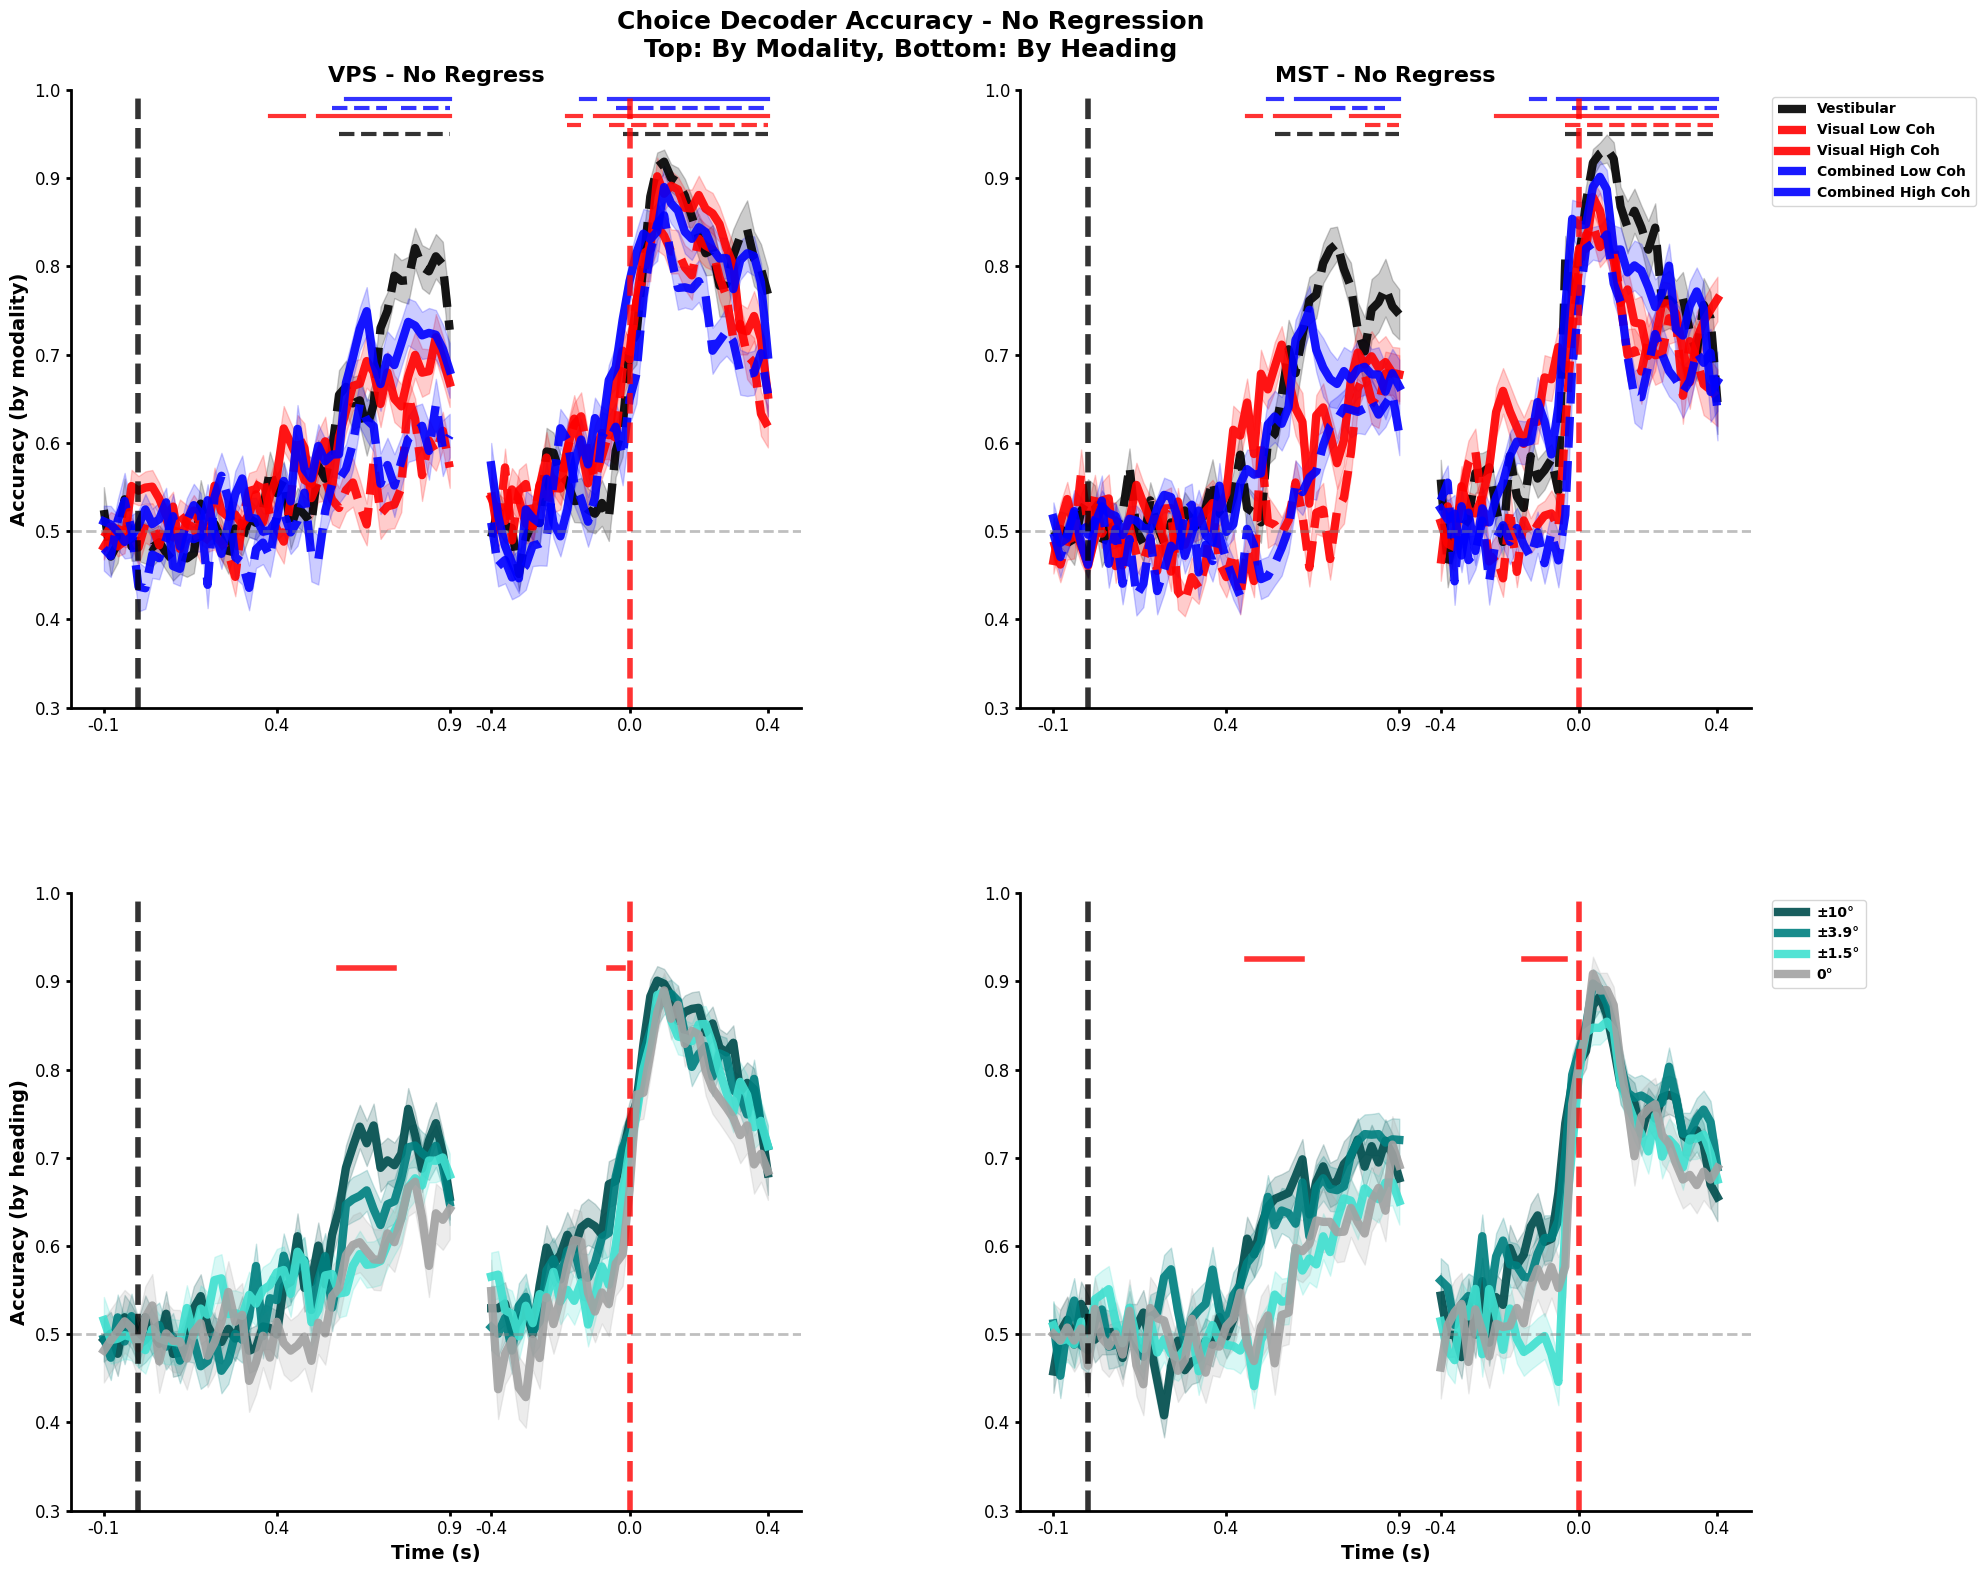


FIGURE GENERATED WITH 4 SUBPLOTS!
1. VPS no regress choice decoder accuracy (by modality) - Top Left
2. MST no regress choice decoder accuracy (by modality) - Top Right
3. VPS no regress choice decoder accuracy (by heading) - Bottom Left
4. MST no regress choice decoder accuracy (by heading) - Bottom Right


In [10]:
import numpy as np
from scipy import stats
from scipy.stats import f_oneway
import matplotlib.pyplot as plt

# Define heading groups with colors
heading_groups = {
    '±10°': ([1, 7], "#004D4D"),   # Very dark teal
    '±3.9°': ([2, 6], "#008080"),   # Medium teal
    '±1.5°': ([3, 5], "#40E0D0"),   # Light turquoise
    '0°': ([4], "#A2A2A2")          # Keep gray for center/0°
}   

# Define modality/coherence combinations with their styles
modality_styles = [
    {'name': 'Vestibular', 'mod': 1, 'coh': 1, 'color': 'black', 'linestyle': '--'},
    {'name': 'Visual Low Coh', 'mod': 2, 'coh': 1, 'color': 'red', 'linestyle': '--'},
    {'name': 'Visual High Coh', 'mod': 2, 'coh': 2, 'color': 'red', 'linestyle': '-'},
    {'name': 'Combined Low Coh', 'mod': 3, 'coh': 1, 'color': 'blue', 'linestyle': '--'},
    {'name': 'Combined High Coh', 'mod': 3, 'coh': 2, 'color': 'blue', 'linestyle': '-'}
]

# Fixed parameters for the four subplots we want
target = 'choice'
areas = ['VPS', 'MST']
regression_method = 'decoders_noregress'
selected_alignments = ['stimOn', 'saccOnset']

# Create a 2x2 figure for the four subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Get time axes for both alignments
stimon_time_axis = time_axes_dots3DMP['stimOn']
saccade_time_axis = time_axes_dots3DMP['saccOnset']

# For saccOnset, only use from -400ms to end
saccade_start_idx = np.where(saccade_time_axis >= -0.4)[0][0]
saccade_time_axis_trimmed = saccade_time_axis[saccade_start_idx:]

# Create combined x-axis positions (indices) and labels
stimon_indices = np.arange(len(stimon_time_axis))
gap_size = 5
saccade_indices = np.arange(len(saccade_time_axis_trimmed)) + len(stimon_time_axis) + gap_size

combined_indices = np.concatenate([stimon_indices, saccade_indices])
combined_time_labels = np.concatenate([stimon_time_axis, saccade_time_axis_trimmed])

# Process each area
for area_idx, area in enumerate(areas):
    print(f"\nProcessing {area}...")
    
    # Row 0: By modality (all headings pooled)
    # Row 1: By heading (all modalities pooled)
    
    # First, process by modality (row 0)
    ax_modality = axes[0, area_idx]
    
    # Store modality data for statistics
    modality_data = {}
    
    # Plot each modality/coherence combination
    for mod_config in modality_styles:
        print(f"  Processing {mod_config['name']}...")
        
        mod = mod_config['mod']
        coh = mod_config['coh']
        color = mod_config['color']
        linestyle = mod_config['linestyle']
        
        # Initialize storage for this modality
        modality_data[mod_config['name']] = {
            'stimon_acc': {t: [] for t in range(len(stimon_time_axis))},
            'saccade_acc': {t: [] for t in range(len(saccade_time_axis_trimmed))},
            'stimon_perm_sig': {t: False for t in range(len(stimon_time_axis))},
            'saccade_perm_sig': {t: False for t in range(len(saccade_time_axis_trimmed))}
        }
        
        # Collect data for this modality/coherence (all headings)
        stimon_acc_by_time = {t: [] for t in range(len(stimon_time_axis))}
        saccade_acc_by_time = {t: [] for t in range(len(saccade_time_axis_trimmed))}
        
        # For permutation test significance
        stimon_perm_pvals = {t: [] for t in range(len(stimon_time_axis))}
        saccade_perm_pvals = {t: [] for t in range(len(saccade_time_axis_trimmed))}
        
        for alignment in selected_alignments:
            time_axis = stimon_time_axis if alignment == 'stimOn' else saccade_time_axis_trimmed
            
            # Collect all trials
            all_trials = []
            for date in dates:
                filepath = get_filepath(date, area, alignment, target, mod, coh, regression=regression_method)
                try:
                    results = np.load(filepath, allow_pickle=True).item()
                    all_trials.extend(results['trial_results'])
                except:
                    continue
            
            # Process all trials
            for trial in all_trials:
                if 'y_test' in trial and 'y_pred' in trial:
                    trial_correct = []
                    
                    for y_t, y_pred in zip(trial['y_test'], trial['y_pred']):
                        trial_correct.append(1 if y_pred == y_t else 0)
                    
                    # Get permutation test p-value
                    p_value = None
                    if 'permutation_test' in trial and 'All' in trial['permutation_test']:
                        p_value = trial['permutation_test']['All']['p_value_accuracy']
                    
                    if trial_correct:
                        time_idx = trial['time']
                        if alignment == 'saccOnset':
                            time_idx = time_idx - saccade_start_idx
                        
                        if 0 <= time_idx < len(time_axis):
                            if alignment == 'stimOn':
                                stimon_acc_by_time[time_idx].append(np.mean(trial_correct))
                                modality_data[mod_config['name']]['stimon_acc'][time_idx].append(np.mean(trial_correct))
                                if p_value is not None:
                                    stimon_perm_pvals[time_idx].append(p_value)
                            else:
                                saccade_acc_by_time[time_idx].append(np.mean(trial_correct))
                                modality_data[mod_config['name']]['saccade_acc'][time_idx].append(np.mean(trial_correct))
                                if p_value is not None:
                                    saccade_perm_pvals[time_idx].append(p_value)
        
        # Calculate baseline correction
        baseline_acc = 0.5
        baseline_acc_vals = []
        for t in range(len(stimon_time_axis)):
            if stimon_time_axis[t] < 0 and stimon_acc_by_time[t]:
                baseline_acc_vals.extend(stimon_acc_by_time[t])
        
        if baseline_acc_vals:
            baseline_acc = np.mean(baseline_acc_vals)
        
        # Determine permutation test significance
        for t in range(len(stimon_time_axis)):
            if stimon_perm_pvals[t] and len(stimon_perm_pvals[t]) > 0:
                sig_count = sum(p < 0.05 for p in stimon_perm_pvals[t])
                modality_data[mod_config['name']]['stimon_perm_sig'][t] = sig_count / len(stimon_perm_pvals[t]) > 0.1
        
        for t in range(len(saccade_time_axis_trimmed)):
            if saccade_perm_pvals[t] and len(saccade_perm_pvals[t]) > 0:
                sig_count = sum(p < 0.05 for p in saccade_perm_pvals[t])
                modality_data[mod_config['name']]['saccade_perm_sig'][t] = sig_count / len(saccade_perm_pvals[t]) > 0.1
        
        # Calculate means and SEMs
        stimon_times = []
        stimon_acc_means = []
        stimon_acc_sems = []
        
        for t in range(len(stimon_time_axis)):
            if stimon_acc_by_time[t]:
                stimon_times.append(stimon_indices[t])
                stimon_acc_means.append(np.mean(stimon_acc_by_time[t]) - baseline_acc + 0.5)
                stimon_acc_sems.append(stats.sem(stimon_acc_by_time[t]))
        
        saccade_times = []
        saccade_acc_means = []
        saccade_acc_sems = []
        
        for t in range(len(saccade_time_axis_trimmed)):
            if saccade_acc_by_time[t]:
                saccade_times.append(saccade_indices[t])
                saccade_acc_means.append(np.mean(saccade_acc_by_time[t]) - baseline_acc + 0.5)
                saccade_acc_sems.append(stats.sem(saccade_acc_by_time[t]))
        
        # Plot with modality-specific color and linestyle
        if stimon_times:
            ax_modality.plot(stimon_times, stimon_acc_means, 
                           color=color, linestyle=linestyle, linewidth=6, 
                           label=mod_config['name'], alpha=0.9)
            ax_modality.fill_between(stimon_times,
                                   np.array(stimon_acc_means) - np.array(stimon_acc_sems),
                                   np.array(stimon_acc_means) + np.array(stimon_acc_sems),
                                   color=color, alpha=0.2)
        
        if saccade_times:
            ax_modality.plot(saccade_times, saccade_acc_means, 
                           color=color, linestyle=linestyle, linewidth=6, alpha=0.9)
            ax_modality.fill_between(saccade_times,
                                   np.array(saccade_acc_means) - np.array(saccade_acc_sems),
                                   np.array(saccade_acc_means) + np.array(saccade_acc_sems),
                                   color=color, alpha=0.2)
    
    # Add significance lines for modalities
    y_min, y_max = ax_modality.get_ylim()
    line_spacing = 0.01
    base_y = 0.95
    
    for mod_idx, (mod_name, mod_data) in enumerate(modality_data.items()):
        mod_config = next(m for m in modality_styles if m['name'] == mod_name)
        
        sig_times = []
        for t in range(len(stimon_time_axis)):
            if mod_data['stimon_perm_sig'][t]:
                sig_times.append(stimon_indices[t])
        for t in range(len(saccade_time_axis_trimmed)):
            if mod_data['saccade_perm_sig'][t]:
                sig_times.append(saccade_indices[t])
        
        if sig_times:
            line_y = base_y + mod_idx * line_spacing
            
            # Group consecutive time points
            sig_groups = []
            current_group = [sig_times[0]]
            
            for i in range(1, len(sig_times)):
                if sig_times[i] - sig_times[i-1] == 1:
                    current_group.append(sig_times[i])
                else:
                    if len(current_group) > 2:
                        sig_groups.append(current_group)
                    current_group = [sig_times[i]]
            if len(current_group) > 2:
                sig_groups.append(current_group)
            
            for group in sig_groups:
                ax_modality.plot([group[0], group[-1]], [line_y, line_y], 
                               color=mod_config['color'], 
                               linestyle=mod_config['linestyle'], 
                               linewidth=3, alpha=0.8)
    
    # Now process by heading (row 1)
    ax_heading = axes[1, area_idx]
    
    # Store heading data for statistics
    heading_data = {}
    all_heading_plot_data = {}
    
    # Process each heading group
    for group_name, (heading_indices, heading_color) in heading_groups.items():
        print(f"  Processing {group_name} (all modalities pooled)...")
        
        # Initialize storage
        heading_data[group_name] = {
            'stimon_acc': {t: [] for t in range(len(stimon_time_axis))},
            'saccade_acc': {t: [] for t in range(len(saccade_time_axis_trimmed))}
        }
        
        # Collect data from all modalities
        stimon_acc_by_time = {t: [] for t in range(len(stimon_time_axis))}
        saccade_acc_by_time = {t: [] for t in range(len(saccade_time_axis_trimmed))}
        
        for mod_config in modality_styles:
            mod = mod_config['mod']
            coh = mod_config['coh']
            
            for alignment in selected_alignments:
                time_axis = stimon_time_axis if alignment == 'stimOn' else saccade_time_axis_trimmed
                
                all_trials = []
                for date in dates:
                    filepath = get_filepath(date, area, alignment, target, mod, coh, regression=regression_method)
                    try:
                        results = np.load(filepath, allow_pickle=True).item()
                        all_trials.extend(results['trial_results'])
                    except:
                        continue
                
                for trial in all_trials:
                    if 'test_behavior' in trial and 'headingInd' in trial['test_behavior']:
                        test_heading_indices = trial['test_behavior']['headingInd']
                        heading_mask = np.isin(test_heading_indices, heading_indices)
                        
                        if not np.any(heading_mask):
                            continue
                        
                        y_test_filtered = np.array(trial['y_test'])[heading_mask]
                        y_pred_filtered = np.array(trial['y_pred'])[heading_mask]
                        
                        trial_correct = []
                        for y_t, y_pred in zip(y_test_filtered, y_pred_filtered):
                            trial_correct.append(1 if y_pred == y_t else 0) 
                        if trial_correct:
                            time_idx = trial['time']
                            if alignment == 'saccOnset':
                                time_idx = time_idx - saccade_start_idx
                            
                            if 0 <= time_idx < len(time_axis):
                                if alignment == 'stimOn':
                                    stimon_acc_by_time[time_idx].append(np.mean(trial_correct))
                                    heading_data[group_name]['stimon_acc'][time_idx].append(np.mean(trial_correct))
                                else:
                                    saccade_acc_by_time[time_idx].append(np.mean(trial_correct))
                                    heading_data[group_name]['saccade_acc'][time_idx].append(np.mean(trial_correct))
        
        # Calculate baseline correction
        baseline_acc = 0.5
        baseline_acc_vals = []
        for t in range(len(stimon_time_axis)):
            if stimon_time_axis[t] < 0 and stimon_acc_by_time[t]:
                baseline_acc_vals.extend(stimon_acc_by_time[t])
        
        if baseline_acc_vals:
            baseline_acc = np.mean(baseline_acc_vals)
        
        # Store plot data
        all_heading_plot_data[group_name] = {
            'color': heading_color,
            'baseline_acc': baseline_acc,
            'stimon_acc_by_time': stimon_acc_by_time,
            'saccade_acc_by_time': saccade_acc_by_time
        }
    
    # Plot all headings
    for group_name, plot_data in all_heading_plot_data.items():
        # Calculate means and SEMs
        stimon_times = []
        stimon_acc_means = []
        stimon_acc_sems = []
        
        for t in range(len(stimon_time_axis)):
            if plot_data['stimon_acc_by_time'][t]:
                stimon_times.append(stimon_indices[t])
                stimon_acc_means.append(np.mean(plot_data['stimon_acc_by_time'][t]) - plot_data['baseline_acc'] + 0.5)
                stimon_acc_sems.append(stats.sem(plot_data['stimon_acc_by_time'][t]))
        
        saccade_times = []
        saccade_acc_means = []
        saccade_acc_sems = []
        
        for t in range(len(saccade_time_axis_trimmed)):
            if plot_data['saccade_acc_by_time'][t]:
                saccade_times.append(saccade_indices[t])
                saccade_acc_means.append(np.mean(plot_data['saccade_acc_by_time'][t]) - plot_data['baseline_acc'] + 0.5)
                saccade_acc_sems.append(stats.sem(plot_data['saccade_acc_by_time'][t]))
        
        # Plot with SEM shading
        if stimon_times:
            ax_heading.plot(stimon_times, stimon_acc_means, 
                          color=plot_data['color'], linestyle='-', linewidth=6, 
                          label=group_name, alpha=0.9)
            ax_heading.fill_between(stimon_times,
                                  np.array(stimon_acc_means) - np.array(stimon_acc_sems),
                                  np.array(stimon_acc_means) + np.array(stimon_acc_sems),
                                  color=plot_data['color'], alpha=0.2)
        
        if saccade_times:
            ax_heading.plot(saccade_times, saccade_acc_means, 
                          color=plot_data['color'], linestyle='-', linewidth=6, alpha=0.9)
            ax_heading.fill_between(saccade_times,
                                  np.array(saccade_acc_means) - np.array(saccade_acc_sems),
                                  np.array(saccade_acc_means) + np.array(saccade_acc_sems),
                                  color=plot_data['color'], alpha=0.2)
    
    # Add correlation analysis for heading comparisons
    y_min, y_max = ax_heading.get_ylim()
    line_y = y_max - 0.05 * (y_max - y_min)
    
    # Define heading values for correlation
    heading_order = ['0°', '±1.5°', '±3.9°', '±10°']
    heading_values = [0, 1.5, 3.9, 10]
    
    # Perform correlation at each time point
    corr_sig_times_pos = []
    corr_sig_times_neg = []
    
    for t in range(len(stimon_time_axis)):
        if stimon_time_axis[t] >= 0:  # Only after stimulus onset
            all_headings = []
            all_values = []
            
            for i, group_name in enumerate(heading_order):
                if group_name in heading_data:
                    group_values = heading_data[group_name]['stimon_acc'][t]
                    if group_values:
                        all_headings.extend([heading_values[i]] * len(group_values))
                        all_values.extend(group_values)
            
            if len(all_headings) >= 20:
                r, p_val = stats.pearsonr(all_headings, all_values)
                if p_val < 0.05:
                    if r > 0:
                        corr_sig_times_pos.append(stimon_indices[t])
                    else:
                        corr_sig_times_neg.append(stimon_indices[t])
    
    # Perform correlation for saccade alignment
    corr_sig_times_pos_saccade = []
    corr_sig_times_neg_saccade = []
    
    for t in range(len(saccade_time_axis_trimmed)):
        all_headings = []
        all_values = []
        
        for i, group_name in enumerate(heading_order):
            if group_name in heading_data:
                group_values = heading_data[group_name]['saccade_acc'][t]
                if group_values:
                    all_headings.extend([heading_values[i]] * len(group_values))
                    all_values.extend(group_values)
        
        if len(all_headings) >= 20:
            r, p_val = stats.pearsonr(all_headings, all_values)
            if p_val < 0.05:
                if r > 0:
                    corr_sig_times_pos_saccade.append(saccade_indices[t])
                else:
                    corr_sig_times_neg_saccade.append(saccade_indices[t])
    
    # Combine and plot significance lines
    all_corr_sig_times_pos = corr_sig_times_pos + corr_sig_times_pos_saccade
    all_corr_sig_times_neg = corr_sig_times_neg + corr_sig_times_neg_saccade
    
    # Plot positive correlations (red, solid)
    if all_corr_sig_times_pos:
        sig_groups = []
        current_group = [all_corr_sig_times_pos[0]]
        
        for i in range(1, len(all_corr_sig_times_pos)):
            if all_corr_sig_times_pos[i] - all_corr_sig_times_pos[i-1] == 1:
                current_group.append(all_corr_sig_times_pos[i])
            else:
                if len(current_group) > 2:
                    sig_groups.append(current_group)
                current_group = [all_corr_sig_times_pos[i]]
        if len(current_group) > 2:
            sig_groups.append(current_group)
        
        for group in sig_groups:
            ax_heading.plot([group[0], group[-1]], [line_y, line_y], 
                          color='red', linestyle='-', linewidth=4, alpha=0.8)
    
    # Plot negative correlations (blue, dashed)
    if all_corr_sig_times_neg:
        sig_groups = []
        current_group = [all_corr_sig_times_neg[0]]
        
        for i in range(1, len(all_corr_sig_times_neg)):
            if all_corr_sig_times_neg[i] - all_corr_sig_times_neg[i-1] == 1:
                current_group.append(all_corr_sig_times_neg[i])
            else:
                if len(current_group) > 2:
                    sig_groups.append(current_group)
                current_group = [all_corr_sig_times_neg[i]]
        if len(current_group) > 2:
            sig_groups.append(current_group)
        
        for group in sig_groups:
            ax_heading.plot([group[0], group[-1]], [line_y - 0.02 * (y_max - y_min), line_y - 0.02 * (y_max - y_min)], 
                          color='blue', linestyle='--', linewidth=3, alpha=0.8)
    
    # Format both subplots for this area
    for row_idx, ax in enumerate([ax_modality, ax_heading]):
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add reference line
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=2)
        
        # Add event alignment markers
        stimon_zero_idx = np.where(stimon_time_axis >= 0)[0][0]
        saccade_zero_idx = saccade_indices[0] + np.where(saccade_time_axis_trimmed >= 0)[0][0]
        
        ax.axvline(x=stimon_zero_idx, color='black', linestyle='--', alpha=0.8, linewidth=4)
        ax.axvline(x=saccade_zero_idx, color='red', linestyle='--', alpha=0.8, linewidth=4)
        
        # Set custom x-axis ticks and labels
        stimon_ticks = [0, len(stimon_time_axis)//2, len(stimon_time_axis)-1]
        saccade_ticks = [saccade_indices[0], 
                        saccade_indices[len(saccade_indices)//2], 
                        saccade_indices[-1]]

        tick_indices = stimon_ticks + saccade_ticks

        stimon_tick_labels = [f'{stimon_time_axis[t]:.1f}' for t in stimon_ticks]
        saccade_tick_labels = [f'{saccade_time_axis_trimmed[0]:.1f}',
                            f'{saccade_time_axis_trimmed[len(saccade_time_axis_trimmed)//2]:.1f}',
                            f'{saccade_time_axis_trimmed[-1]:.1f}']

        tick_labels = stimon_tick_labels + saccade_tick_labels

        ax.set_xticks(tick_indices)
        ax.set_xticklabels(tick_labels)
        
        # Set labels
        if row_idx == 1:  # Bottom row
            ax.set_xlabel('Time (s)', fontsize=14, fontweight='bold')
        
        if area_idx == 0:  # Left column
            if row_idx == 0:
                ax.set_ylabel('Accuracy (by modality)', fontsize=14, fontweight='bold')
            else:
                ax.set_ylabel('Accuracy (by heading)', fontsize=14, fontweight='bold')
        
        # Set title for top row
        if row_idx == 0:
            ax.set_title(f'{area} - No Regress', fontsize=16, fontweight='bold')
        
        # Set y-limits
        ax.set_ylim(0.3, 1.0)
        
        # Add legend
        if area_idx == 1:  # Right column
            ax.legend(fontsize=12, prop={'weight': 'bold'}, loc='upper left', bbox_to_anchor=(1.02, 1))
        
        # Make remaining spines thicker
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        ax.tick_params(width=2, labelsize=12)

# Add overall title
fig.suptitle('Choice Decoder Accuracy - No Regression\nTop: By Modality, Bottom: By Heading', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.subplots_adjust(top=0.93, left=0.08, right=0.92, hspace=0.3, wspace=0.3)

# Save figure
save_filename = "D:\\Neural-Pipeline\\results\\analysis_population\\choice_decoder_accuracy_4subplots.png"
plt.savefig(save_filename, dpi=300, bbox_inches='tight')
print(f"\nFigure saved as: {save_filename}")

plt.show()

print("\n" + "="*80)
print("FIGURE GENERATED WITH 4 SUBPLOTS!")
print("="*80)
print("1. VPS no regress choice decoder accuracy (by modality) - Top Left")
print("2. MST no regress choice decoder accuracy (by modality) - Top Right")
print("3. VPS no regress choice decoder accuracy (by heading) - Bottom Left")
print("4. MST no regress choice decoder accuracy (by heading) - Bottom Right")

### SFN PDW / RT


################################################################################
RUNNING ANALYSIS TYPE: RAW
################################################################################

ANALYZING CHOICE DECODER - RAW



VPS z-score params - Mean: 0.5053, Std: 0.0908

MST z-score params - Mean: 0.5070, Std: 0.0834



Processing MST choice decoder, split by PDW (Combined modality only)...

Processing MST choice decoder, split by RT (Combined modality only)...

Processing VPS choice decoder, split by PDW (Combined modality only)...

Processing VPS choice decoder, split by RT (Combined modality only)...

Figure saved as: D:\Neural-Pipeline\results\analysis_population\choice_decoder_raw_combined_only_weak_headings_RT_PDW_zscore.png


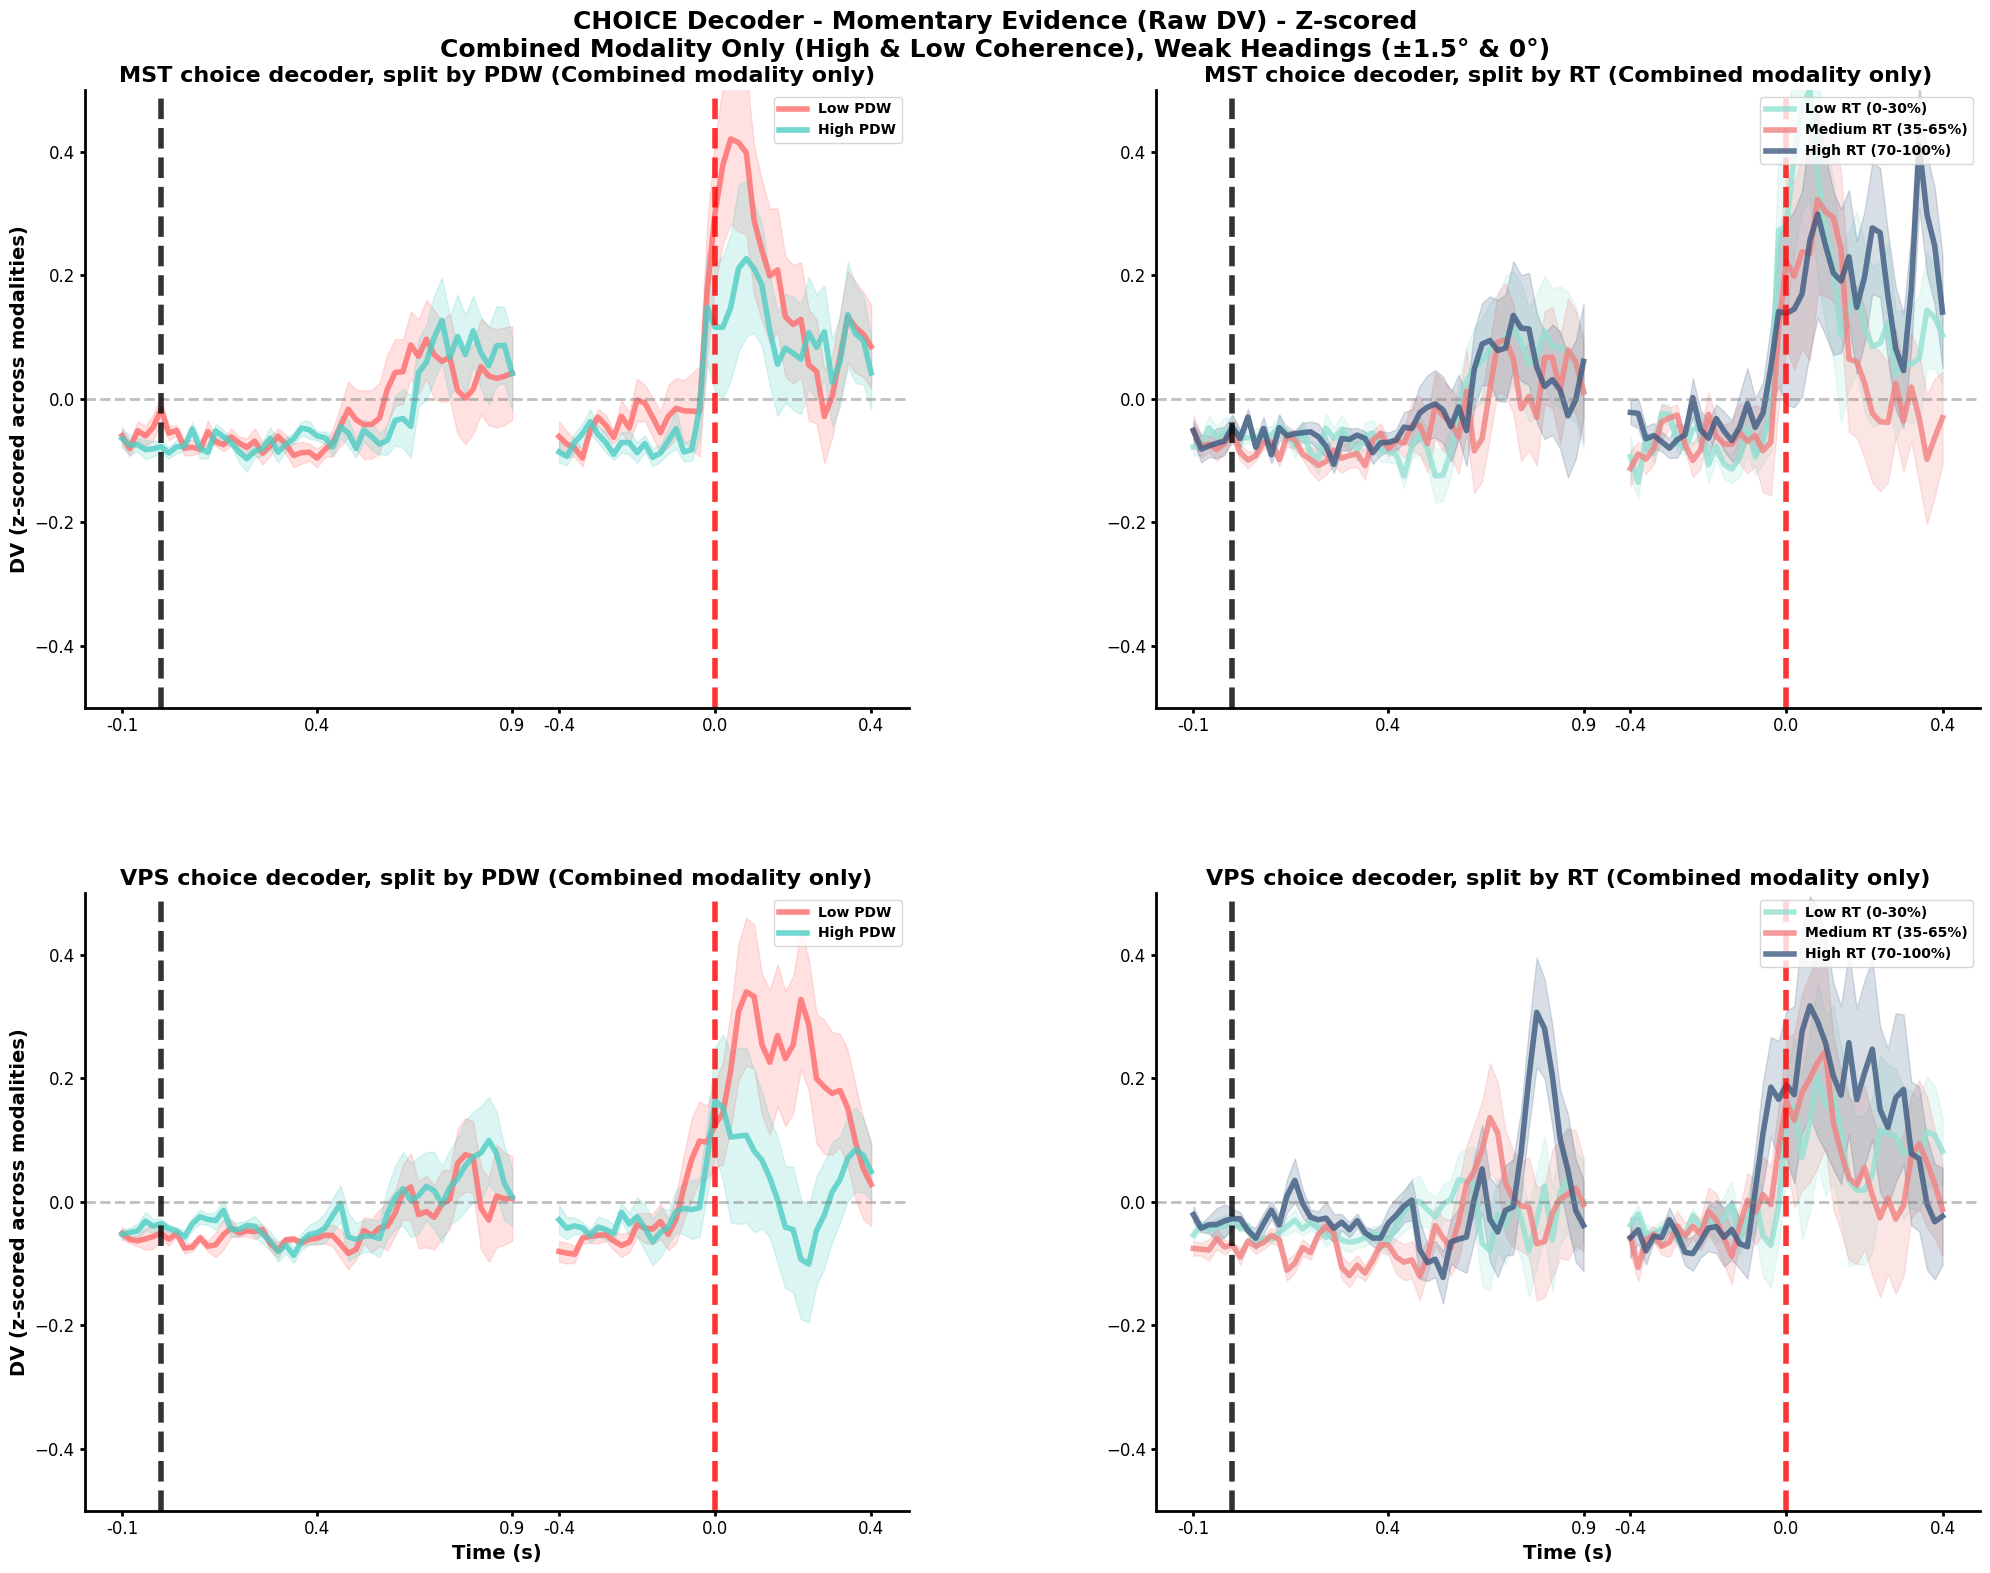


SUMMARY STATISTICS - CHOICE DECODER - RAW

VPS Area:
  Total trials: 60352
  Z-score parameters (from all modalities):
    Mean: 0.5053
    Std: 0.0908
  Heading distribution:
    Heading 3.0 (-1.5°): 8648 samples
    Heading 4.0 (0°): 9200 samples
    Heading 5.0 (+1.5°): 8648 samples
  PDW - Median: 0.78, Mean: 0.75, Std: 0.18
  PDW - Low: 28704 trials, High: 31648 trials
  RT - Mean: 0.685s, Std: 0.067s
  RT - Percentiles: 30th=0.642s, 65th=0.706s, 70th=0.716s
  RT - Low: 18216 trials, Medium: 19320 trials, High: 18216 trials

  Coherence distribution (Combined modality only):
    Low coherence: 30544 samples
    High coherence: 29808 samples

MST Area:
  Total trials: 60352
  Z-score parameters (from all modalities):
    Mean: 0.5070
    Std: 0.0834
  Heading distribution:
    Heading 3.0 (-1.5°): 8648 samples
    Heading 4.0 (0°): 9200 samples
    Heading 5.0 (+1.5°): 8648 samples
  PDW - Median: 0.78, Mean: 0.75, Std: 0.18
  PDW - Low: 28704 trials, High: 31648 trials
  RT - Mea

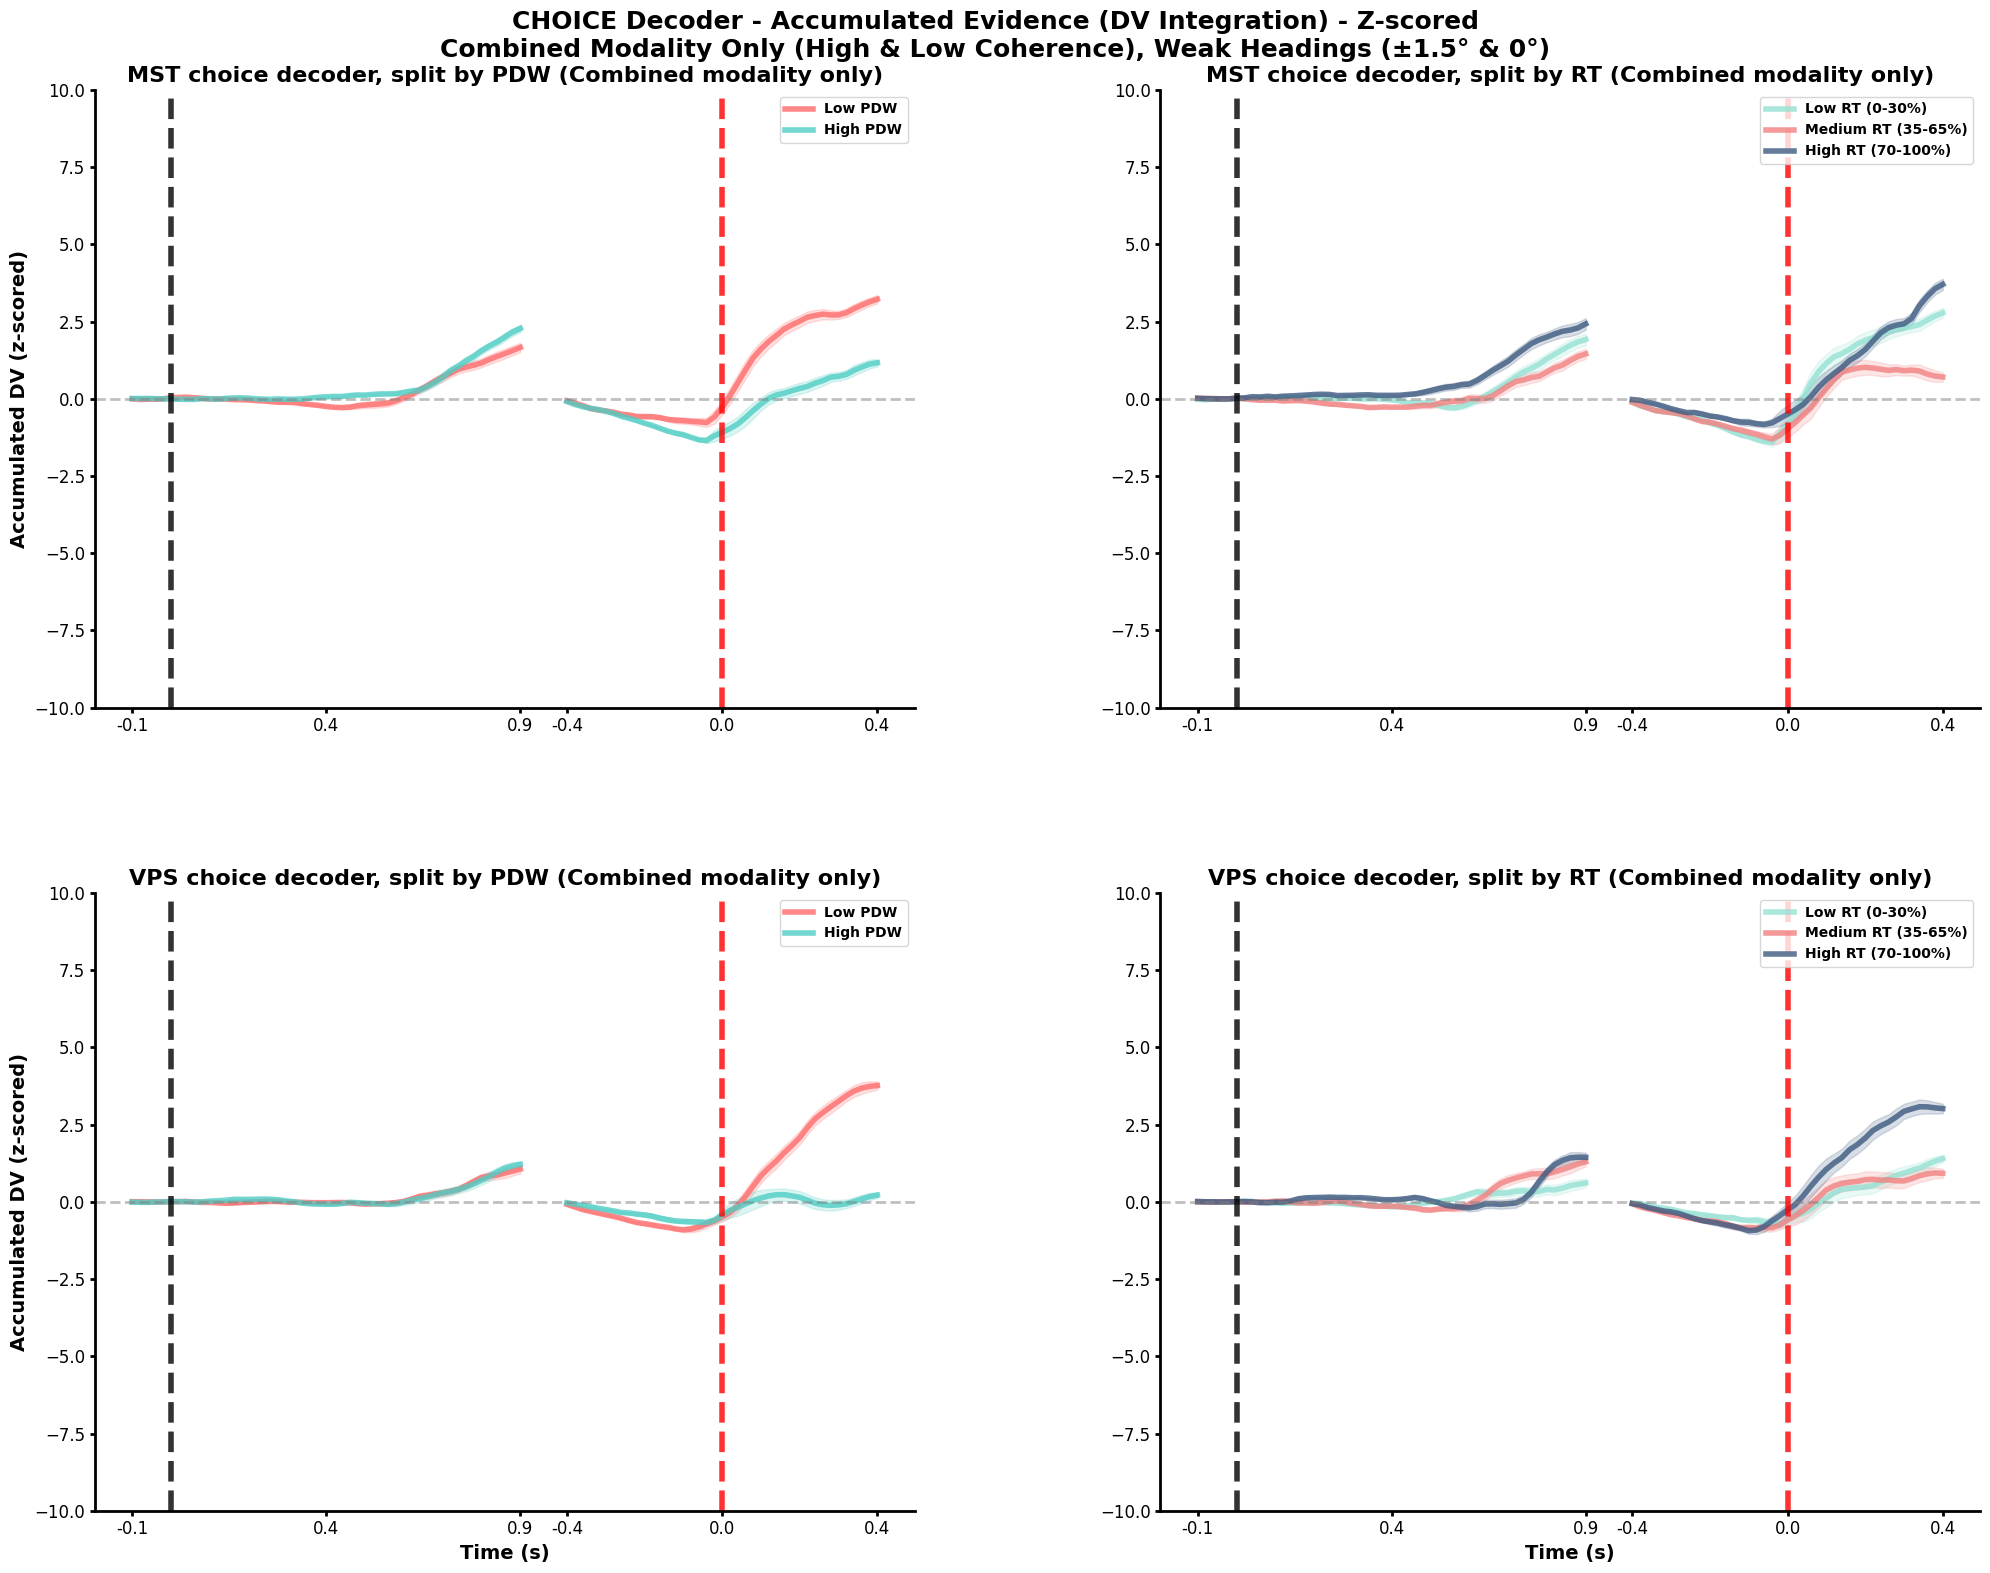


SUMMARY STATISTICS - CHOICE DECODER - ACCUMULATION

VPS Area:
  Total trials: 60352
  Z-score parameters (from all modalities):
    Mean: 0.5053
    Std: 0.0908
  Heading distribution:
    Heading 3.0 (-1.5°): 8648 samples
    Heading 4.0 (0°): 9200 samples
    Heading 5.0 (+1.5°): 8648 samples
  PDW - Median: 0.78, Mean: 0.75, Std: 0.18
  PDW - Low: 28704 trials, High: 31648 trials
  RT - Mean: 0.685s, Std: 0.067s
  RT - Percentiles: 30th=0.642s, 65th=0.706s, 70th=0.716s
  RT - Low: 18216 trials, Medium: 19320 trials, High: 18216 trials

  Coherence distribution (Combined modality only):
    Low coherence: 30544 samples
    High coherence: 29808 samples

MST Area:
  Total trials: 60352
  Z-score parameters (from all modalities):
    Mean: 0.5070
    Std: 0.0834
  Heading distribution:
    Heading 3.0 (-1.5°): 8648 samples
    Heading 4.0 (0°): 9200 samples
    Heading 5.0 (+1.5°): 8648 samples
  PDW - Median: 0.78, Mean: 0.75, Std: 0.18
  PDW - Low: 28704 trials, High: 31648 trials
 

In [56]:
import numpy as np
from scipy import stats
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Define ALL modality conditions for z-score calculation
all_modality_styles = [
    # {'name': 'Vestibular Low Coh', 'mod': 1, 'coh': 1, 'color': 'green', 'linestyle': '--'},
    # {'name': 'Vestibular High Coh', 'mod': 1, 'coh': 2, 'color': 'green', 'linestyle': '-'},
    # {'name': 'Visual Low Coh', 'mod': 2, 'coh': 1, 'color': 'purple', 'linestyle': '--'},
    # {'name': 'Visual High Coh', 'mod': 2, 'coh': 2, 'color': 'purple', 'linestyle': '-'},
    {'name': 'Combined Low Coh', 'mod': 3, 'coh': 1, 'color': 'blue', 'linestyle': '--'},
    {'name': 'Combined High Coh', 'mod': 3, 'coh': 2, 'color': 'blue', 'linestyle': '-'}
]


modality_styles = all_modality_styles

# Fixed parameters
areas = ['VPS', 'MST']
regression_method = 'decoders_noregress'
selected_alignments = ['stimOn', 'saccOnset']
SELECTED_HEADINGS = [3,   4, 5]  # Use headings 3, 4, and 5 (±1.5° and 0°)

# Analysis options
SMOOTH_WINDOW = 5  # Smoothing window for slope calculation

# Define what to analyze
targets_to_analyze = ['choice']  # Analyze both

# Function to extract DV from decoder predictions
def extract_dv_from_decoder(trial):
    """Extract decision variable (DV) from decoder predictions"""
    if 'y_proba' in trial and trial['y_proba'] is not None:
        # Use probability differences as DV
        y_proba = np.array(trial['y_proba'])
        if len(y_proba.shape) == 2 and y_proba.shape[1] == 2:
            dv = y_proba[:, 1] - y_proba[:, 0]  # P(right/choice1) - P(left/choice0)
        else:
            dv = y_proba
    elif 'y_pred_proba' in trial:
        # Alternative field name
        dv = trial['y_pred_proba'][:, 1] - trial['y_pred_proba'][:, 0]
    elif 'decision_values' in trial:
        # If we have decision values directly
        dv = trial['decision_values']
    else:
        # Fallback: use binary predictions
        dv = np.array(trial['y_pred']) * 2 - 1  # Convert 0/1 to -1/1
    return dv

# Function to process DV based on analysis type
def process_dv(dv_values, analysis_type='raw'):
    """
    Process DV values based on analysis type
    
    Parameters:
    - dv_values: array of DV values
    - analysis_type: 'raw', 'slope', or 'accumulation'
    """
    if analysis_type == 'raw':
        # Return raw DV values (momentary evidence)
        return dv_values
    
    elif analysis_type == 'slope':
        # Calculate derivative (rate of change)
        # First, smooth the signal
        if len(dv_values) > SMOOTH_WINDOW:
            smoothed = gaussian_filter1d(dv_values, sigma=SMOOTH_WINDOW/4)
        else:
            smoothed = dv_values
        
        # Calculate derivative
        if len(smoothed) > 1:
            slopes = np.gradient(smoothed)
        else:
            slopes = np.zeros_like(smoothed)
        
        return slopes
    
    elif analysis_type == 'accumulation':
        # For accumulation, we'll handle this differently in the main loop
        # Just return raw values here
        return dv_values
    
    else:
        raise ValueError(f"Unknown analysis type: {analysis_type}")

# Define RT and PDW categorization functions
def categorize_rt(rt_values):
    """Categorize RT into three groups based on percentiles"""
    valid_rt = rt_values[~np.isnan(rt_values)]
    if len(valid_rt) == 0:
        return np.full_like(rt_values, np.nan)
    
    p30 = np.percentile(valid_rt, 30)
    p35 = np.percentile(valid_rt, 35)
    p65 = np.percentile(valid_rt, 65)
    p70 = np.percentile(valid_rt, 70)
    
    rt_category = np.full_like(rt_values, np.nan)
    rt_category[rt_values <= p30] = 0  # Low RT (0-30%)
    rt_category[(rt_values >= p35) & (rt_values <= p65)] = 1  # Medium RT (35-65%)
    rt_category[rt_values >= p70] = 2  # High RT (70-100%)
    
    return rt_category

def categorize_pdw(pdw_values):
    """Categorize PDW into high/low based on median split"""
    valid_pdw = pdw_values[~np.isnan(pdw_values)]
    if len(valid_pdw) == 0:
        return np.full_like(pdw_values, np.nan)
    
    median_pdw = np.median(valid_pdw)
    pdw_category = np.full_like(pdw_values, np.nan)
    pdw_category[pdw_values < median_pdw] = 0  # Low PDW
    pdw_category[pdw_values >= median_pdw] = 1  # High PDW
    
    return pdw_category

# Run all three analysis types
for DV_ANALYSIS_TYPE in ['raw', 'accumulation']: #for DV_ANALYSIS_TYPE in ['raw', 'slope', 'accumulation']:
    print(f"\n{'#'*80}")
    print(f"RUNNING ANALYSIS TYPE: {DV_ANALYSIS_TYPE.upper()}")
    print(f"{'#'*80}")
    
    # Loop through each target (choice and stimulus)
    for target in targets_to_analyze:
        print(f"\n{'='*80}")
        print(f"ANALYZING {target.upper()} DECODER - {DV_ANALYSIS_TYPE.upper()}")
        print(f"{'='*80}")
        
        # Create figure with 4 subplots
        fig, axes = plt.subplots(2, 2, figsize=(20, 16))
        
        # Get time axes for both alignments
        stimon_time_axis = time_axes_dots3DMP['stimOn']
        saccade_time_axis = time_axes_dots3DMP['saccOnset']
        
        # For saccOnset, only use from -400ms to end
        saccade_start_idx = np.where(saccade_time_axis >= -0.4)[0][0]
        saccade_time_axis_trimmed = saccade_time_axis[saccade_start_idx:]
        
        # Create combined x-axis positions (indices) and labels
        stimon_indices = np.arange(len(stimon_time_axis))
        gap_size = 5
        saccade_indices = np.arange(len(saccade_time_axis_trimmed)) + len(stimon_time_axis) + gap_size
        
        combined_indices = np.concatenate([stimon_indices, saccade_indices])
        combined_time_labels = np.concatenate([stimon_time_axis, saccade_time_axis_trimmed])
        
        # First, collect ALL modality data for z-score normalization
        all_modality_data = {area: [] for area in areas}
        
        for area in areas:
            print(f"\nCollecting ALL modality data for {area} to compute z-scores...")
            
            # Collect data from ALL modalities
            for mod_config in all_modality_styles:
                mod = mod_config['mod']
                coh = mod_config['coh']
                
                for alignment in selected_alignments:
                    all_trials = []
                    for date in dates:
                        filepath = get_filepath(date, area, alignment, target, mod, coh, regression=regression_method)
                        try:
                            results = np.load(filepath, allow_pickle=True).item()
                            all_trials.extend(results['trial_results'])
                        except:
                            continue
                    
                    # Process trials
                    for trial in all_trials:
                        if 'y_test' in trial and 'y_pred' in trial:
                            # Extract DV
                            dv = extract_dv_from_decoder(trial)
                            
                            # Get behavioral data if available
                            if 'test_behavior' in trial:
                                behavior = trial['test_behavior']
                                
                                # Extract heading indices
                                heading_ind = behavior.get('headingInd', [])
                                
                                # FILTER FOR SELECTED HEADINGS ONLY
                                if hasattr(heading_ind, '__len__'):
                                    if not any(h in heading_ind for h in SELECTED_HEADINGS):
                                        continue
                                else:
                                    if heading_ind not in SELECTED_HEADINGS:
                                        continue
                                
                                # Store all DV values for z-score calculation
                                all_modality_data[area].extend(dv)
        
        # Compute z-score parameters across all modalities
        z_score_params = {}
        for area in areas:
            if all_modality_data[area]:
                z_score_params[area] = {
                    'mean': np.mean(all_modality_data[area]),
                    'std': np.std(all_modality_data[area])
                }
                print(f"\n{area} z-score params - Mean: {z_score_params[area]['mean']:.4f}, Std: {z_score_params[area]['std']:.4f}")
            else:
                z_score_params[area] = {'mean': 0, 'std': 1}
        
        # Now collect data ONLY from Combined modality for analysis
        all_data = {area: {} for area in areas}
        
        for area in areas:
            print(f"\nCollecting {target} decoder data for {area} (Combined modality only)...")
            
            # Initialize storage
            all_data[area] = {
                'dv': [],
                'pdw': [],
                'rt': [],
                'modality': [],
                'coherence': [],
                'heading': [],
                'time_indices': [],
                'alignment': []
            }
            
            # Collect data ONLY from Combined modality
            for mod_config in modality_styles:
                mod = mod_config['mod']
                coh = mod_config['coh']
                
                for alignment in selected_alignments:
                    all_trials = []
                    for date in dates:
                        filepath = get_filepath(date, area, alignment, target, mod, coh, regression=regression_method)
                        try:
                            results = np.load(filepath, allow_pickle=True).item()
                            all_trials.extend(results['trial_results'])
                        except:
                            continue
                    
                    # Process trials
                    for trial in all_trials:
                        if 'y_test' in trial and 'y_pred' in trial:
                            # Extract DV
                            dv = extract_dv_from_decoder(trial)
                            
                            # Get behavioral data if available
                            if 'test_behavior' in trial:
                                behavior = trial['test_behavior']
                                
                                # Extract heading indices
                                heading_ind = behavior.get('headingInd', [])
                                
                                # FILTER FOR SELECTED HEADINGS ONLY
                                if hasattr(heading_ind, '__len__'):
                                    if not any(h in heading_ind for h in SELECTED_HEADINGS):
                                        continue
                                else:
                                    if heading_ind not in SELECTED_HEADINGS:
                                        continue
                                
                                # Extract PDW and RT
                                pdw_values = behavior.get('PDW', np.nan)
                                if hasattr(pdw_values, '__len__'):
                                    pdw = np.mean(pdw_values) if len(pdw_values) > 0 else np.nan
                                else:
                                    pdw = pdw_values
                                
                                rt_values = behavior.get('RT', np.nan)
                                if hasattr(rt_values, '__len__'):
                                    rt = np.mean(rt_values) if len(rt_values) > 0 else np.nan
                                else:
                                    rt = rt_values
                                
                                # Store data
                                time_idx = trial['time']
                                if alignment == 'saccOnset':
                                    time_idx = time_idx - saccade_start_idx
                                
                                if 0 <= time_idx < (len(stimon_time_axis) if alignment == 'stimOn' else len(saccade_time_axis_trimmed)):
                                    # For each trial (each element in dv)
                                    for i, dv_val in enumerate(dv):
                                        all_data[area]['dv'].append(dv_val)
                                        all_data[area]['pdw'].append(pdw)
                                        all_data[area]['rt'].append(rt)
                                        all_data[area]['modality'].append(mod)
                                        all_data[area]['coherence'].append(coh)
                                        all_data[area]['heading'].append(heading_ind[i] if hasattr(heading_ind, '__len__') and i < len(heading_ind) else heading_ind)
                                        all_data[area]['time_indices'].append(time_idx)
                                        all_data[area]['alignment'].append(alignment)
        
        # Convert to numpy arrays
        for area in areas:
            for key in all_data[area]:
                all_data[area][key] = np.array(all_data[area][key])
        
        # Process data and create plots
        # Process data and create plots
        plot_configs = [
            {'row': 0, 'col': 0, 'area': 'MST', 'split_by': 'PDW', 'title': f'MST {target} decoder, split by PDW (Combined modality only)'},
            {'row': 0, 'col': 1, 'area': 'MST', 'split_by': 'RT', 'title': f'MST {target} decoder, split by RT (Combined modality only)'},
            {'row': 1, 'col': 0, 'area': 'VPS', 'split_by': 'PDW', 'title': f'VPS {target} decoder, split by PDW (Combined modality only)'},
            {'row': 1, 'col': 1, 'area': 'VPS', 'split_by': 'RT', 'title': f'VPS {target} decoder, split by RT (Combined modality only)'}
        ]
        
        # Define colors for splits
        pdw_colors = {0: '#FF6B6B', 1: '#4ECDC4'}  # Low: red, High: teal
        rt_colors = {0: '#95E1D3', 1: '#F38181', 2: '#3D5A80'}  # Low: light teal, Medium: salmon, High: dark blue
        
        for config in plot_configs:
            ax = axes[config['row'], config['col']]
            area = config['area']
            split_by = config['split_by']
            
            print(f"\nProcessing {config['title']}...")
            
            # Get data for this area
            area_data = all_data[area]
            
            # Apply z-score normalization using parameters from ALL modalities
            z_mean = z_score_params[area]['mean']
            z_std = z_score_params[area]['std']
            
            if z_std > 0:
                normalized_dv = (area_data['dv'] - z_mean) / z_std
            else:
                normalized_dv = area_data['dv'] - z_mean
            
     
            # Categorize split variable
            if split_by == 'PDW':
                split_categories = categorize_pdw(area_data['pdw'])
                split_labels = ['Low PDW', 'High PDW']
                split_colors = pdw_colors
            else:  # RT
                split_categories = categorize_rt(area_data['rt'])
                split_labels = ['Low RT (0-30%)', 'Medium RT (35-65%)', 'High RT (70-100%)']
                split_colors = rt_colors
            
            # Special handling for accumulation
            if DV_ANALYSIS_TYPE == 'accumulation':
                # For accumulation, use z-scored DV values
                for cat_idx, cat_label in enumerate(split_labels):
                    if split_by == 'RT' and cat_idx == 3:
                        continue
                    
                    cat_mask = (split_categories == cat_idx) & ~np.isnan(normalized_dv)
                    
                    if np.sum(cat_mask) == 0:
                        continue
                    
                    # For stimOn alignment
                    stimon_values_by_time = {t: [] for t in range(len(stimon_time_axis))}
                    stimon_mask = (area_data['alignment'] == 'stimOn') & cat_mask
                    
                    for i in np.where(stimon_mask)[0]:
                        t_idx = area_data['time_indices'][i]
                        if 0 <= t_idx < len(stimon_time_axis):
                            stimon_values_by_time[t_idx].append(normalized_dv[i])
                    
                    # Calculate mean at each time point
                    stimon_mean_by_time = []
                    for t in range(len(stimon_time_axis)):
                        if stimon_values_by_time[t]:
                            stimon_mean_by_time.append(np.mean(stimon_values_by_time[t]))
                        else:
                            stimon_mean_by_time.append(0)
                    
                    # Find stimulus onset for baseline correction
                    stim_onset_idx = np.where(stimon_time_axis >= 0)[0][0]
                    
                    # Accumulate with baseline correction
                    stimon_times = []
                    stimon_accumulated = []
                    stimon_sems = []
                    cumulative_sum = 0
                    
                    # Calculate baseline (pre-stimulus mean)
                    baseline = np.mean(stimon_mean_by_time[:stim_onset_idx]) if stim_onset_idx > 0 else 0
                    
                    for t in range(len(stimon_time_axis)):
                        # Subtract baseline before accumulating
                        cumulative_sum += (stimon_mean_by_time[t] - baseline)
                        stimon_times.append(stimon_indices[t])
                        stimon_accumulated.append(cumulative_sum)
                        
                        if stimon_values_by_time[t]:
                            stimon_sems.append(stats.sem(stimon_values_by_time[t]))
                        else:
                            stimon_sems.append(0)
                    
                    # For saccade alignment
                    saccade_values_by_time = {t: [] for t in range(len(saccade_time_axis_trimmed))}
                    saccade_mask = (area_data['alignment'] == 'saccOnset') & cat_mask
                    
                    for i in np.where(saccade_mask)[0]:
                        t_idx = area_data['time_indices'][i]
                        if 0 <= t_idx < len(saccade_time_axis_trimmed):
                            saccade_values_by_time[t_idx].append(normalized_dv[i])
                    
                    # Calculate mean at each time point
                    saccade_mean_by_time = []
                    for t in range(len(saccade_time_axis_trimmed)):
                        if saccade_values_by_time[t]:
                            saccade_mean_by_time.append(np.mean(saccade_values_by_time[t]))
                        else:
                            saccade_mean_by_time.append(0)
                    
                    # Accumulate
                    saccade_times = []
                    saccade_accumulated = []
                    saccade_sems = []
                    cumulative_sum = 0
                    
                    for t in range(len(saccade_time_axis_trimmed)):
                        cumulative_sum += saccade_mean_by_time[t]
                        saccade_times.append(saccade_indices[t])
                        saccade_accumulated.append(cumulative_sum)
                        
                        if saccade_values_by_time[t]:
                            saccade_sems.append(stats.sem(saccade_values_by_time[t]))
                        else:
                            saccade_sems.append(0)
                    
                    # Plot
                    label = cat_label
                    color = split_colors[cat_idx]
                    
                    if stimon_times:
                        ax.plot(stimon_times, stimon_accumulated, 
                               color=color, linewidth=4, 
                               label=label, alpha=0.8)
                        # Simple error bands (not cumulative)
                        upper_bound = np.array(stimon_accumulated) + np.array(stimon_sems) * 2
                        lower_bound = np.array(stimon_accumulated) - np.array(stimon_sems) * 2
                        ax.fill_between(stimon_times, lower_bound, upper_bound,
                                       color=color, alpha=0.2)
                    
                    if saccade_times:
                        ax.plot(saccade_times, saccade_accumulated, 
                               color=color, linewidth=4, alpha=0.8)
                        upper_bound = np.array(saccade_accumulated) + np.array(saccade_sems) * 2
                        lower_bound = np.array(saccade_accumulated) - np.array(saccade_sems) * 2
                        ax.fill_between(saccade_times, lower_bound, upper_bound,
                                       color=color, alpha=0.2)
            
            else:  # For 'raw' and 'slope' analysis
                # Process DV based on analysis type (using z-scored values)
                processed_dv = process_dv(normalized_dv, DV_ANALYSIS_TYPE)
                
                # Now pool all data together for each split category
                for cat_idx, cat_label in enumerate(split_labels):
                    if split_by == 'RT' and cat_idx == 3:  # Skip if we don't have this category
                        continue
                    
                    # Get all data for this category
                    cat_mask = (split_categories == cat_idx) & ~np.isnan(processed_dv)
                    
                    if np.sum(cat_mask) == 0:
                        continue
                    
                    # Organize by time
                    stimon_pooled = {t: [] for t in range(len(stimon_time_axis))}
                    saccade_pooled = {t: [] for t in range(len(saccade_time_axis_trimmed))}
                    
                    # Pool all data for this category
                    cat_neural = processed_dv[cat_mask]
                    cat_time_indices = area_data['time_indices'][cat_mask]
                    cat_alignment = area_data['alignment'][cat_mask]
                    
                    for i, t_idx in enumerate(cat_time_indices):
                        if cat_alignment[i] == 'stimOn' and t_idx < len(stimon_time_axis):
                            stimon_pooled[t_idx].append(cat_neural[i])
                        elif cat_alignment[i] == 'saccOnset' and t_idx < len(saccade_time_axis_trimmed):
                            saccade_pooled[t_idx].append(cat_neural[i])
                    
                    # Calculate means and SEMs
                    stimon_times = []
                    stimon_means = []
                    stimon_sems = []
                    
                    for t in range(len(stimon_time_axis)):
                        if stimon_pooled[t]:
                            stimon_times.append(stimon_indices[t])
                            stimon_means.append(np.mean(stimon_pooled[t]))
                            stimon_sems.append(stats.sem(stimon_pooled[t]))
                    
                    saccade_times = []
                    saccade_means = []
                    saccade_sems = []
                    
                    for t in range(len(saccade_time_axis_trimmed)):
                        if saccade_pooled[t]:
                            saccade_times.append(saccade_indices[t])
                            saccade_means.append(np.mean(saccade_pooled[t]))
                            saccade_sems.append(stats.sem(saccade_pooled[t]))
                    
                    # Plot - single line per category
                    label = cat_label
                    color = split_colors[cat_idx]
                    
                    if stimon_times:
                        ax.plot(stimon_times, stimon_means, 
                               color=color, linewidth=4, 
                               label=label, alpha=0.8)
                        ax.fill_between(stimon_times,
                                       np.array(stimon_means) - np.array(stimon_sems),
                                       np.array(stimon_means) + np.array(stimon_sems),
                                       color=color, alpha=0.2)
                    
                    if saccade_times:
                        ax.plot(saccade_times, saccade_means, 
                               color=color, linewidth=4, alpha=0.8)
                        ax.fill_between(saccade_times,
                                       np.array(saccade_means) - np.array(saccade_sems),
                                       np.array(saccade_means) + np.array(saccade_sems),
                                       color=color, alpha=0.2)
            
            # Format subplot
            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            # Add reference line at 0
            ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=2)
            
            # Add event alignment markers
            stimon_zero_idx = np.where(stimon_time_axis >= 0)[0][0]
            saccade_zero_idx = saccade_indices[0] + np.where(saccade_time_axis_trimmed >= 0)[0][0]
            
            ax.axvline(x=stimon_zero_idx, color='black', linestyle='--', alpha=0.8, linewidth=4)
            ax.axvline(x=saccade_zero_idx, color='red', linestyle='--', alpha=0.8, linewidth=4)
            
            # Set custom x-axis ticks and labels
            stimon_ticks = [0, len(stimon_time_axis)//2, len(stimon_time_axis)-1]
            saccade_ticks = [saccade_indices[0], 
                            saccade_indices[len(saccade_indices)//2], 
                            saccade_indices[-1]]

            tick_indices = stimon_ticks + saccade_ticks

            stimon_tick_labels = [f'{stimon_time_axis[t]:.1f}' for t in stimon_ticks]
            saccade_tick_labels = [f'{saccade_time_axis_trimmed[0]:.1f}',
                                f'{saccade_time_axis_trimmed[len(saccade_time_axis_trimmed)//2]:.1f}',
                                f'{saccade_time_axis_trimmed[-1]:.1f}']

            tick_labels = stimon_tick_labels + saccade_tick_labels

            ax.set_xticks(tick_indices)
            ax.set_xticklabels(tick_labels)
            
            # Set labels
            if config['row'] == 1:  # Bottom row
                ax.set_xlabel('Time (s)', fontsize=14, fontweight='bold')
            
            if config['col'] == 0:  # Left column
                if DV_ANALYSIS_TYPE == 'raw':
                    ylabel = 'DV (z-scored across modalities)'
                elif DV_ANALYSIS_TYPE == 'slope':
                    ylabel = 'DV Rate of Change (z-scored)'
                else:  # accumulation
                    ylabel = 'Accumulated DV (z-scored)'
                ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
            
            # Set title
            ax.set_title(config['title'], fontsize=16, fontweight='bold')
            
            # Set y-limits based on analysis type (adjusted for z-scored data)
            if DV_ANALYSIS_TYPE == 'raw':
                ax.set_ylim(-0.5, 0.5)  # Z-scored range
            elif DV_ANALYSIS_TYPE == 'slope':
                ax.set_ylim(-0.5, 0.5)  # Smaller range for derivatives
            else:  # accumulation
                ax.set_ylim(-10, 10)  # Larger range

            # Add legend
            ax.legend(fontsize=12, prop={'weight': 'bold'}, loc='upper right')
            
            # Make remaining spines thicker
            ax.spines['left'].set_linewidth(2)
            ax.spines['bottom'].set_linewidth(2)
            ax.tick_params(width=2, labelsize=12)
        
        # Add overall title based on analysis type
        if DV_ANALYSIS_TYPE == 'raw':
            analysis_desc = 'Momentary Evidence (Raw DV) - Z-scored'
        elif DV_ANALYSIS_TYPE == 'slope':
            analysis_desc = 'Rate of Evidence Change (DV Slope) - Z-scored'
        else:  # accumulation
            analysis_desc = 'Accumulated Evidence (DV Integration) - Z-scored'
        
        fig.suptitle(f'{target.upper()} Decoder - {analysis_desc}\nCombined Modality Only (High & Low Coherence), Weak Headings (±1.5° & 0°)', 
                     fontsize=18, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.3)
        
        # Save figure
        save_filename = f"D:\\Neural-Pipeline\\results\\analysis_population\\{target}_decoder_{DV_ANALYSIS_TYPE}_combined_only_weak_headings_RT_PDW_zscore.png"
        plt.savefig(save_filename, dpi=300, bbox_inches='tight')
        print(f"\nFigure saved as: {save_filename}")
        
        plt.show()
        
        # Print summary statistics
        print(f"\n{'='*60}")
        print(f"SUMMARY STATISTICS - {target.upper()} DECODER - {DV_ANALYSIS_TYPE.upper()}")
        print(f"{'='*60}")
        
        for area in areas:
            print(f"\n{area} Area:")
            area_data = all_data[area]
            
            # Total trials
            print(f"  Total trials: {len(area_data['dv'])}")
            
            # Z-score statistics
            print(f"  Z-score parameters (from all modalities):")
            print(f"    Mean: {z_score_params[area]['mean']:.4f}")
            print(f"    Std: {z_score_params[area]['std']:.4f}")
            
            # Heading distribution
            unique_headings, heading_counts = np.unique(area_data['heading'], return_counts=True)
            print(f"  Heading distribution:")
            for h, c in zip(unique_headings, heading_counts):
                if h in [3, 4, 5]:
                    heading_deg = {3: '-1.5°', 4: '0°', 5: '+1.5°'}[h]
                    print(f"    Heading {h} ({heading_deg}): {c} samples")
            
            # PDW statistics
            valid_pdw = area_data['pdw'][~np.isnan(area_data['pdw'])]
            if len(valid_pdw) > 0:
                print(f"  PDW - Median: {np.median(valid_pdw):.2f}, Mean: {np.mean(valid_pdw):.2f}, Std: {np.std(valid_pdw):.2f}")
                pdw_cats = categorize_pdw(area_data['pdw'])
                print(f"  PDW - Low: {np.sum(pdw_cats == 0)} trials, High: {np.sum(pdw_cats == 1)} trials")
            
            # RT statistics
            valid_rt = area_data['rt'][~np.isnan(area_data['rt'])]
            if len(valid_rt) > 0:
                print(f"  RT - Mean: {np.mean(valid_rt):.3f}s, Std: {np.std(valid_rt):.3f}s")
                print(f"  RT - Percentiles: 30th={np.percentile(valid_rt, 30):.3f}s, 65th={np.percentile(valid_rt, 65):.3f}s, 70th={np.percentile(valid_rt, 70):.3f}s")
                rt_cats = categorize_rt(area_data['rt'])
                print(f"  RT - Low: {np.sum(rt_cats == 0)} trials, Medium: {np.sum(rt_cats == 1)} trials, High: {np.sum(rt_cats == 2)} trials")
            
            # Coherence distribution
            print(f"\n  Coherence distribution (Combined modality only):")
            unique_cohs, coh_counts = np.unique(area_data['coherence'], return_counts=True)
            for coh, count in zip(unique_cohs, coh_counts):
                coh_name = 'Low' if coh == 1 else 'High'
                print(f"    {coh_name} coherence: {count} samples")

# Final summary
print("\n" + "="*80)
print("ALL ANALYSES COMPLETE!")
print("="*80)
print("Generated figures for:")
print("  - 2 decoder types: CHOICE and STIMULUS")
print("  - 3 analysis types: RAW, SLOPE, and ACCUMULATION")
print("  - Using ONLY Combined modality (High & Low coherence)")
print("  - Z-SCORE NORMALIZATION applied across ALL modalities")
print("  - Total: 6 figures")
print("\nKey observations:")
print("  1. Raw DV: Shows momentary evidence strength (z-scored)")
print("  2. Slope: Shows rate of evidence change (z-scored)")
print("  3. Accumulation: Shows total accumulated evidence (z-scored)")
print("="*80)

# Debug information
print("\nDEBUG INFORMATION:")
print("="*80)
for area in areas:
    print(f"\n{area} Area - Z-scored DV Statistics:")
    area_data = all_data[area]
    if len(area_data['dv']) > 0:
        # Calculate z-scored values for debug
        z_mean = z_score_params[area]['mean']
        z_std = z_score_params[area]['std']
        if z_std > 0:
            z_scored_dv = (area_data['dv'] - z_mean) / z_std
        else:
            z_scored_dv = area_data['dv'] - z_mean
            
        print(f"  Original DV range: [{np.min(area_data['dv']):.4f}, {np.max(area_data['dv']):.4f}]")
        print(f"  Z-scored DV range: [{np.min(z_scored_dv):.4f}, {np.max(z_scored_dv):.4f}]")
        print(f"  Z-scored DV mean: {np.mean(z_scored_dv):.4f}")
        print(f"  Z-scored DV std: {np.std(z_scored_dv):.4f}")
        
        # Check distribution across modalities
        print(f"\n  Data collected from all modalities for z-score calculation:")
        print(f"    Total samples: {len(all_modality_data[area])}")
        print(f"    Mean: {np.mean(all_modality_data[area]):.4f}")
        print(f"    Std: {np.std(all_modality_data[area]):.4f}")
        # END POINT

In [42]:
          # Check permutation test significance
perm_sig = False
if 'permutation_test' in trial:
    p_value_accuracy = trial['permutation_test']['All']['p_value_accuracy']

print(p_value_accuracy)

0.2


In [43]:

# filepath = get_filepath('20250602', 'MST', 'stimOn', 'stimulus', 1, 1, regression='partial_regress')
# zarya_20250501_MST_stimulus_stimOn_train_mod1_coh1_test_mod1_coh1_correct_non_zero_cv_results
results = np.load(r'D:\Neural-Pipeline\results\analysis_population\decoders_noregress\zarya_20250602_MST_stimulus_stimOn_train_mod3_coh2_test_mod3_coh2_correct_non_zero_cv_results.npy', allow_pickle=True).item()
# print(results['trial_results'][509]['permutation_test'][1.0])
print(row2_modality_data['Vestibular']['stimon_perm_sig'])



{0: False, 1: False, 2: False, 3: False, 4: False, 5: False, 6: False, 7: False, 8: False, 9: False, 10: False, 11: False, 12: False, 13: False, 14: False, 15: False, 16: False, 17: False, 18: False, 19: False, 20: False, 21: False, 22: False, 23: False, 24: False, 25: False, 26: False, 27: False, 28: False, 29: False, 30: False, 31: False, 32: True, 33: True, 34: True, 35: True, 36: True, 37: True, 38: True, 39: True, 40: True, 41: True, 42: True, 43: True, 44: True, 45: True, 46: True, 47: True, 48: True, 49: True, 50: True}


In [44]:
trial['test_behavior'].keys()

dict_keys(['choice', 'PDW', 'modality', 'headingInd', 'coherenceInd', 'goodtrial', 'deltaInd', 'correct', 'oneTargChoice', 'oneTargConf', 'heading', 'coherence', 'delta', 'RT'])